DATA PROFILING

In [1]:
# ============================================================
# CELL 1: INSTALL LIBRARY TAMBAHAN
# Jalankan cell ini pertama kali sebelum cell lainnya
# Estimasi waktu: 30-60 detik
# ============================================================

# Install missingno untuk visualisasi missing values
!pip install missingno -q

# Install faker untuk generate data simulasi
!pip install faker -q

# Konfirmasi instalasi berhasil
print('✅ Instalasi library selesai!')
print('Library yang tersedia:')
print('  - pandas       : manipulasi dan analisis data')
print('  - numpy        : komputasi numerik')
print('  - faker        : generate data simulasi realistis')
print('  - matplotlib   : visualisasi dasar')
print('  - seaborn      : visualisasi statistik')
print('  - missingno    : visualisasi missing values')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.6 MB/s eta 0:00:00
✅ Instalasi library selesai!
Library yang tersedia:
  - pandas       : manipulasi dan analisis data
  - numpy        : komputasi numerik
  - faker        : generate data simulasi realistis
  - matplotlib   : visualisasi dasar
  - seaborn      : visualisasi statistik
  - missingno    : visualisasi missing values


In [2]:
# ============================================================
# CELL 2: IMPORT SEMUA LIBRARY
# ============================================================

import pandas as pd               # manipulasi dataframe
import numpy as np                # komputasi numerik
import re                         # regular expression untuk validasi format
import random                     # random number generator
import warnings
warnings.filterwarnings('ignore') # sembunyikan warning yang tidak penting

# Faker untuk generate data simulasi
from faker import Faker
from faker.providers import person, address, company, internet, phone_number

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno

# Setting tampilan
pd.set_option('display.max_columns', None)     # tampilkan semua kolom
pd.set_option('display.max_rows', 50)          # max 50 baris ditampilkan
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 desimal
pd.set_option('display.width', 120)

# Setting style visualisasi
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'sans-serif'

# Set seed agar data yang dihasilkan konsisten
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('✅ Semua library berhasil diimport!')
print(f'   Pandas versi  : {pd.__version__}')
print(f'   NumPy versi   : {np.__version__}')



✅ Semua library berhasil diimport!
   Pandas versi  : 2.2.2
   NumPy versi   : 2.0.2


In [ ]:
 1 #
      ==========================================================
      ==
    2 # CELL 3: DATA REFERENSI — DJBC LOOKUP TABLES
    3 #
      ==========================================================
      ==
    4
    5 # Daftar Kantor Pelayanan Bea Cukai (KPPBC) - Sample
      Strategis
    6 KPPBC_LIST = [
    7     {'kode': '010100', 'nama': 'KPU Bea dan Cukai Tipe A
      Tanjung Priok', 'wilayah': '31'},
    8     {'kode': '040300', 'nama': 'KPPBC TMP B
      Soekarno-Hatta',           'wilayah': '31'},
    9     {'kode': '020300', 'nama': 'KPPBC TMP Belawan',
      'wilayah': '12'},
   10     {'kode': '070100', 'nama': 'KPPBC TMP Tanjung Perak',
      'wilayah': '35'},
   11     {'kode': '050100', 'nama': 'KPPBC TMP Tanjung Emas',
      'wilayah': '33'},
   12     {'kode': '140100', 'nama': 'KPPBC TMP B Makassar',
      'wilayah': '73'},
   13     {'kode': '060100', 'nama': 'KPPBC TMP A Pasuruan',
      'wilayah': '35'},
   14     {'kode': '090100', 'nama': 'KPPBC TMP B Ngurah Rai',
      'wilayah': '51'},
   15 ]
   16
   17 # Referensi Status NIB (Sesuai Aturan OSS & DJBC)
   18 STATUS_NIB_POOL    = ['AKTIF', 'DIBEKUKAN', 'DICABUT']
   19 STATUS_BADAN_HUKUM = ['Berbadan Hukum', 'Belum Berbadan
      Hukum']
   20 STATUS_PERSEROAN   = ['Aktif', 'Tidak Aktif', 'Dibekukan']
   21
   22 # Jenis API (Angka Pengenal Importir)
   23 JENIS_API_POOL = ['API-U', 'API-P'] # Umum & Produsen
   24
   25 # Kategori Pelaku Usaha di CEISA
   26 KATEGORI_CEISA = ['IMPORTIR', 'EKSPORTIR', 'KEDUA-DUANYA']
   27
   28 # Jenis Badan Usaha
   29 JENIS_PERSEROAN_POOL = ['PT', 'CV', 'Firma', 'Perum',
      'UD']
   30
   31 print(f'✅ Referensi DJBC siap: {len(KPPBC_LIST)} Kantor
      KPPBC, {len(STATUS_NIB_POOL)} Status NIB')

✅ Referensi siap: 34 provinsi, 15 KPP, 15 KLU


In [4]:
# ============================================================
# CELL 4: FUNGSI GENERATOR IDENTIFIER
# ============================================================

def generate_npwp_valid():
    """
    Generate NPWP dengan format baku: XX.XXX.XXX.X-XXX.XXX
    Total 15 digit, dibagi ke dalam format resmi DJP.
    """
    # 8 digit pertama: identitas WP (acak)
    d1  = str(random.randint(0, 9)).zfill(2)   # 2 digit
    d2  = str(random.randint(0, 999)).zfill(3)  # 3 digit
    d3  = str(random.randint(0, 999)).zfill(3)  # 3 digit
    d4  = str(random.randint(0, 9))              # 1 digit (cek)
    d5  = str(random.randint(0, 999)).zfill(3)  # 3 digit (KPP)
    d6  = str(random.randint(0, 999)).zfill(3)  # 3 digit (cabang)
    return f'{d1}.{d2}.{d3}.{d4}-{d5}.{d6}'


def generate_npwp_invalid():
    """
    Generate NPWP dengan berbagai format TIDAK VALID.
    Digunakan untuk mensimulasikan masalah kualitas data.
    """
    error_types = [
        # Tipe 1: digit kurang (hanya 12 digit)
        lambda: f'{random.randint(10,99)}.{random.randint(100,999)}.{random.randint(100,999)}.{random.randint(0,9)}',
        # Tipe 2: tanpa separator (15 digit tanpa titik dan strip)
        lambda: ''.join([str(random.randint(0,9)) for _ in range(15)]),
        # Tipe 3: separator salah (pakai spasi)
        lambda: f'{random.randint(10,99)} {random.randint(100,999)} {random.randint(100,999)}',
        # Tipe 4: huruf masuk ke dalam nomor
        lambda: f'XX.{random.randint(100,999)}.{random.randint(100,999)}.{random.randint(0,9)}-{random.randint(100,999)}.{random.randint(100,999)}',
    ]
    return random.choice(error_types)()


def generate_nik_valid(kode_provinsi):
    """
    Generate NIK 16 digit sesuai format Dukcapil.
    Format: PPKKCC-DDMMYY-XXXX
      PP   = kode provinsi (2 digit)
      KK   = kode kabupaten (2 digit)
      CC   = kode kecamatan (2 digit)
      DDMMYY = tanggal lahir (untuk perempuan DD+40)
      XXXX = nomor urut (4 digit)
    """
    kab    = str(random.randint(1, 30)).zfill(2)
    kec    = str(random.randint(1, 20)).zfill(2)
    tgl    = str(random.randint(1, 28)).zfill(2)
    bln    = str(random.randint(1, 12)).zfill(2)
    thn    = str(random.randint(50, 99))  # lahir 1950-1999
    urut   = str(random.randint(1, 9999)).zfill(4)
    return f'{kode_provinsi}{kab}{kec}{tgl}{bln}{thn}{urut}'


def generate_nik_invalid():
    """Generate NIK dengan format TIDAK VALID (kurang/lebih digit)"""
    # NIK dengan panjang salah (bukan 16)
    wrong_len = random.choice([12, 14, 18])
    return ''.join([str(random.randint(0,9)) for _ in range(wrong_len)])


# Test fungsi
print('Contoh NPWP Valid   :', generate_npwp_valid())
print('Contoh NPWP Invalid :', generate_npwp_invalid())
print('Contoh NIK Valid    :', generate_nik_valid('31'))
print('Contoh NIK Invalid  :', generate_nik_invalid())


Contoh NPWP Valid   : 01.025.759.4-250.228
Contoh NPWP Invalid : 181960013389083
Contoh NIK Valid    : 3123181404789655
Contoh NIK Invalid  : 02654235116155


In [9]:
# ============================================================
# CELL 5: GENERATE DATASET MASTER DATA WAJIB PAJAK
# Membuat 5.000 record dengan berbagai masalah kualitas
# Estimasi waktu: 15-30 detik
# ============================================================

# Inisialisasi Faker dengan locale Indonesia
fake = Faker('id_ID')  # locale Indonesia
Faker.seed(RANDOM_SEED)

N_RECORDS = 5000  # jumlah total record yang akan dibuat

# Probabilitas injeksi masalah kualitas
PROB_MISSING_EMAIL    = 0.15  # 15% email kosong
PROB_MISSING_TELEPON  = 0.12  # 12% telepon kosong
PROB_MISSING_KODE_POS = 0.10  # 10% kode pos kosong
PROB_MISSING_KLU      = 0.08  # 8%  KLU kosong
PROB_NPWP_INVALID     = 0.08  # 8%  NPWP format salah
PROB_NIK_INVALID      = 0.05  # 5%  NIK format salah
PROB_NAMA_UPPERCASE   = 0.10  # 10% nama full uppercase
PROB_NAMA_LOWERCASE   = 0.05  # 5%  nama full lowercase
PROB_OUTLIER_INCOME   = 0.02  # 2%  penghasilan ekstrem

records = []

for i in range(N_RECORDS):
    # Pilih atribut referensi secara acak
    kpp      = random.choice(KPP_LIST)
    klu      = random.choice(KLU_LIST)
    provinsi_kode = kpp['wilayah']
    jenis_wp = random.choice(JENIS_WP)

    # ── Generate nama berdasarkan jenis WP ──
    if jenis_wp == 'Orang Pribadi':
        nama = fake.name()
    else:
        prefixes = ['PT', 'CV', 'UD', 'Firma', 'Koperasi']
        prefix   = random.choice(prefixes)
        nama     = f'{prefix}. {fake.company()}'

    # ── Injeksi masalah casing nama ──
    if random.random() < PROB_NAMA_UPPERCASE:
        nama = nama.upper()    # SEMUA HURUF BESAR
    elif random.random() < PROB_NAMA_LOWERCASE:
        nama = nama.lower()    # semua huruf kecil

    # ── Generate NPWP ──
    npwp = generate_npwp_invalid() if random.random() < PROB_NPWP_INVALID else generate_npwp_valid()

    # ── Generate NIK (hanya untuk Orang Pribadi) ──
    if jenis_wp == 'Orang Pribadi':
        nik = generate_nik_invalid() if random.random() < PROB_NIK_INVALID else generate_nik_valid(provinsi_kode)
    else:
        nik = None  # Badan tidak punya NIK

    # ── Generate tanggal daftar (antara 2000-2024) ──
    tgl_daftar = fake.date_between(start_date='-24y', end_date='today')

    # ── Generate penghasilan (dengan outlier) ──
    if random.random() < PROB_OUTLIER_INCOME:
        # Outlier: sangat kecil atau sangat besar
        penghasilan = random.choice([
            random.randint(100, 999999),           # sangat kecil
            random.randint(50000000000, 999999999999)  # sangat besar
        ])
    else:
        # Normal: 3 juta - 5 miliar rupiah
        penghasilan = random.randint(3_000_000, 5_000_000_000)

    # ── Generate field lainnya ──
    alamat   = fake.street_address()
    kelurahan= fake.city()
    kota     = fake.city()

    # ── Injeksi missing values ──
    email    = None if random.random() < PROB_MISSING_EMAIL    else fake.email()
    telepon  = None if random.random() < PROB_MISSING_TELEPON  else fake.phone_number()
    kode_pos = None if random.random() < PROB_MISSING_KODE_POS else fake.postcode()
    klu_kode = None if random.random() < PROB_MISSING_KLU      else klu['kode']
    klu_nama = None if klu_kode is None                         else klu['nama']

    record = {
        'id_record'      : f'WP{str(i+1).zfill(6)}',
        'npwp'           : npwp,
        'nik'            : nik,
        'nama_wp'        : nama,
        'jenis_wp'       : jenis_wp,
        'status_wp'      : random.choices(STATUS_WP, weights=[85, 12, 3])[0],
        'status_pkp'     : random.choices(STATUS_PKP, weights=[40, 60])[0],
        'kode_kpp'       : kpp['kode'],
        'nama_kpp'       : kpp['nama'],
        'kode_provinsi'  : provinsi_kode,
        'nama_provinsi'  : PROVINSI[provinsi_kode],
        'alamat'         : alamat,
        'kelurahan'      : kelurahan,
        'kota'           : kota,
        'kode_pos'       : kode_pos,
        'klu_kode'       : klu_kode,
        'klu_nama'       : klu_nama,
        'email'          : email,
        'telepon'        : telepon,
        'penghasilan'    : penghasilan,
        'tanggal_daftar' : tgl_daftar,
        'nik'            : nik,
    }
    records.append(record)

# Buat DataFrame dari list records
df_raw = pd.DataFrame(records)

# ── Injeksi duplikat (~3% dari total record) ──
n_duplikat  = int(N_RECORDS * 0.03)  # 150 record duplikat
idx_sample  = df_raw.sample(n=n_duplikat, random_state=RANDOM_SEED).index
df_duplikat = df_raw.loc[idx_sample].copy()

# Variasi kecil pada duplikat (simulasi perbedaan minor antar sistem)
df_duplikat['id_record'] = df_duplikat['id_record'] + '_DUP'
df_duplikat['nama_wp']   = df_duplikat['nama_wp'].apply(
    lambda x: x.upper() if random.random() > 0.5 else x
)

# Gabungkan dataset asli + duplikat, lalu acak urutannya
df_raw = pd.concat([df_raw, df_duplikat], ignore_index=True)
df_raw = df_raw.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# ── Simulasi ETL bug: kolom 'nik' terdefinisi dua kali dari dua sistem sumber ──
df_raw = pd.concat([df_raw, df_raw[['nik']]], axis=1)  # → 22 kolom (nik duplikat)

print(f'✅ Dataset berhasil dibuat!')
print(f'   Total record    : {len(df_raw):,}')
print(f'   Total kolom     : {len(df_raw.columns)}')
print(f'   Record duplikat : {n_duplikat} record ({(n_duplikat/N_RECORDS)*100:.1f}%)')
print(f'   File tersimpan  : dataset_wp_raw.csv')
print(f'\nKolom dataset:')
for col in df_raw.columns:
    print(f'   - {col}')


✅ Dataset berhasil dibuat!
   Total record    : 5,150
   Total kolom     : 22
   Record duplikat : 150 record (3.0%)
   File tersimpan  : dataset_wp_raw.csv

Kolom dataset:
   - id_record
   - npwp
   - nik
   - nama_wp
   - jenis_wp
   - status_wp
   - status_pkp
   - kode_kpp
   - nama_kpp
   - kode_provinsi
   - nama_provinsi
   - alamat
   - kelurahan
   - kota
   - kode_pos
   - klu_kode
   - klu_nama
   - email
   - telepon
   - penghasilan
   - tanggal_daftar
   - nik


In [ ]:
!pip  install  fg-data-profiling -q

In [10]:
import pandas as pd
from data_profiling import ProfileReport

# Remove duplicate columns before profiling to avoid potential type inference issues
df_awal = df_raw.loc[:, ~df_raw.columns.duplicated()]

# --- 2. Buat Profiling Report ---
print("Membuat laporan data profiling, harap tunggu sebentar...")

# explorative=True digunakan untuk menambahkan analisis tambahan seperti interaksi antar variabel
profile = ProfileReport(df_awal, title="Laporan Data Profiling", explorative=True)

# --- 3. Simpan Hasil ---
output_file = "laporan_profiling.html"
profile.to_file(output_file)

print(f"✅ Selesai! Laporan berhasil disimpan. Silakan buka file '{output_file}' di browser (Chrome/Edge/Safari) kamu.")

Membuat laporan data profiling, harap tunggu sebentar...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:02<00:00,  9.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Selesai! Laporan berhasil disimpan. Silakan buka file 'laporan_profiling.html' di browser (Chrome/Edge/Safari) kamu.


In [11]:
# ============================================================
# CELL 6: INSPEKSI AWAL DATASET
# ============================================================


print('=' * 60)
print('         PROFILING REPORT — MASTER DATA WAJIB PAJAK')
print('         Tanggal Profiling:', pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'))
print('=' * 60)

# ── 1. Shape dataset ──
print(f'\n📊 SHAPE DATASET:')
print(f'   Jumlah Record (baris) : {df_raw.shape[0]:,}')
print(f'   Jumlah Kolom          : {df_raw.shape[1]}')
print(f'   Ukuran memori         : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')

# ── 2. Info kolom dan tipe data ──
print(f'\n📋 INFORMASI KOLOM & TIPE DATA:')
print('-' * 60)
for i, col in enumerate(df_raw.columns):  # pakai iloc agar kolom duplikat tetap terbaca
    series   = df_raw.iloc[:, i]          # ambil per posisi, bukan per nama
    dtype    = series.dtype               # selalu Series, tidak pernah DataFrame
    n_null   = series.isnull().sum()
    pct_null = n_null / len(series) * 100 # Calculate pct_null here
    n_unique = series.nunique()
    print(f'   {col:<20} dtype:{str(dtype):<12} null:{n_null:>5} ({pct_null:>5.1f}%)  unique:{n_unique:>6}')

# ── 3. Tampilkan 5 baris pertama ──
print(f'\n📄 SAMPEL DATA (5 BARIS PERTAMA):')
display(df_raw.head())

# ── 4. Tampilkan 5 baris terakhir ──
print(f'\n📄 SAMPEL DATA (5 BARIS TERAKHIR):')
display(df_raw.tail())


         PROFILING REPORT — MASTER DATA WAJIB PAJAK
         Tanggal Profiling: 2026-06-09 20:20

📊 SHAPE DATASET:
   Jumlah Record (baris) : 5,150
   Jumlah Kolom          : 22
   Ukuran memori         : 6144.4 KB

📋 INFORMASI KOLOM & TIPE DATA:
------------------------------------------------------------
   id_record            dtype:object       null:    0 (  0.0%)  unique:  5150
   npwp                 dtype:object       null:    0 (  0.0%)  unique:  5000
   nik                  dtype:object       null: 2552 ( 49.6%)  unique:  2517
   nama_wp              dtype:object       null:    0 (  0.0%)  unique:  5016
   jenis_wp             dtype:object       null:    0 (  0.0%)  unique:     2
   status_wp            dtype:object       null:    0 (  0.0%)  unique:     3
   status_pkp           dtype:object       null:    0 (  0.0%)  unique:     2
   kode_kpp             dtype:object       null:    0 (  0.0%)  unique:    15
   nama_kpp             dtype:object       null:    0 (  0.0%)  uniq

,id_record,npwp,nik,nama_wp,jenis_wp,status_wp,status_pkp,kode_kpp,nama_kpp,kode_provinsi,nama_provinsi,alamat,kelurahan,kota,kode_pos,klu_kode,klu_nama,email,telepon,penghasilan,tanggal_daftar,nik
0,WP001177,05.706.750.7-055.482,None,Firma. UD Pratama Mandasari (Persero) Tbk,Badan,Hapus,PKP,0641,KPP Pratama Jakarta Barat Satu,31,DKI Jakarta,Jalan Gardujati No. 520,Batam,Jayapura,None,62010,Aktivitas Pemrograman Komputer,widiastutijasmin@example.com,+62-079-337-7312,505403332,2011-02-08,None
1,WP004771,00.376.779.9-293.321,3114131309680781,Irsad Samosir,Orang Pribadi,Aktif,PKP,0610,KPP Pratama Jakarta Pusat Satu,31,DKI Jakarta,Gang Yos Sudarso No. 7,Tual,Kota Administrasi Jakarta Timur,11549,None,None,bakionokuswandari@example.net,(0389) 918-7667,2096723837,2010-02-13,3114131309680781
2,WP001091,03.418.588.7-880.078,None,PT. UD Prastuti Tampubolon Tbk,Badan,Aktif,PKP,1211,KPP Pratama Makassar Utara,73,Sulawesi Selatan,Jalan Ciumbuleuit No. 3,Samarinda,Bima,77593,23910,Produk Abrasif dan Sejenisnya,rezanababan@example.net,(059) 727 6768,3288106224,2020-02-25,None
3,WP004818,00.641.152.2-702.325,None,FIRMA. PD HARYANTO TBK,Badan,Aktif,Non-PKP,0641,KPP Pratama Jakarta Barat Satu,31,DKI Jakarta,Jl. M.T Haryono No. 915,Palu,Pematangsiantar,37288,10101,Pengolahan dan Pengawetan Daging,vivi55@example.org,None,335534994,2024-09-07,None
4,WP004376,05.879.262.4-547.834,None,KOPERASI. PERUM HALIM KUSMAWATI,Badan,Aktif,Non-PKP,0711,KPP Pratama Bandung Cibeunying,32,Jawa Barat,Jalan Cikutra Timur No. 24,Tangerang Selatan,Pematangsiantar,14434,96090,Jasa Perorangan Lainnya,None,+62 (129) 940-1146,344528173,2023-05-14,None



📄 SAMPEL DATA (5 BARIS TERAKHIR):


,id_record,npwp,nik,nama_wp,jenis_wp,status_wp,status_pkp,kode_kpp,nama_kpp,kode_provinsi,nama_provinsi,alamat,kelurahan,kota,kode_pos,klu_kode,klu_nama,email,telepon,penghasilan,tanggal_daftar,nik
5145,WP004427,03.301.230.4-613.880,336091289880,Ilyas Haryanto,Orang Pribadi,Aktif,Non-PKP,0611,KPP Pratama Jakarta Pusat Dua,31,DKI Jakarta,Jalan H.J Maemunah No. 48,Batu,Bogor,57435,None,None,rusmanpuspita@example.org,0868629976,854439595,2007-11-27,336091289880
5146,WP000467,25.855.298.9,3212120511996781,"Mumpuni Mulyani, S.Sos",Orang Pribadi,Aktif,Non-PKP,0712,KPP Pratama Bandung Cicadas,32,Jawa Barat,Gg. Dr. Djunjunan No. 3,Tual,Tanjungbalai,03943,62010,Aktivitas Pemrograman Komputer,maimunahsihombing@example.com,None,737729334,2007-05-07,3212120511996781
5147,WP003093,03.558.538.7-194.967,None,Firma. Perum Dabukke,Badan,Aktif,Non-PKP,0621,KPP Pratama Jakarta Selatan Satu,31,DKI Jakarta,Jl. Kutisari Selatan No. 280,Jayapura,Bogor,56719,86101,Rumah Sakit,anurdiyanti@example.net,+62 (019) 148-8377,599137640,2013-07-16,None
5148,WP003773,01.805.729.1-499.838,None,Firma. PT Maulana Uyainah,Badan,Aktif,Non-PKP,0821,KPP Pratama Yogyakarta,34,DI Yogyakarta,Gang Sukajadi No. 132,Gorontalo,Pagaralam,18834,10101,Pengolahan dan Pengawetan Daging,wasitatasdik@example.net,+62-007-117-7580,2310102395,2008-12-08,None
5149,WP000861,02.310.291.3-324.990,3211172206781126,R. Galang Pranowo,Orang Pribadi,Aktif,PKP,0712,KPP Pratama Bandung Cicadas,32,Jawa Barat,Gg. Kutisari Selatan No. 33,Solok,Depok,52742,47111,Perdagangan Eceran,None,+62 (011) 235 9042,1184699036,2010-09-05,3211172206781126


In [12]:
# ============================================================
# CELL 7: STATISTIK DESKRIPTIF
# ============================================================

# ── Statistik kolom NUMERIK ──
print('📈 STATISTIK DESKRIPTIF — KOLOM NUMERIK:')
print('-' * 60)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f'   Kolom numerik ditemukan: {numeric_cols}')

stats_num = df_raw[numeric_cols].describe().T
stats_num['range']     = stats_num['max'] - stats_num['min']
stats_num['cv']        = (stats_num['std'] / stats_num['mean'] * 100).round(2)  # Coefficient of Variation
stats_num['skewness']  = df_raw[numeric_cols].skew().round(3)
display(stats_num.style.format('{:,.2f}'))

# Penjelasan metrik tambahan:
print('\n💡 Keterangan metrik tambahan:')
print('   range    = selisih antara nilai max dan min')
print('   cv       = Coefficient of Variation (std/mean × 100%), mengukur dispersi relatif')
print('   skewness = ukuran asimetri distribusi (0=simetris, >0=right-skewed, <0=left-skewed)')

# ── Statistik kolom KATEGORIK ──
print('\n📊 STATISTIK DESKRIPTIF — KOLOM KATEGORIK:')
print('-' * 60)

cat_cols = df_raw.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:

    # Ambil hanya Series pertama jika duplicate column
    series = df_raw.loc[:, col]

    if isinstance(series, pd.DataFrame):
        print(f'⚠️ Duplicate column detected: {col}')
        series = series.iloc[:, 0]

    print(f'\n   [{col}]')

    vc = series.value_counts(normalize=True).head(5)

    for val, pct in vc.items():
        bar = '█' * int(pct * 30)
        print(f'   {str(val)[:30]:<32} {bar:<30} {pct*100:5.1f}%')

    if series.nunique() > 5:
        print(f'   ... dan {series.nunique()-5} nilai unik lainnya')

📈 STATISTIK DESKRIPTIF — KOLOM NUMERIK:
------------------------------------------------------------
   Kolom numerik ditemukan: ['penghasilan']


,count,mean,std,min,25%,50%,75%,max,range,cv,skewness
penghasilan,"5,150.00","8,295,356,838.69","60,564,309,334.21","2,492.00","1,265,082,386.25","2,475,469,008.00","3,749,013,961.75","980,970,423,050.00","980,970,420,558.00",730.10,11.36



💡 Keterangan metrik tambahan:
   range    = selisih antara nilai max dan min
   cv       = Coefficient of Variation (std/mean × 100%), mengukur dispersi relatif
   skewness = ukuran asimetri distribusi (0=simetris, >0=right-skewed, <0=left-skewed)

📊 STATISTIK DESKRIPTIF — KOLOM KATEGORIK:
------------------------------------------------------------

   [id_record]
   WP000861                                                          0.0%
   WP001177                                                          0.0%
   WP004771                                                          0.0%
   WP001091                                                          0.0%
   WP004818                                                          0.0%
   ... dan 5145 nilai unik lainnya

   [npwp]
   01.161.068.4-182.598                                              0.0%
   08.555.230.2-663.243                                              0.0%
   04.108.980.4-102.782                                            

In [13]:
# ============================================================
# CELL 8: DETEKSI KOLOM DUPLIKAT
# Masalah umum saat ETL: kolom yang sama muncul dua kali
# ============================================================

print('🔍 DETEKSI KOLOM DUPLIKAT:')
print('-' * 60)

# Cek nama kolom yang sama
col_names = df_raw.columns.tolist()
col_counts = pd.Series(col_names).value_counts()
dup_cols   = col_counts[col_counts > 1]

if len(dup_cols) > 0:
    print(f'   ⚠ Ditemukan {len(dup_cols)} kolom duplikat:')
    for col, count in dup_cols.items():
        print(f'     - Kolom "{col}" muncul {count} kali')
    print('\n   Aksi: Hapus kolom duplikat, pertahankan yang pertama')
    # Hapus duplikat kolom
    df_raw = df_raw.loc[:, ~df_raw.columns.duplicated()]
    print(f'   ✅ Kolom duplikat berhasil dihapus. Sisa kolom: {df_raw.shape[1]}')
else:
    print('   ✅ Tidak ada kolom duplikat ditemukan.')

# ── Ekspor dataset mentah ke CSV (setelah kolom duplikat dihapus) ──
df_raw.to_csv('dataset_wp_raw.csv', index=False)
print(f'   💾 dataset_wp_raw.csv tersimpan ({df_raw.shape[1]} kolom, {len(df_raw):,} record)')
print(f'\n   Daftar kolom final ({df_raw.shape[1]} kolom):')


🔍 DETEKSI KOLOM DUPLIKAT:
------------------------------------------------------------
   ⚠ Ditemukan 1 kolom duplikat:
     - Kolom "nik" muncul 2 kali

   Aksi: Hapus kolom duplikat, pertahankan yang pertama
   ✅ Kolom duplikat berhasil dihapus. Sisa kolom: 21
   💾 dataset_wp_raw.csv tersimpan (21 kolom, 5,150 record)

   Daftar kolom final (21 kolom):


In [14]:
# ============================================================
# CELL 9: ANALISIS MISSING VALUES SECARA MENDALAM
# ============================================================

print('🔍 LAPORAN MISSING VALUES:')
print('=' * 70)

# Hitung missing values
missing_count = df_raw.isnull().sum()
missing_pct   = (missing_count / len(df_raw) * 100).round(2)
missing_type  = df_raw.dtypes

# Buat dataframe ringkasan
missing_df = pd.DataFrame({
    'Kolom'          : missing_count.index,
    'Tipe Data'      : missing_type.values,
    'Jumlah Missing' : missing_count.values,
    'Persen Missing' : missing_pct.values,
    'Jumlah Terisi'  : len(df_raw) - missing_count.values,
})

# Tambah kolom severity berdasarkan persentase
def severity(pct):
    if pct == 0     : return '✅ OK'
    elif pct < 5    : return '🟡 LOW'
    elif pct < 15   : return '🟠 MEDIUM'
    elif pct < 30   : return '🔴 HIGH'
    else             : return '🚨 CRITICAL'

missing_df['Severity'] = missing_df['Persen Missing'].apply(severity)
missing_df = missing_df.sort_values('Persen Missing', ascending=False).reset_index(drop=True)

# Tampilkan hanya kolom yang punya missing values
has_missing = missing_df[missing_df['Jumlah Missing'] > 0]
no_missing  = missing_df[missing_df['Jumlah Missing'] == 0]

print(f'Total kolom dengan missing values : {len(has_missing)} dari {len(df_raw.columns)} kolom')
print(f'Total record                       : {len(df_raw):,}')
print()
display(has_missing[['Kolom','Tipe Data','Jumlah Missing','Persen Missing','Severity']])

print(f'\n✅ Kolom tanpa missing values ({len(no_missing)} kolom):')
print('   ' + ', '.join(no_missing['Kolom'].tolist()))

# Simpan ringkasan missing values
missing_df.to_csv('profiling_missing_values.csv', index=False)
print('\n💾 Laporan disimpan: profiling_missing_values.csv')


🔍 LAPORAN MISSING VALUES:
Total kolom dengan missing values : 6 dari 21 kolom
Total record                       : 5,150



,Kolom,Tipe Data,Jumlah Missing,Persen Missing,Severity
0,nik,object,2552,49.55,🚨 CRITICAL
1,email,object,786,15.26,🔴 HIGH
2,telepon,object,615,11.94,🟠 MEDIUM
3,kode_pos,object,516,10.02,🟠 MEDIUM
4,klu_kode,object,421,8.17,🟠 MEDIUM
5,klu_nama,object,421,8.17,🟠 MEDIUM



✅ Kolom tanpa missing values (15 kolom):
   nama_wp, npwp, id_record, jenis_wp, status_wp, kode_kpp, status_pkp, kelurahan, alamat, nama_provinsi, kode_provinsi, nama_kpp, kota, penghasilan, tanggal_daftar

💾 Laporan disimpan: profiling_missing_values.csv


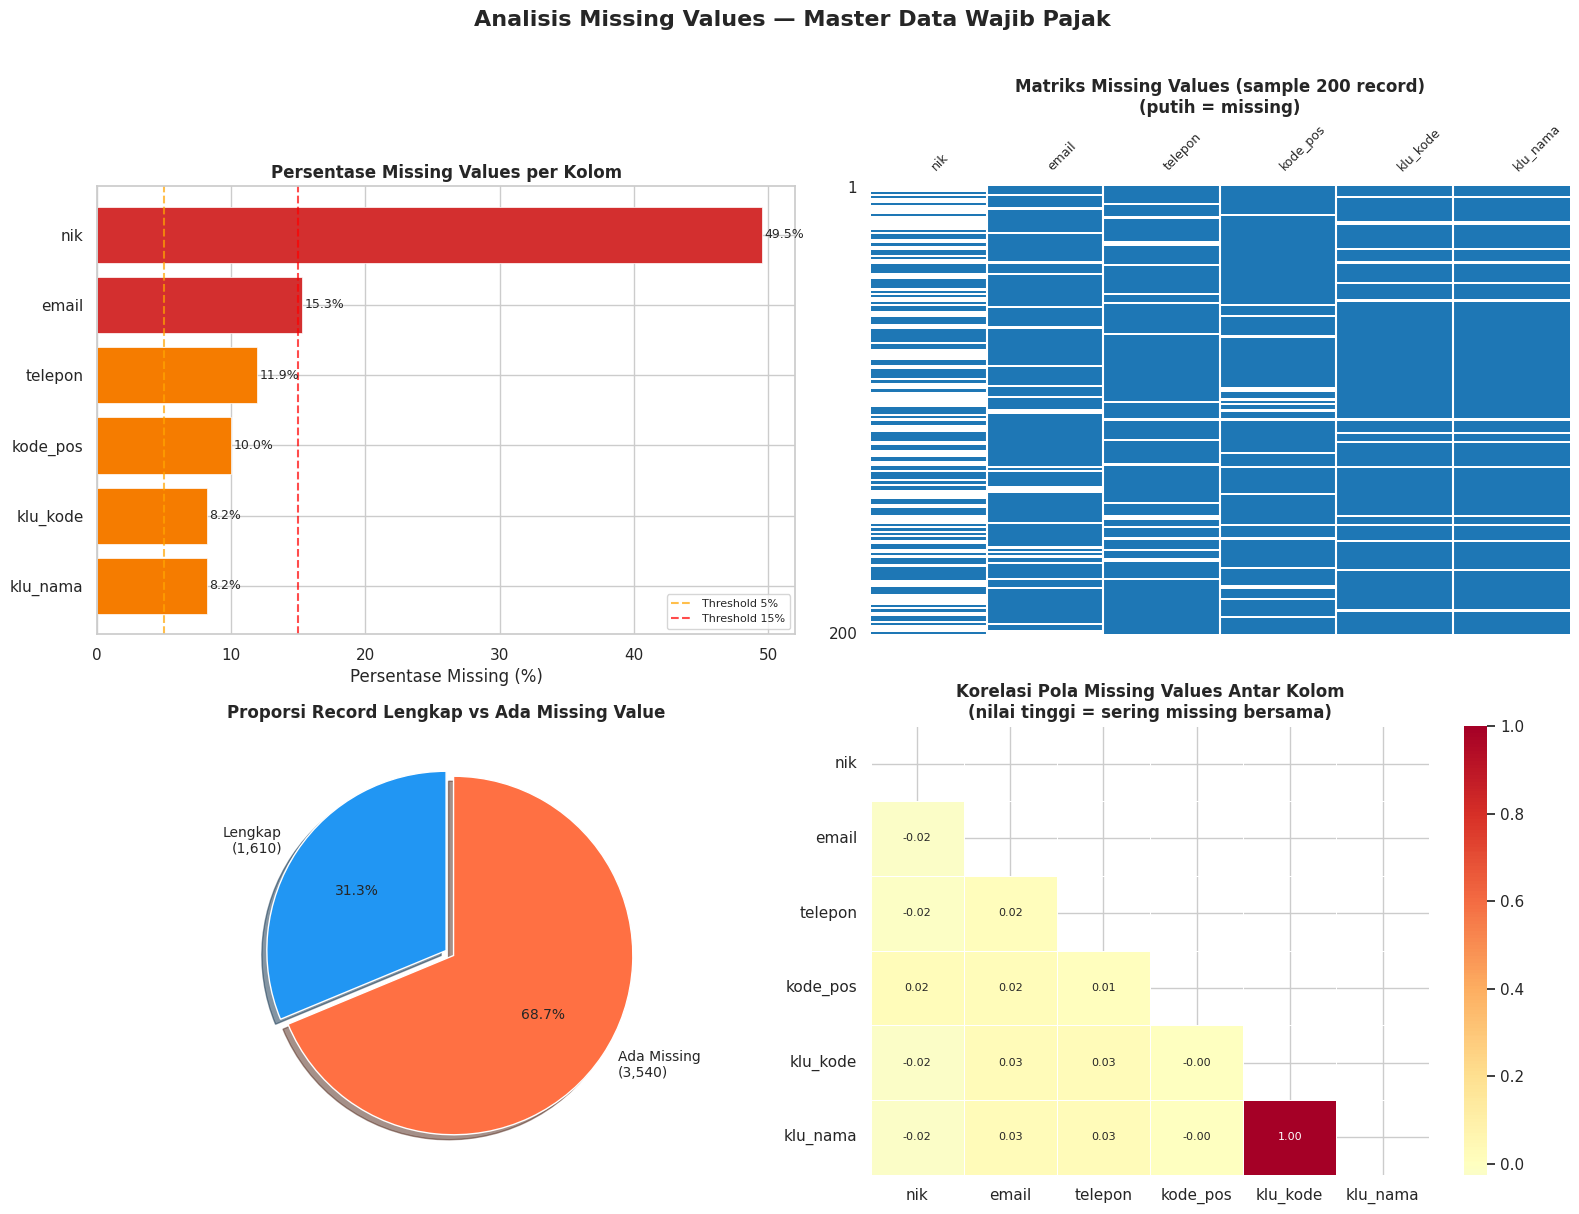

💾 Chart disimpan: chart_missing_values.png


In [15]:
# ============================================================
# CELL 10: VISUALISASI MISSING VALUES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Missing Values — Master Data Wajib Pajak',
             fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Bar Chart — % Missing per Kolom ──
ax1 = axes[0, 0]
has_missing_sorted = has_missing.sort_values('Persen Missing', ascending=True)
colors = ['#d32f2f' if p > 15 else '#f57c00' if p > 5 else '#fbc02d'
          for p in has_missing_sorted['Persen Missing']]
bars = ax1.barh(has_missing_sorted['Kolom'], has_missing_sorted['Persen Missing'],
                color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Persentase Missing (%)')
ax1.set_title('Persentase Missing Values per Kolom', fontweight='bold')
ax1.axvline(x=5,  color='orange', linestyle='--', alpha=0.7, label='Threshold 5%')
ax1.axvline(x=15, color='red',    linestyle='--', alpha=0.7, label='Threshold 15%')
ax1.legend(fontsize=8)
for bar, pct in zip(bars, has_missing_sorted['Persen Missing']):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=9)

# ── Chart 2: Heatmap Missing Values (missingno) ──
ax2 = axes[0, 1]
only_missing_cols = has_missing['Kolom'].tolist()
msno.matrix(df_raw[only_missing_cols].sample(200, random_state=42),
            ax=ax2, sparkline=False, fontsize=9, color=(0.12, 0.47, 0.71))
ax2.set_title('Matriks Missing Values (sample 200 record)\n(putih = missing)', fontweight='bold')

# ── Chart 3: Pie — Proporsi Record Lengkap vs Tidak ──
ax3 = axes[1, 0]
complete_records   = df_raw.dropna().shape[0]
incomplete_records = len(df_raw) - complete_records
ax3.pie(
    [complete_records, incomplete_records],
    labels=[f'Lengkap\n({complete_records:,})', f'Ada Missing\n({incomplete_records:,})'],
    colors=['#2196F3', '#FF7043'],
    autopct='%1.1f%%', startangle=90,
    explode=[0, 0.05], shadow=True, textprops={'fontsize': 10}
)
ax3.set_title('Proporsi Record Lengkap vs Ada Missing Value', fontweight='bold')

# ── Chart 4: Heatmap Korelasi Antar Missing ──
ax4 = axes[1, 1]
missing_corr = df_raw[only_missing_cols].isnull().corr()
mask = np.triu(np.ones_like(missing_corr, dtype=bool))  # sembunyikan segitiga atas
sns.heatmap(missing_corr, ax=ax4, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8})
ax4.set_title('Korelasi Pola Missing Values Antar Kolom\n(nilai tinggi = sering missing bersama)',
              fontweight='bold')

plt.tight_layout()
plt.savefig('chart_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart disimpan: chart_missing_values.png')


In [16]:
# ============================================================
# CELL 11: EXACT DUPLICATE DETECTION
# Mendeteksi record yang memiliki nilai identik pada field kunci
# ============================================================

print('🔍 LAPORAN DUPLICATE DETECTION:')
print('=' * 60)

# ── 1. Full Duplicate: semua kolom identik ──
full_dup = df_raw[df_raw.duplicated(keep=False)]
print(f'\n1️⃣  FULL DUPLICATE (semua kolom identik):')
print(f'   Jumlah record duplikat : {len(full_dup):,}')
print(f'   Persentase             : {len(full_dup)/len(df_raw)*100:.2f}%')

# ── 2. NPWP Duplicate: NPWP yang sama di lebih dari 1 record ──
npwp_dup = df_raw[df_raw.duplicated(subset=['npwp'], keep=False)]
npwp_dup_count = df_raw.groupby('npwp').size().reset_index(name='jumlah')
npwp_dup_count = npwp_dup_count[npwp_dup_count['jumlah'] > 1].sort_values('jumlah', ascending=False)

print(f'\n2️⃣  NPWP DUPLICATE (NPWP muncul lebih dari 1 kali):')
print(f'   NPWP duplikat unik     : {len(npwp_dup_count):,}')
print(f'   Total record terdampak : {len(npwp_dup):,}')
print(f'   Persentase             : {len(npwp_dup)/len(df_raw)*100:.2f}%')
print(f'\n   TOP 10 NPWP paling banyak duplikat:')
display(npwp_dup_count.head(10))

# ── 3. Nama + KPP Duplicate ──
nama_kpp_dup = df_raw[df_raw.duplicated(subset=['nama_wp', 'kode_kpp'], keep=False)]
print(f'\n3️⃣  NAMA + KPP DUPLICATE (nama dan KPP sama):')
print(f'   Record terdampak       : {len(nama_kpp_dup):,}')
print(f'   Persentase             : {len(nama_kpp_dup)/len(df_raw)*100:.2f}%')

# ── 4. Contoh record duplikat ──
print(f'\n📄 CONTOH RECORD DUPLIKAT (NPWP sama, tampilkan 6 record):')
if len(npwp_dup_count) > 0:
    sample_npwp = npwp_dup_count.iloc[0]['npwp']
    sample_dup  = df_raw[df_raw['npwp'] == sample_npwp][
        ['id_record', 'npwp', 'nama_wp', 'jenis_wp', 'kode_kpp', 'status_wp']
    ]
    display(sample_dup)

# Simpan laporan
npwp_dup.to_csv('profiling_duplicates.csv', index=False)
print('\n💾 Laporan duplikat disimpan: profiling_duplicates.csv')


🔍 LAPORAN DUPLICATE DETECTION:

1️⃣  FULL DUPLICATE (semua kolom identik):
   Jumlah record duplikat : 0
   Persentase             : 0.00%

2️⃣  NPWP DUPLICATE (NPWP muncul lebih dari 1 kali):
   NPWP duplikat unik     : 150
   Total record terdampak : 300
   Persentase             : 5.83%

   TOP 10 NPWP paling banyak duplikat:


,npwp,jumlah
3,00.005.058.3-388.097,2
26,00.058.843.0-985.501,2
127,00.279.698.4-690.685,2
213,00.487.666.8-472.469,2
251,00.568.400.3-448.816,2
285,00.642.908.8-867.528,2
342,00.787.864.3-845.723,2
348,00.798.745.8-938.246,2
380,00.866.734.3-688.497,2
390,00.883.239.6-022.530,2



3️⃣  NAMA + KPP DUPLICATE (nama dan KPP sama):
   Record terdampak       : 176
   Persentase             : 3.42%

📄 CONTOH RECORD DUPLIKAT (NPWP sama, tampilkan 6 record):


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
114,WP001554,00.005.058.3-388.097,PT. Perum Hutapea (Persero) Tbk,Badan,0911,Aktif
3008,WP001554_DUP,00.005.058.3-388.097,PT. PERUM HUTAPEA (PERSERO) TBK,Badan,0911,Aktif



💾 Laporan duplikat disimpan: profiling_duplicates.csv


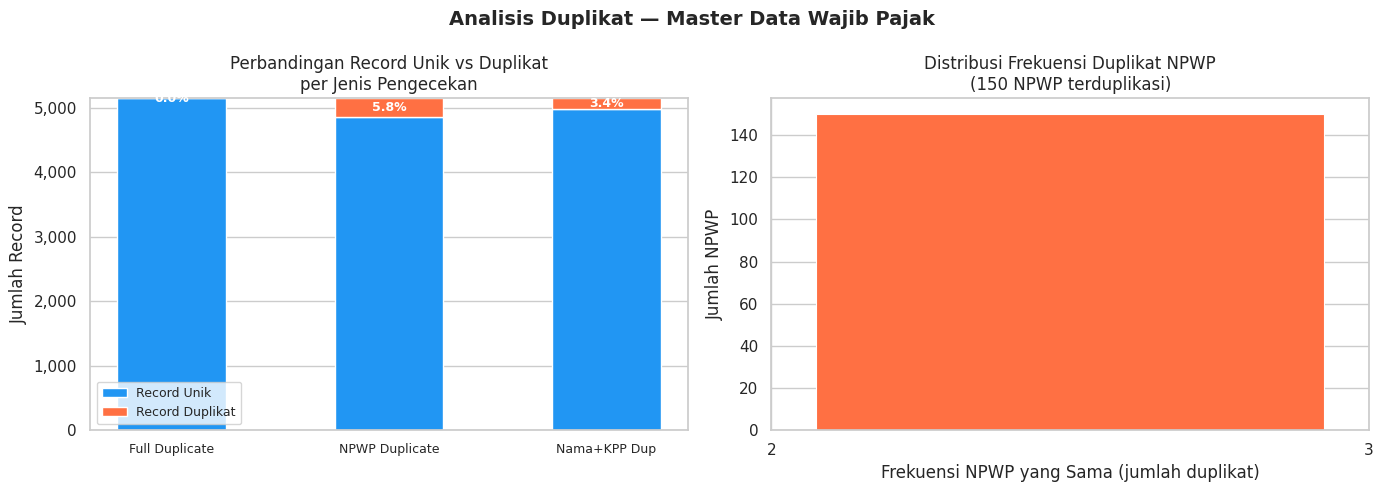

💾 Chart disimpan: chart_duplicates.png


In [17]:
# ============================================================
# CELL 12: VISUALISASI DISTRIBUSI DUPLIKAT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Duplikat — Master Data Wajib Pajak',
             fontsize=14, fontweight='bold')

# ── Chart 1: Stacked Bar — Proporsi Unik vs Duplikat ──
ax1 = axes[0]
categories  = ['Full Duplicate', 'NPWP Duplicate', 'Nama+KPP Dup']
dup_counts  = [len(full_dup), len(npwp_dup), len(nama_kpp_dup)]
clean_counts= [len(df_raw) - d for d in dup_counts]

x = np.arange(len(categories))
width = 0.5
p1 = ax1.bar(x, clean_counts, width, label='Record Unik', color='#2196F3')
p2 = ax1.bar(x, dup_counts, width, bottom=clean_counts, label='Record Duplikat', color='#FF7043')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=9)
ax1.set_ylabel('Jumlah Record')
ax1.set_title('Perbandingan Record Unik vs Duplikat\nper Jenis Pengecekan')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Tambahkan label persentase
for i, (d, c) in enumerate(zip(dup_counts, clean_counts)):
    pct = d / (d + c) * 100
    ax1.text(i, c + d/2, f'{pct:.1f}%', ha='center', va='center',
             color='white', fontweight='bold', fontsize=9)

# ── Chart 2: Histogram Frekuensi Duplikat per NPWP ──
ax2 = axes[1]
dup_freq = npwp_dup_count['jumlah']
ax2.hist(dup_freq, bins=range(2, dup_freq.max()+2), color='#FF7043',
         edgecolor='white', linewidth=0.8, rwidth=0.85)
ax2.set_xlabel('Frekuensi NPWP yang Sama (jumlah duplikat)')
ax2.set_ylabel('Jumlah NPWP')
ax2.set_title(f'Distribusi Frekuensi Duplikat NPWP\n({len(npwp_dup_count)} NPWP terduplikasi)')
ax2.set_xticks(range(2, int(dup_freq.max())+2))

plt.tight_layout()
plt.savefig('chart_duplicates.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart disimpan: chart_duplicates.png')


In [18]:
# ============================================================
# CELL 13: VALIDASI FORMAT NPWP & NIK
# ============================================================

print('🔍 LAPORAN VALIDASI FORMAT:')
print('=' * 60)

# ── 1. Validasi NPWP ──
# Format baku: XX.XXX.XXX.X-XXX.XXX (15 digit dengan separator)
NPWP_PATTERN = r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'

df_raw['npwp_is_valid'] = df_raw['npwp'].apply(
    lambda x: bool(re.match(NPWP_PATTERN, str(x))) if pd.notna(x) else False
)

npwp_valid_count   = df_raw['npwp_is_valid'].sum()
npwp_invalid_count = (~df_raw['npwp_is_valid']).sum()
npwp_invalid_pct   = npwp_invalid_count / len(df_raw) * 100

print(f'\n1️⃣  VALIDASI FORMAT NPWP:')
print(f'   Format valid          : {npwp_valid_count:,} ({100-npwp_invalid_pct:.1f}%)')
print(f'   Format TIDAK VALID    : {npwp_invalid_count:,} ({npwp_invalid_pct:.1f}%)')
print(f'   Pola yang dipakai     : {NPWP_PATTERN}')

# Contoh NPWP tidak valid
npwp_invalid_sample = df_raw[~df_raw['npwp_is_valid']][['id_record','npwp']].head(8)
print(f'\n   Contoh NPWP tidak valid:')
display(npwp_invalid_sample)

# ── 2. Validasi NIK ──
# Format baku: 16 digit angka
NIK_PATTERN = r'^\d{16}$'

# Hanya untuk Orang Pribadi (Badan tidak punya NIK)
df_op = df_raw[df_raw['jenis_wp'] == 'Orang Pribadi'].copy()
df_op['nik_is_valid'] = df_op['nik'].apply(
    lambda x: bool(re.match(NIK_PATTERN, str(x))) if pd.notna(x) else False
)

nik_valid_count   = df_op['nik_is_valid'].sum()
nik_invalid_count = (~df_op['nik_is_valid']).sum()
nik_invalid_pct   = nik_invalid_count / len(df_op) * 100

print(f'\n2️⃣  VALIDASI FORMAT NIK (hanya WP Orang Pribadi):')
print(f'   Total WP Orang Pribadi : {len(df_op):,}')
print(f'   NIK format valid       : {nik_valid_count:,} ({100-nik_invalid_pct:.1f}%)')
print(f'   NIK TIDAK VALID        : {nik_invalid_count:,} ({nik_invalid_pct:.1f}%)')

# Contoh NIK tidak valid
nik_invalid_sample = df_op[~df_op['nik_is_valid']][['id_record','nik','jenis_wp']].head(8)
print(f'\n   Contoh NIK tidak valid:')
display(nik_invalid_sample)


🔍 LAPORAN VALIDASI FORMAT:

1️⃣  VALIDASI FORMAT NPWP:
   Format valid          : 4,726 (91.8%)
   Format TIDAK VALID    : 424 (8.2%)
   Pola yang dipakai     : ^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$

   Contoh NPWP tidak valid:


,id_record,npwp
8,WP001486,XX.267.541.8-648.823
34,WP003287,XX.884.646.9-520.841
51,WP001050,37 548 466
71,WP001407,XX.188.593.5-755.295
75,WP002064,62.960.199.3
78,WP003045,27 584 387
82,WP001967,84.596.518.6
85,WP000423,78.720.548.1



2️⃣  VALIDASI FORMAT NIK (hanya WP Orang Pribadi):
   Total WP Orang Pribadi : 2,598
   NIK format valid       : 2,467 (95.0%)
   NIK TIDAK VALID        : 131 (5.0%)

   Contoh NIK tidak valid:


,id_record,nik,jenis_wp
36,WP004199,854447539588596793,Orang Pribadi
44,WP003810,85993190582468,Orang Pribadi
52,WP000747,17709018278508,Orang Pribadi
61,WP002226,450645425946549866,Orang Pribadi
153,WP004275,058795913193,Orang Pribadi
156,WP000801,181493631258868331,Orang Pribadi
160,WP002883,056921510668,Orang Pribadi
187,WP003425,060921125388360086,Orang Pribadi


3️⃣  VALIDASI FORMAT NOMOR TELEPON:
   Record dengan telepon  : 4,535
   Format valid           : 656 (14.5%)
   Format TIDAK VALID     : 3,879 (85.5%)

4️⃣  VALIDASI FORMAT EMAIL:
   Record dengan email    : 4,364
   Format valid           : 4,364 (100.0%)
   Format TIDAK VALID     : 0 (0.0%)


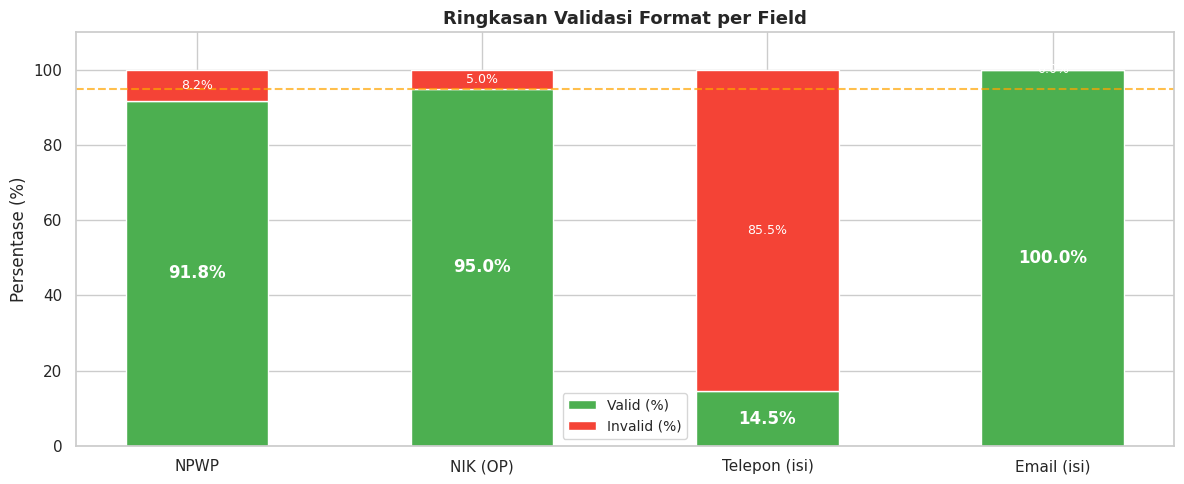

💾 Chart disimpan: chart_format_validation.png


In [19]:
# ============================================================
# CELL 14: VALIDASI TELEPON & EMAIL
# ============================================================


# VALIDASI TELEPON
# ============================================================

def clean_phone(x):
    x = str(x).strip()
    x = re.sub(r'[^0-9+]', '', x)
    return x

TELEPON_PATTERN = r'^(\+62|62|0)8[1-9][0-9]{6,11}$'

df_tel = df_raw[df_raw['telepon'].notna()].copy()

df_tel['telepon_clean'] = df_tel['telepon'].apply(clean_phone)

df_tel['telepon_valid'] = df_tel['telepon_clean'].apply(
    lambda x: bool(re.match(TELEPON_PATTERN, x))
)

n_total_tel   = len(df_tel)
n_valid_tel   = df_tel['telepon_valid'].sum()
n_invalid_tel = n_total_tel - n_valid_tel

print(f'3️⃣  VALIDASI FORMAT NOMOR TELEPON:')
print(f'   Record dengan telepon  : {n_total_tel:,}')
print(f'   Format valid           : {n_valid_tel:,} ({n_valid_tel/n_total_tel*100:.1f}%)')
print(f'   Format TIDAK VALID     : {n_invalid_tel:,} ({n_invalid_tel/n_total_tel*100:.1f}%)')

# ── VALIDASI EMAIL ──
EMAIL_PATTERN = r'^[\w\.-]+@[\w\.-]+\.\w{2,}$'

df_eml = df_raw[df_raw['email'].notna()].copy()
n_total_eml   = len(df_eml)
df_eml['email_valid'] = df_eml['email'].apply(
    lambda x: bool(re.match(EMAIL_PATTERN, str(x).strip()))
)
n_valid_eml   = df_eml['email_valid'].sum()
n_invalid_eml = n_total_eml - n_valid_eml          # ← fix

print(f'\n4️⃣  VALIDASI FORMAT EMAIL:')
print(f'   Record dengan email    : {n_total_eml:,}')
print(f'   Format valid           : {n_valid_eml:,} ({n_valid_eml/n_total_eml*100:.1f}%)')
print(f'   Format TIDAK VALID     : {n_invalid_eml:,} ({n_invalid_eml/n_total_eml*100:.1f}%)')
# ── Visualisasi Ringkasan Validasi ──
fig, ax = plt.subplots(figsize=(12, 5))

labels = ['NPWP', 'NIK (OP)', 'Telepon (isi)', 'Email (isi)']
valid_pct = [
    npwp_valid_count / len(df_raw) * 100,
    nik_valid_count / len(df_op) * 100,
    n_valid_tel / n_total_tel * 100 if n_total_tel > 0 else 0,
    n_valid_eml / n_total_eml * 100 if n_total_eml > 0 else 0,
]
invalid_pct = [100 - v for v in valid_pct]

x     = np.arange(len(labels))
width = 0.5
ax.bar(x, valid_pct,   width, label='Valid (%)',   color='#4CAF50')
ax.bar(x, invalid_pct, width, label='Invalid (%)', color='#F44336', bottom=valid_pct)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Persentase (%)')
ax.set_ylim(0, 110)
ax.set_title('Ringkasan Validasi Format per Field', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='Target 95%')

for i, (v, inv) in enumerate(zip(valid_pct, invalid_pct)):
    ax.text(i, v/2,       f'{v:.1f}%',   ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, v+inv/2,   f'{inv:.1f}%', ha='center', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('chart_format_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart disimpan: chart_format_validation.png')



In [20]:
# ============================================================
# CELL 15: DATA QUALITY SCORECARD
# Menghitung skor kualitas berdasarkan 6 dimensi kualitas data
# ============================================================

total  = len(df_raw)
df_op2 = df_raw[df_raw['jenis_wp'] == 'Orang Pribadi']
df_with_phone2 = df_raw[df_raw['telepon'].notna()]

# ── COMPLETENESS: field wajib tidak boleh kosong ──
mandatory_fields = ['npwp', 'nama_wp', 'jenis_wp', 'status_wp',
                    'kode_kpp', 'kode_provinsi', 'tanggal_daftar']
completeness_per_field = [(1 - df_raw[f].isnull().mean()) * 100 for f in mandatory_fields]
score_completeness     = np.mean(completeness_per_field)

# ============================================================
# VALIDASI NIK
# ============================================================

NIK_PATTERN = r'^\d{16}$'

df_op2 = df_raw[df_raw['jenis_wp'] == 'Orang Pribadi'].copy()

df_op2['nik_is_valid'] = df_op2['nik'].astype(str).str.match(NIK_PATTERN)

# ── VALIDITY: format NPWP, NIK, email valid ──
npwp_valid_pct  = df_raw['npwp_is_valid'].mean() * 100
nik_valid_pct = df_op2['nik_is_valid'].mean() * 100
# Use already computed n_valid_tel and n_total_tel from previous cell
phone_valid_pct = (n_valid_tel / n_total_tel * 100) if n_total_tel > 0 else 100
score_validity  = np.mean([npwp_valid_pct, nik_valid_pct, phone_valid_pct])

# ── UNIQUENESS: tidak ada duplikat NPWP ──
n_dup_npwp      = df_raw.duplicated(subset=['npwp']).sum()
score_uniqueness= (1 - n_dup_npwp / total) * 100

# ── CONSISTENCY: nama tidak menggunakan casing yang berbeda ──
# Deteksi nama yang sepenuhnya uppercase atau lowercase
n_casing_issues = df_raw['nama_wp'].apply(
    lambda x: str(x).isupper() or str(x).islower() if pd.notna(x) else False
).sum()
score_consistency = (1 - n_casing_issues / total) * 100

# ── TIMELINESS: asumsi semua record sudah up to date (simulasi) ──
# Cek tanggal daftar tidak di masa depan
n_future_dates  = (pd.to_datetime(df_raw['tanggal_daftar']) > pd.Timestamp.now()).sum()
score_timeliness= (1 - n_future_dates / total) * 100

# ── ACCURACY: simulasi — cek konsistensi kode_provinsi vs nama_provinsi ──
provinsi_map    = PROVINSI
n_prov_mismatch = df_raw.apply(
    lambda r: provinsi_map.get(r['kode_provinsi']) != r['nama_provinsi'], axis=1
).sum()
score_accuracy  = (1 - n_prov_mismatch / total) * 100

# ── WEIGHTED DQ SCORE ──
# Bobot sesuai kepentingan bisnis DJP
dimensions = {
    'Completeness' : {'score': score_completeness,  'weight': 0.20},
    'Validity'     : {'score': score_validity,      'weight': 0.25},
    'Uniqueness'   : {'score': score_uniqueness,    'weight': 0.20},
    'Consistency'  : {'score': score_consistency,   'weight': 0.15},
    'Timeliness'   : {'score': score_timeliness,    'weight': 0.10},
    'Accuracy'     : {'score': score_accuracy,      'weight': 0.10},
}

total_dq_score = sum(v['score'] * v['weight'] for v in dimensions.values())

# ── Tampilkan Scorecard ──
print('=' * 65)
print('          DATA QUALITY SCORECARD — MASTER DATA WP')
print(f'          Tanggal: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
print(f'          Total Record: {total:,}')
print('=' * 65)
print(f'{"Dimensi":<16} {"Score":>8}  {"Bobot":>6}  {"Weighted":>8}  Status')
print('-' * 65)

for dim, val in dimensions.items():
    weighted  = val['score'] * val['weight']
    status    = '✅ PASS' if val['score'] >= 95 else '⚠ WARN' if val['score'] >= 85 else '🔴 FAIL'
    bar       = '█' * int(val['score'] / 5)  # progress bar (max 20 karakter)
    print(f'{dim:<16} {val["score"]:>7.2f}%  {val["weight"]*100:>5.0f}%  {weighted:>8.2f}  {status}')

print('=' * 65)
grade  = 'A' if total_dq_score >= 95 else 'B' if total_dq_score >= 85 else 'C' if total_dq_score >= 75 else 'D'
status = '✅ ACCEPTABLE' if total_dq_score >= 85 else '⚠ PERLU PERBAIKAN' if total_dq_score >= 75 else '🔴 TIDAK ACCEPTABLE'
print(f'  TOTAL DQ SCORE : {total_dq_score:.2f} / 100  |  Grade: {grade}  |  {status}')
print('=' * 65)


          DATA QUALITY SCORECARD — MASTER DATA WP
          Tanggal: 2026-06-09 20:21
          Total Record: 5,150
Dimensi             Score   Bobot  Weighted  Status
-----------------------------------------------------------------
Completeness      100.00%     20%     20.00  ✅ PASS
Validity           67.06%     25%     16.77  🔴 FAIL
Uniqueness         97.09%     20%     19.42  ✅ PASS
Consistency        83.61%     15%     12.54  🔴 FAIL
Timeliness        100.00%     10%     10.00  ✅ PASS
Accuracy          100.00%     10%     10.00  ✅ PASS
  TOTAL DQ SCORE : 88.73 / 100  |  Grade: B  |  ✅ ACCEPTABLE


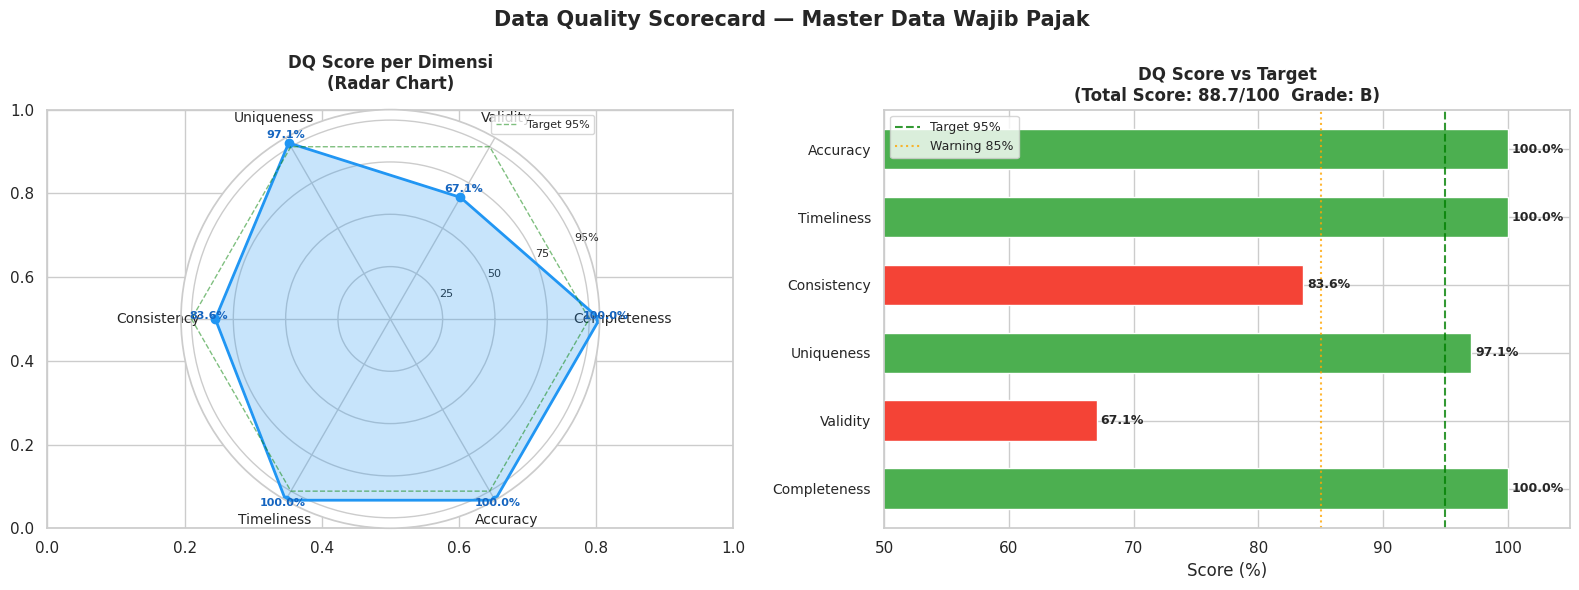

💾 Chart scorecard disimpan: chart_dq_scorecard.png

🏁 PROFILING SELESAI!
   Semua hasil telah disimpan sebagai file CSV dan PNG.
   Lanjutkan ke LAB 2: Data Cleansing & Standardization


In [21]:
# ============================================================
# CELL 16: VISUALISASI DATA QUALITY SCORECARD
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Quality Scorecard — Master Data Wajib Pajak',
             fontsize=15, fontweight='bold')

# ── Chart 1: Radar/Spider Chart untuk DQ Score ──
ax1 = axes[0]
dim_names  = list(dimensions.keys())
dim_scores = [v['score'] for v in dimensions.values()]

# Konversi ke koordinat polar
angles = np.linspace(0, 2*np.pi, len(dim_names), endpoint=False).tolist()
dim_scores_polar = dim_scores + [dim_scores[0]]  # tutup polygon
angles          += [angles[0]]

ax1 = plt.subplot(121, polar=True)
ax1.plot(angles, dim_scores_polar, 'o-', linewidth=2, color='#2196F3')
ax1.fill(angles, dim_scores_polar, alpha=0.25, color='#2196F3')
ax1.plot(angles, [95]*len(angles), '--', color='green', alpha=0.5, linewidth=1, label='Target 95%')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(dim_names, fontsize=10)
ax1.set_ylim(0, 100)
ax1.set_yticks([25, 50, 75, 95])
ax1.set_yticklabels(['25', '50', '75', '95%'], fontsize=8)
ax1.set_title('DQ Score per Dimensi\n(Radar Chart)', fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=8)

# Tambah label nilai
for angle, score, name in zip(angles[:-1], dim_scores, dim_names):
    ax1.annotate(f'{score:.1f}%', xy=(angle, score), fontsize=8, ha='center',
                 xytext=(angle, score+3), color='#1565C0', fontweight='bold')

# ── Chart 2: Horizontal Bar Chart — Score vs Target ──
ax2 = plt.subplot(122)
y_pos   = np.arange(len(dim_names))
colors2 = ['#4CAF50' if s >= 95 else '#FF9800' if s >= 85 else '#F44336'
           for s in dim_scores]

bars2 = ax2.barh(y_pos, dim_scores, color=colors2, edgecolor='white', height=0.6)
ax2.axvline(x=95, color='green', linestyle='--', linewidth=1.5,
            label='Target 95%', alpha=0.8)
ax2.axvline(x=85, color='orange', linestyle=':', linewidth=1.5,
            label='Warning 85%', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(dim_names, fontsize=10)
ax2.set_xlim(50, 105)
ax2.set_xlabel('Score (%)')
ax2.set_title(f'DQ Score vs Target\n(Total Score: {total_dq_score:.1f}/100  Grade: {grade})',
              fontweight='bold')
ax2.legend(fontsize=9)

for bar, score in zip(bars2, dim_scores):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_dq_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Chart scorecard disimpan: chart_dq_scorecard.png')
print(f'\n🏁 PROFILING SELESAI!')
print(f'   Semua hasil telah disimpan sebagai file CSV dan PNG.')
print(f'   Lanjutkan ke LAB 2: Data Cleansing & Standardization')


DATA CLEANSING

In [22]:
# ============================================================
# CELL 1: INSTALL LIBRARY TAMBAHAN LAB 2
# ============================================================

!pip install fuzzywuzzy python-Levenshtein unidecode jellyfish -q

print('✅ Library tambahan berhasil diinstall:')
print('   fuzzywuzzy         : fuzzy string matching')
print('   python-Levenshtein : akselerasi fuzzywuzzy')
print('   unidecode          : konversi karakter unicode ke ASCII')
print('   jellyfish          : string similarity (Jaro-Winkler, Soundex)')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.4 MB/s eta 0:00:00
✅ Library tambahan berhasil diinstall:
   fuzzywuzzy         : fuzzy string matching
   python-Levenshtein : akselerasi fuzzywuzzy
   unidecode          : konversi karakter unicode ke ASCII
   jellyfish          : string similarity (Jaro-Winkler, Soundex)


In [23]:
# ============================================================
# CELL 2: IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import re
import warnings
import json
from datetime import datetime
warnings.filterwarnings('ignore')

# String processing
from unidecode   import unidecode      # normalisasi unicode → ASCII
from fuzzywuzzy  import fuzz           # fuzzy string matching
import jellyfish                        # Jaro-Winkler, Soundex

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Setting display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 130)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Semua library berhasil diimport!')



✅ Semua library berhasil diimport!


In [24]:
# ============================================================
# CELL 3: LOAD DATASET DARI LAB 1
# ============================================================

# Jika dataset_wp_raw.csv sudah ada di Colab session (LAB 1 masih aktif)
# langsung load. Jika session baru, upload ulang file CSV-nya.

try:
    df_raw = pd.read_csv(
        'dataset_wp_raw.csv',
        dtype={
            'npwp': str,
            'nik': str,
            'telepon': str,
            'kode_pos': str
        }
    )
    print(f'✅ Dataset berhasil dimuat dari file CSV')
except FileNotFoundError:
    print('❌ File tidak ditemukan. Jalankan ulang LAB 1 untuk membuat dataset,')
    print('   atau upload file dataset_wp_raw.csv ke Colab.')
    raise

# Buat salinan kerja — JANGAN modifikasi df_raw langsung!
# df_raw adalah data asli yang menjadi referensi/backup
df_clean = df_raw.copy()

# Konversi tipe data dasar
df_clean['tanggal_daftar'] = pd.to_datetime(df_clean['tanggal_daftar'], errors='coerce')
df_clean['penghasilan']    = pd.to_numeric(df_clean['penghasilan'],    errors='coerce')

print(f'   Shape dataset    : {df_clean.shape}')
print(f'   Kolom            : {list(df_clean.columns)}')
print(f'   Memory usage     : {df_clean.memory_usage(deep=True).sum()/1024:.1f} KB')
print(f'')
print(f'   Dataset asli (df_raw)  → JANGAN dimodifikasi, sebagai backup')
print(f'   Dataset kerja (df_clean) → tempat semua proses cleansing berlangsung')


✅ Dataset berhasil dimuat dari file CSV
   Shape dataset    : (5150, 21)
   Kolom            : ['id_record', 'npwp', 'nik', 'nama_wp', 'jenis_wp', 'status_wp', 'status_pkp', 'kode_kpp', 'nama_kpp', 'kode_provinsi', 'nama_provinsi', 'alamat', 'kelurahan', 'kota', 'kode_pos', 'klu_kode', 'klu_nama', 'email', 'telepon', 'penghasilan', 'tanggal_daftar']
   Memory usage     : 5135.5 KB

   Dataset asli (df_raw)  → JANGAN dimodifikasi, sebagai backup
   Dataset kerja (df_clean) → tempat semua proses cleansing berlangsung


In [25]:
# ============================================================
# CELL 4: SISTEM AUDIT TRAIL
# Mencatat setiap operasi cleansing yang dilakukan
# ============================================================

class AuditTrail:
    """
    Sistem pencatatan perubahan data (audit trail) untuk proses cleansing.
    Setiap operasi cleansing harus dicatat menggunakan instance ini.
    """
    def __init__(self, dataset_name: str, total_records: int):
        self.dataset_name  = dataset_name
        self.total_records = total_records
        self.start_time    = datetime.now()
        self.entries       = []   # daftar semua perubahan
        self.step_counter  = 0

    def log(self, operation: str, field: str, n_affected: int,
            description: str, before_sample: str = '', after_sample: str = ''):
        """Catat satu operasi cleansing ke dalam audit log."""
        self.step_counter += 1
        entry = {
            'step'          : self.step_counter,
            'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'operation'     : operation,
            'field'         : field,
            'n_affected'    : n_affected,
            'pct_affected'  : round(n_affected / self.total_records * 100, 2),
            'description'   : description,
            'before_sample' : before_sample,
            'after_sample'  : after_sample,
        }
        self.entries.append(entry)
        # Cetak ringkasan langsung
        pct = entry['pct_affected']
        icon = '🟢' if pct < 5 else '🟡' if pct < 15 else '🔴'
        print(f'  [{self.step_counter:02d}] {icon} {operation:<22} | {field:<20} | {n_affected:>6} record ({pct:>5.1f}%)')
        if before_sample and after_sample:
            print(f'       Sebelum: {before_sample}')
            print(f'       Sesudah: {after_sample}')

    def summary(self):
        """Tampilkan ringkasan semua operasi cleansing."""
        duration = (datetime.now() - self.start_time).seconds
        print('\n' + '='*70)
        print(f'  AUDIT TRAIL SUMMARY — {self.dataset_name}')
        print(f'  Durasi proses : {duration} detik')
        print(f'  Total operasi : {self.step_counter}')
        print('='*70)
        print(f'  {"Step":<5} {"Operasi":<22} {"Field":<20} {"Affected":>8}  {"Persen":>6}')
        print('-'*70)
        for e in self.entries:
            print(f'  {e["step"]:>4}  {e["operation"]:<22} {e["field"]:<20} {e["n_affected"]:>8,}  {e["pct_affected"]:>5.1f}%')
        print('='*70)

    def to_dataframe(self):
        """Export audit trail ke DataFrame untuk disimpan sebagai CSV."""
        return pd.DataFrame(self.entries)


# Inisialisasi audit trail untuk sesi LAB 2
audit = AuditTrail('Master Data Wajib Pajak', total_records=len(df_clean))

print(f'✅ Sistem Audit Trail siap!')
print(f'   Dataset: {audit.dataset_name}')
print(f'   Total record: {audit.total_records:,}')
print(f'   Waktu mulai: {audit.start_time.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'')
print(f'Format log: [Step] Icon Operasi | Field | Jumlah Record (Persen)')


✅ Sistem Audit Trail siap!
   Dataset: Master Data Wajib Pajak
   Total record: 5,150
   Waktu mulai: 2026-06-09 20:21:28

Format log: [Step] Icon Operasi | Field | Jumlah Record (Persen)


In [26]:
# ============================================================
# CELL 5: STANDARDISASI NAMA WAJIB PAJAK
# Menangani: casing, whitespace, karakter khusus, unicode
# ============================================================

import re
import pandas as pd
from unidecode import unidecode

def standardize_nama(nama: str) -> str:
    """
    Standardisasi nama Wajib Pajak:
    - Menghapus titik salah tempat pada semua badan usaha (PT, CV, Koperasi, dll.)
    - Menangani kombinasi badan usaha ganda (CV. UD -> CV UD, PT. PD -> PT PD)
    - Menghapus duplikasi badan usaha (PT PT -> PT)
    - Melindungi gelar akademik seperti S.Pt. agar tidak rusak
    """
    if pd.isna(nama) or str(nama).strip() == '':
        return None

    s = str(nama)

    # 1. Strip & Normalisasi spasi awal
    s = s.strip()
    s = re.sub(r'\s+', ' ', s)

    # 2. Hapus karakter tidak diinginkan (kecuali . , - ')
    s = re.sub(r"[^a-zA-Z0-9\s.,\-']", '', s)

    # 3. Transliterasi unicode → ASCII
    s = unidecode(s)

    # 4. Title Case awal
    s = s.title()

    # 5. HAPUS TITIK setelah kata operasional utuh
    bad_dots_fixes = {
        r'\bKoperasi\.': 'Koperasi',
        r'\bFirma\.':    'Firma',
        r'\bPerum\.':    'Perum',
    }
    for pattern, replacement in bad_dots_fixes.items():
        s = re.sub(pattern, replacement, s, flags=re.IGNORECASE)

    # 6. PERBAIKI KAPITALISASI SINGKATAN (Proteksi S.Pt)
    s = re.sub(r'(?<!S\.)\bPt\b', 'PT', s, flags=re.IGNORECASE)

    abbrev_fixes = {
        r'\bCv\b': 'CV',
        r'\bUd\b': 'UD',
        r'\bPd\b': 'PD',
        r'\bTbk\b': 'Tbk',
        r'\bM\.Ti\b': 'M.Ti',
        r'\bDan\b': 'dan',
        r'\bDi\b': 'di',
        r'\bThe\b': 'the',
        r'\bOf\b': 'of',
    }
    for pattern, replacement in abbrev_fixes.items():
        s = re.sub(pattern, replacement, s, flags=re.IGNORECASE)

    # 7. HAPUS TITIK DI ANTARA BADAN USAHA / SINGKATAN
    # Menghapus titik setelah PT, CV, UD, PD jika diikuti oleh spasi dan kata lain
    # Contoh: "CV. UD" -> "CV UD", "PT. PD" -> "PT PD", "PT. Indofood" -> "PT Indofood"
    s = re.sub(r'\b(PT|CV|UD|PD)\.\s+', r'\1 ', s)

    # 8. HAPUS DUPLIKASI BADAN USAHA YANG MUNCUL GANDA
    s = re.sub(r'\b(PT|CV|UD|PD)\b(?:\s*[\.?]\s*)\b\1\b', r'\1', s, flags=re.IGNORECASE)
    s = re.sub(r'\b(PT|CV|UD|PD)\s+\1\b', r'\1', s, flags=re.IGNORECASE)

    # 9. Bersihkan sisa spasi ganda atau double titik (..) di akhir kalimat
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'\.+', '.', s)

    return s.strip()


# Terapkan ke kolom nama_wp
n_before = df_clean['nama_wp'].nunique()

# Simpan nama asli untuk audit
df_clean['nama_wp_original'] = df_clean['nama_wp'].copy()
df_clean['nama_wp']          = df_clean['nama_wp'].apply(standardize_nama)

n_changed = (df_clean['nama_wp'] != df_clean['nama_wp_original']).sum()
n_after   = df_clean['nama_wp'].nunique()

# Catat ke audit trail
audit.log(
    operation   = 'STANDARDIZE_TEXT',
    field       = 'nama_wp',
    n_affected  = n_changed,
    description = 'Title Case, hapus spasi ganda, hapus karakter khusus, unidecode',
    before_sample = str(df_clean[df_clean['nama_wp'] != df_clean['nama_wp_original']]['nama_wp_original'].iloc[0]) if n_changed > 0 else '-',
    after_sample  = str(df_clean[df_clean['nama_wp'] != df_clean['nama_wp_original']]['nama_wp'].iloc[0])          if n_changed > 0 else '-',
)

# Tampilkan sampel perubahan
print(f'\n📊 HASIL STANDARDISASI NAMA WP:')
print(f'   Record diubah     : {n_changed:,} dari {len(df_clean):,} total')
print(f'   Unique nama sebelum: {n_before:,}')
print(f'   Unique nama sesudah: {n_after:,}')
print(f'')
# Tampilkan 10 contoh perubahan
changed = df_clean[df_clean['nama_wp'] != df_clean['nama_wp_original']][
    ['nama_wp_original','nama_wp']
].head(10)
changed.columns = ['SEBELUM','SESUDAH']
print('   Contoh perubahan:')
display(changed)


  [01] 🔴 STANDARDIZE_TEXT       | nama_wp              |   3222 record ( 62.6%)
       Sebelum: Firma. UD Pratama Mandasari (Persero) Tbk
       Sesudah: Firma UD Pratama Mandasari Persero Tbk

📊 HASIL STANDARDISASI NAMA WP:
   Record diubah     : 3,222 dari 5,150 total
   Unique nama sebelum: 5,016
   Unique nama sesudah: 4,925

   Contoh perubahan:


,SEBELUM,SESUDAH
0,Firma. UD Pratama Mandasari (Persero) Tbk,Firma UD Pratama Mandasari Persero Tbk
2,PT. UD Prastuti Tampubolon Tbk,PT UD Prastuti Tampubolon Tbk
3,FIRMA. PD HARYANTO TBK,Firma PD Haryanto Tbk
4,KOPERASI. PERUM HALIM KUSMAWATI,Koperasi Perum Halim Kusmawati
5,UD. Perum Padmasari,UD Perum Padmasari
7,KH. Prasetya Puspita,Kh. Prasetya Puspita
9,UD. Perum Utami,UD Perum Utami
10,VIKTOR PANGESTU,Viktor Pangestu
12,MUSTOFA USAMAH,Mustofa Usamah
16,Firma. PD Laksita Prasetyo,Firma PD Laksita Prasetyo


In [27]:
# ============================================================
# CELL 6: STANDARDISASI ALAMAT
# Menstandarkan format penulisan alamat
# ============================================================

# Kamus singkatan jalan yang distandarkan
JALAN_MAP = {
    r'\bJL\.?\b'      : 'Jl.',   r'\bJLN\.?\b'     : 'Jl.',
    r'\bJALAN\b'       : 'Jl.',   r'\bGG\.?\b'       : 'Gg.',
    r'\bGANG\b'        : 'Gg.',   r'\bKEC\.?\b'      : 'Kec.',
    r'\bKECAMATAN\b'   : 'Kec.',  r'\bKAB\.?\b'      : 'Kab.',
    r'\bKABUPATEN\b'   : 'Kab.',  r'\bKEL\.?\b'      : 'Kel.',
    r'\bKELURAHAN\b'   : 'Kel.',  r'\bBLOK\b'         : 'Blok',
    r'\bNO\.?\b'      : 'No.',   r'\bNOMOR\b'        : 'No.',
    r'\bRT\.?\b'      : 'RT',    r'\bRW\.?\b'       : 'RW',
}

def standardize_alamat(alamat: str) -> str:
    """Standardisasi format penulisan alamat."""
    if pd.isna(alamat) or str(alamat).strip() == '':
        return None

    s = str(alamat).strip()

    # Title case dulu
    s = s.title()

    # Normalisasi spasi
    s = re.sub(r'\s+', ' ', s)

    # Terapkan singkatan baku (case-insensitive)
    for pattern, replacement in JALAN_MAP.items():
        s = re.sub(pattern, replacement, s, flags=re.IGNORECASE)

    return s.strip()


# Terapkan standardisasi alamat
df_clean['alamat_original'] = df_clean['alamat'].copy()
df_clean['alamat']          = df_clean['alamat'].apply(standardize_alamat)

# Standardisasi kolom kelurahan dan kota
df_clean['kelurahan'] = df_clean['kelurahan'].str.strip().str.title()
df_clean['kota']      = df_clean['kota'].str.strip().str.title()

n_changed_alamat = (df_clean['alamat'] != df_clean['alamat_original']).sum()

audit.log(
    operation   = 'STANDARDIZE_TEXT',
    field       = 'alamat',
    n_affected  = n_changed_alamat,
    description = 'Title Case, singkatan jalan baku (Jl., Gg., Kec., dll.)',
)

print(f'✅ Standardisasi alamat selesai: {n_changed_alamat:,} record diubah')
print(f'\n   Contoh hasil:')
sample_change = df_clean[df_clean['alamat'] != df_clean['alamat_original']][
    ['alamat_original','alamat']
].head(6)
sample_change.columns = ['SEBELUM','SESUDAH']
display(sample_change)


  [02] 🔴 STANDARDIZE_TEXT       | alamat               |   5150 record (100.0%)
✅ Standardisasi alamat selesai: 5,150 record diubah

   Contoh hasil:


,SEBELUM,SESUDAH
0,Jalan Gardujati No. 520,Jl. Gardujati No.. 520
1,Gang Yos Sudarso No. 7,Gg. Yos Sudarso No.. 7
2,Jalan Ciumbuleuit No. 3,Jl. Ciumbuleuit No.. 3
3,Jl. M.T Haryono No. 915,Jl.. M.T Haryono No.. 915
4,Jalan Cikutra Timur No. 24,Jl. Cikutra Timur No.. 24
5,Jl. Asia Afrika No. 1,Jl.. Asia Afrika No.. 1


In [28]:
# ============================================================
# CELL 6 (REVISI FINAL): STANDARDISASI ALAMAT
# ============================================================

import re
import pandas as pd
from unidecode import unidecode

# ============================================================
# KAMUS NORMALISASI
# ============================================================

JALAN_MAP = {
    r'\bJALAN\b'       : 'Jl.',
    r'\bJLN\b'         : 'Jl.',
    r'\bJL\b'          : 'Jl.',

    r'\bGANG\b'        : 'Gg.',
    r'\bGG\b'          : 'Gg.',

    r'\bKECAMATAN\b'   : 'Kec.',
    r'\bKEC\b'         : 'Kec.',

    r'\bKABUPATEN\b'   : 'Kab.',
    r'\bKAB\b'         : 'Kab.',

    r'\bKELURAHAN\b'   : 'Kel.',
    r'\bKEL\b'         : 'Kel.',

    r'\bNOMOR\b'       : 'No.',
    r'\bNO\b'          : 'No.',

    r'\bBLOK\b'        : 'Blok',

    r'\bRT\b'          : 'RT',
    r'\bRW\b'          : 'RW',
}

# ============================================================
# FUNGSI STANDARDISASI
# ============================================================

def standardize_alamat(alamat: str) -> str:

    if pd.isna(alamat):
        return None

    s = str(alamat).strip()

    if s == '':
        return None

    # ========================================================
    # 1. UNICODE NORMALIZATION
    # ========================================================

    s = unidecode(s)

    # ========================================================
    # 2. NORMALISASI SPASI
    # ========================================================

    s = re.sub(r'\s+', ' ', s)

    # ========================================================
    # 3. REMOVE SPECIAL CHARS BERLEBIHAN
    # ========================================================

    # Tetap pertahankan:
    # titik, slash, dash, koma, kurung
    s = re.sub(r"[^a-zA-Z0-9\s.,()/#\-]", '', s)

    # ========================================================
    # 4. TITLE CASE SEMENTARA
    # ========================================================

    s = s.title()

    # ========================================================
    # 5. NORMALISASI SINGKATAN
    # ========================================================

    for pattern, replacement in JALAN_MAP.items():

        s = re.sub(
            pattern,
            replacement,
            s,
            flags=re.IGNORECASE
        )

    # ========================================================
    # 6. FIX DOUBLE DOTS
    # ========================================================

    # Jl.. -> Jl.
    # No.. -> No.
    s = re.sub(r'\.\.+', '.', s)

    # ========================================================
    # 7. FIX SPACING
    # ========================================================

    # Spasi sebelum titik
    s = re.sub(r'\s+\.', '.', s)

    # Multiple spaces
    s = re.sub(r'\s+', ' ', s)

    # ========================================================
    # 8. PRESERVE COMMON ACRONYM ROADS
    # ========================================================

    ROAD_FIXES = {
        r'\bM\.H\b'   : 'M.H',
        r'\bA\.Yani\b': 'A. Yani',
        r'\bHos\b'    : 'HOS',
        r'\bAh\b'     : 'AH',
    }

    for pattern, replacement in ROAD_FIXES.items():

        s = re.sub(pattern, replacement, s)

    return s.strip()


# ============================================================
# APPLY TRANSFORMATION
# ============================================================

print('=' * 70)
print('STANDARDISASI ALAMAT')
print('=' * 70)

# Backup original
df_clean['alamat_original'] = df_clean['alamat'].copy()

# Apply
df_clean['alamat'] = df_clean['alamat'].apply(
    standardize_alamat
)

# ============================================================
# STANDARDISASI KELURAHAN & KOTA
# ============================================================

def normalize_wilayah(x):

    if pd.isna(x):
        return None

    x = str(x).strip()

    if x == '':
        return None

    x = unidecode(x)

    x = re.sub(r'\s+', ' ', x)

    return x.title()


df_clean['kelurahan'] = df_clean['kelurahan'].apply(
    normalize_wilayah
)

df_clean['kota'] = df_clean['kota'].apply(
    normalize_wilayah
)

# ============================================================
# HITUNG PERUBAHAN REAL
# ============================================================

mask_changed = (
    df_clean['alamat'].fillna('') !=
    df_clean['alamat_original'].fillna('')
)

n_changed_alamat = mask_changed.sum()

# ============================================================
# AUDIT TRAIL
# ============================================================

if n_changed_alamat > 0:

    before_sample = str(
        df_clean.loc[
            mask_changed,
            'alamat_original'
        ].iloc[0]
    )

    after_sample = str(
        df_clean.loc[
            mask_changed,
            'alamat'
        ].iloc[0]
    )

else:

    before_sample = '-'
    after_sample  = '-'


audit.log(
    operation     = 'STANDARDIZE_TEXT',
    field         = 'alamat',
    n_affected    = int(n_changed_alamat),
    description   = (
        'Normalisasi alamat, singkatan baku '
        '(Jl., Gg., Kec., Kel., No.), '
        'cleanup spasi & karakter'
    ),
    before_sample = before_sample,
    after_sample  = after_sample,
)

# ============================================================
# OUTPUT
# ============================================================

print(f'\n✅ Standardisasi alamat selesai')
print(f'   Record berubah : {n_changed_alamat:,}')
print(f'   Persentase     : {n_changed_alamat/len(df_clean)*100:.1f}%')

print('\n📝 Contoh hasil:')

sample_change = (
    df_clean.loc[
        mask_changed,
        ['alamat_original', 'alamat']
    ]
    .head(10)
    .copy()
)

sample_change.columns = ['SEBELUM', 'SESUDAH']

display(sample_change)

# ============================================================
# QUALITY CHECK
# ============================================================

remaining_double_dot = df_clean['alamat'].str.contains(
    r'\.\.',
    regex=True,
    na=False
).sum()

print('\n🔍 QUALITY CHECK')

print(f'Double dot tersisa : {remaining_double_dot:,}')

if remaining_double_dot > 0:
    print('⚠️ Masih ada alamat bermasalah')
else:
    print('✅ Tidak ditemukan double dot')

STANDARDISASI ALAMAT
  [03] 🔴 STANDARDIZE_TEXT       | alamat               |   5150 record (100.0%)
       Sebelum: Jl. Gardujati No.. 520
       Sesudah: Jl. Gardujati No. 520

✅ Standardisasi alamat selesai
   Record berubah : 5,150
   Persentase     : 100.0%

📝 Contoh hasil:


,SEBELUM,SESUDAH
0,Jl. Gardujati No.. 520,Jl. Gardujati No. 520
1,Gg. Yos Sudarso No.. 7,Gg. Yos Sudarso No. 7
2,Jl. Ciumbuleuit No.. 3,Jl. Ciumbuleuit No. 3
3,Jl.. M.T Haryono No.. 915,Jl. M.T Haryono No. 915
4,Jl. Cikutra Timur No.. 24,Jl. Cikutra Timur No. 24
5,Jl.. Asia Afrika No.. 1,Jl. Asia Afrika No. 1
6,Gg.. Abdul Muis No.. 9,Gg. Abdul Muis No. 9
7,Gg. Pacuan Kuda No.. 21,Gg. Pacuan Kuda No. 21
8,Jl. Wonoayu No.. 132,Jl. Wonoayu No. 132
9,Gg.. Rawamangun No.. 062,Gg. Rawamangun No. 062



🔍 QUALITY CHECK
Double dot tersisa : 0
✅ Tidak ditemukan double dot


In [29]:
# ============================================================
# CELL 7: STANDARDISASI FORMAT NPWP
# Format baku DJP: XX.XXX.XXX.X-XXX.XXX
# ============================================================

NPWP_PATTERN_VALID = r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'

def clean_npwp(npwp) -> dict:
    """
    Bersihkan dan standardisasi format NPWP.
    Returns dict: {'value': str, 'status': 'VALID'|'INVALID'|'FIXED', 'note': str}
    """
    if pd.isna(npwp):
        return {'value': None, 'status': 'MISSING', 'note': 'NPWP kosong'}

    raw = str(npwp).strip()

    # Sudah dalam format valid — tidak perlu diubah
    if re.match(NPWP_PATTERN_VALID, raw):
        return {'value': raw, 'status': 'VALID', 'note': 'Format sudah benar'}

    # Coba perbaiki: ambil semua digit, lalu reformat
    digits = re.sub(r'\D', '', raw)  # hapus semua non-digit

    if len(digits) == 15:
        # Reformat ke XX.XXX.XXX.X-XXX.XXX
        fixed = (f'{digits[0:2]}.{digits[2:5]}.{digits[5:8]}.'
                 f'{digits[8]}-{digits[9:12]}.{digits[12:15]}')
        return {'value': fixed, 'status': 'FIXED',
                'note': f'Direformat dari: {raw}'}

    # Tidak bisa diperbaiki — digit tidak tepat 15
    return {'value': raw, 'status': 'INVALID',
            'note': f'Digit={len(digits)}, tidak bisa direformat'}


# Terapkan ke seluruh dataset
df_clean['npwp_original'] = df_clean['npwp'].copy()

npwp_results              = df_clean['npwp'].apply(clean_npwp)
df_clean['npwp']          = npwp_results.apply(lambda x: x['value'])
df_clean['npwp_status']   = npwp_results.apply(lambda x: x['status'])
df_clean['npwp_note']     = npwp_results.apply(lambda x: x['note'])

# Ringkasan hasil
status_counts = df_clean['npwp_status'].value_counts()
n_fixed       = (df_clean['npwp_status'] == 'FIXED').sum()
n_invalid     = (df_clean['npwp_status'] == 'INVALID').sum()

audit.log(
    operation   = 'FORMAT_NPWP',
    field       = 'npwp',
    n_affected  = n_fixed,
    description = f'Reformat NPWP ke XX.XXX.XXX.X-XXX.XXX | Fixed:{n_fixed} | Invalid:{n_invalid}',
)

print('📊 HASIL STANDARDISASI NPWP:')
print(f'   Status Distribusi:')
for status, count in status_counts.items():
    pct = count/len(df_clean)*100
    bar = '█' * int(pct/2)
    print(f'   {status:<10} : {count:>6,} ({pct:5.1f}%) {bar}')

print(f'\n   Contoh NPWP yang berhasil diperbaiki (FIXED):')
fixed_sample = df_clean[df_clean['npwp_status']=='FIXED'][
    ['npwp_original','npwp','npwp_note']
].head(5)
display(fixed_sample)

print(f'\n   Contoh NPWP yang tidak bisa diperbaiki (INVALID):')
invalid_sample = df_clean[df_clean['npwp_status']=='INVALID'][
    ['id_record','npwp_original','npwp_note']
].head(5)
display(invalid_sample)


  [04] 🟢 FORMAT_NPWP            | npwp                 |     84 record (  1.6%)
📊 HASIL STANDARDISASI NPWP:
   Status Distribusi:
   VALID      :  4,726 ( 91.8%) █████████████████████████████████████████████
   INVALID    :    340 (  6.6%) ███
   FIXED      :     84 (  1.6%) 

   Contoh NPWP yang berhasil diperbaiki (FIXED):


,npwp_original,npwp,npwp_note
108,982177769564479,98.217.776.9-564.479,Direformat dari: 982177769564479
115,002290997949900,00.229.099.7-949.900,Direformat dari: 002290997949900
374,023329592788191,02.332.959.2-788.191,Direformat dari: 023329592788191
403,676677365372701,67.667.736.5-372.701,Direformat dari: 676677365372701
411,521248777935175,52.124.877.7-935.175,Direformat dari: 521248777935175



   Contoh NPWP yang tidak bisa diperbaiki (INVALID):


,id_record,npwp_original,npwp_note
8,WP001486,XX.267.541.8-648.823,"Digit=13, tidak bisa direformat"
34,WP003287,XX.884.646.9-520.841,"Digit=13, tidak bisa direformat"
51,WP001050,37 548 466,"Digit=8, tidak bisa direformat"
71,WP001407,XX.188.593.5-755.295,"Digit=13, tidak bisa direformat"
75,WP002064,62.960.199.3,"Digit=9, tidak bisa direformat"


In [30]:
# ============================================================
# CELL 8: STANDARDISASI NIK
# NIK hanya untuk WP Orang Pribadi, format: 16 digit numerik
# ============================================================

def clean_nik(row) -> dict:
    """
    Validasi dan bersihkan NIK.
    Badan tidak punya NIK → set None.
    Orang Pribadi wajib punya NIK 16 digit.
    """
    jenis = row['jenis_wp']
    nik   = row['nik']

    # WP Badan tidak memiliki NIK
    if jenis == 'Badan':
        return {'value': None, 'status': 'N/A', 'note': 'WP Badan tidak memiliki NIK'}

    # WP Orang Pribadi
    if pd.isna(nik) or str(nik).strip() == '' or str(nik) == 'None':
        return {'value': None, 'status': 'MISSING', 'note': 'NIK tidak tersedia'}

    digits = re.sub(r'\D', '', str(nik))  # ambil digit saja

    if len(digits) == 16:
        return {'value': digits, 'status': 'VALID', 'note': 'NIK valid 16 digit'}
    else:
        return {'value': None, 'status': 'INVALID',
                'note': f'NIK memiliki {len(digits)} digit (harus 16)'}


# Terapkan per baris (perlu data jenis_wp dan nik sekaligus)
df_clean['nik_original'] = df_clean['nik'].copy()

nik_results            = df_clean[['jenis_wp','nik']].apply(clean_nik, axis=1)
df_clean['nik']        = nik_results.apply(lambda x: x['value'])
df_clean['nik_status'] = nik_results.apply(lambda x: x['status'])

# Ringkasan
nik_summary = df_clean['nik_status'].value_counts()
n_nik_invalid = (df_clean['nik_status'] == 'INVALID').sum()

audit.log(
    operation   = 'VALIDATE_NIK',
    field       = 'nik',
    n_affected  = n_nik_invalid,
    description = 'Validasi 16 digit, set None untuk Badan dan NIK invalid',
)

print('📊 HASIL STANDARDISASI NIK:')
for status, count in nik_summary.items():
    pct = count/len(df_clean)*100
    print(f'   {status:<10} : {count:>6,} ({pct:5.1f}%)')


  [05] 🟢 VALIDATE_NIK           | nik                  |    131 record (  2.5%)
📊 HASIL STANDARDISASI NIK:
   N/A        :  2,552 ( 49.6%)
   VALID      :  2,467 ( 47.9%)
   INVALID    :    131 (  2.5%)


In [31]:
# ============================================================
# CELL 9: STANDARDISASI NOMOR TELEPON & EMAIL
# ============================================================

# ── TELEPON ──
def clean_telepon(phone) -> dict:
    """
    Standardisasi nomor telepon ke format: 08XXXXXXXXXX
    Menangani format: +62xxx, 62xxx, 08xxx, (08x) xxx-xxxx
    """
    if pd.isna(phone) or str(phone).strip() == '':
        return {'value': None, 'status': 'MISSING'}

    raw    = str(phone).strip()
    digits = re.sub(r'\D', '', raw)  # ambil digit saja

    # Konversi awalan internasional → format lokal
    if digits.startswith('62'):
        digits = '0' + digits[2:]
    elif digits.startswith('0062'):
        digits = '0' + digits[4:]

    # Validasi: harus diawali 08 dan panjang 10-13 digit
    if re.match(r'^08\d{8,11}$', digits):
        return {'value': digits, 'status': 'VALID'}
    else:
        return {'value': None, 'status': 'INVALID'}


# ── EMAIL ──
def clean_email(email) -> dict:
    """Validasi dan normalisasi email (lowercase)."""
    if pd.isna(email) or str(email).strip() == '':
        return {'value': None, 'status': 'MISSING'}

    raw = str(email).strip().lower()  # email selalu lowercase

    # Pattern email dasar (RFC 5322 simplified)
    if re.match(r'^[\w.+\-]+@[\w\-]+\.[a-z]{2,}$', raw):
        return {'value': raw, 'status': 'VALID'}
    else:
        return {'value': None, 'status': 'INVALID'}


# Terapkan ke dataset
df_clean['telepon_original'] = df_clean['telepon'].copy()
df_clean['email_original']   = df_clean['email'].copy()

tel_results = df_clean['telepon'].apply(clean_telepon)
df_clean['telepon']        = tel_results.apply(lambda x: x['value'])
df_clean['telepon_status'] = tel_results.apply(lambda x: x['status'])

em_results = df_clean['email'].apply(clean_email)
df_clean['email']        = em_results.apply(lambda x: x['value'])
df_clean['email_status'] = em_results.apply(lambda x: x['status'])

# Ringkasan
n_tel_fixed = (df_clean['telepon_status'] == 'VALID').sum()
n_em_fixed  = (df_clean['email_status']   == 'VALID').sum()

audit.log('FORMAT_PHONE','telepon',
    (df_clean['telepon_status']=='INVALID').sum(),
    'Standardisasi ke 08XXXXXXXXXX, set None jika invalid')
audit.log('FORMAT_EMAIL','email',
    (df_clean['email_status']=='INVALID').sum(),
    'Lowercase, validasi pattern email, set None jika invalid')

print('📊 TELEPON:')
for s, c in df_clean['telepon_status'].value_counts().items():
    print(f'   {s:<10}: {c:>6,} ({c/len(df_clean)*100:.1f}%)')
print('\n📊 EMAIL:')
for s, c in df_clean['email_status'].value_counts().items():
    print(f'   {s:<10}: {c:>6,} ({c/len(df_clean)*100:.1f}%)')


  [06] 🔴 FORMAT_PHONE           | telepon              |   3803 record ( 73.8%)
  [07] 🟢 FORMAT_EMAIL           | email                |      0 record (  0.0%)
📊 TELEPON:
   INVALID   :  3,803 (73.8%)
   VALID     :    732 (14.2%)
   MISSING   :    615 (11.9%)

📊 EMAIL:
   VALID     :  4,364 (84.7%)
   MISSING   :    786 (15.3%)


In [32]:
# ============================================================
# CELL 10: HANDLING MISSING VALUES PER STRATEGI
# ============================================================

# ── Strategi 1: KLU — impute dengan nilai default ──
n_klu_missing = df_clean['klu_kode'].isna().sum()
df_clean['klu_kode']  = df_clean['klu_kode'].fillna('99999')
df_clean['klu_nama']  = df_clean['klu_nama'].fillna('BELUM TERKLASIFIKASI')

audit.log('IMPUTE_DEFAULT','klu_kode', n_klu_missing,
          "Isi missing KLU dengan '99999 - BELUM TERKLASIFIKASI'")

# ── Strategi 2: Email — isi dengan format default ──
n_email_still_missing = df_clean['email'].isna().sum()
# Gunakan id_record sebagai bagian dari email default
df_clean['email'] = df_clean.apply(
    lambda r: f"{r['id_record'].lower().replace('wp','wp.')}@noemail.djp.go.id"
    if pd.isna(r['email']) else r['email'],
    axis=1
)
audit.log('IMPUTE_DEFAULT','email', n_email_still_missing,
          'Isi missing email dengan format id_record@noemail.djp.go.id')

# ── Strategi 3: Kode Pos — lookup dari mode kota ──
n_kodepos_missing = df_clean['kode_pos'].isna().sum()

# Buat lookup: kota → kode_pos paling umum (mode)
kodepos_lookup = (
    df_clean[df_clean['kode_pos'].notna()]
    .groupby('kota')['kode_pos']
    .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)
    .to_dict()
)

df_clean['kode_pos'] = df_clean.apply(
    lambda r: kodepos_lookup.get(r['kota'], '00000')
    if pd.isna(r['kode_pos']) else r['kode_pos'],
    axis=1
)

audit.log('IMPUTE_LOOKUP','kode_pos', n_kodepos_missing,
          'Isi missing kode_pos dari lookup mode kode_pos per kota')

# ── Strategi 4: NIK Invalid — flag untuk eskalasi ──
n_nik_flagged = (df_clean['nik_status'] == 'INVALID').sum()
df_clean['flag_review'] = df_clean.apply(
    lambda r: 'NIK_PERLU_VERIFIKASI' if r['nik_status'] == 'INVALID' else None,
    axis=1
)

audit.log('FLAG_REVIEW','nik', n_nik_flagged,
          'Flag record dengan NIK invalid untuk verifikasi manual Data Steward')

# ── Ringkasan ──
print('📊 RINGKASAN HANDLING MISSING VALUES:')
print(f'   KLU di-impute         : {n_klu_missing:,} record')
print(f'   Email di-impute       : {n_email_still_missing:,} record')
print(f'   Kode Pos di-impute    : {n_kodepos_missing:,} record')
print(f'   NIK di-flag review    : {n_nik_flagged:,} record')
print(f'')
# Cek sisa missing values pada field kritis
critical_fields = ['npwp','nama_wp','jenis_wp','status_wp','kode_kpp']
print('📋 Sisa missing values pada field kritis:')
for f in critical_fields:
    n_miss = df_clean[f].isna().sum()
    status = '✅' if n_miss == 0 else '⚠'
    print(f'   {status} {f:<20}: {n_miss} missing')


  [08] 🟡 IMPUTE_DEFAULT         | klu_kode             |    421 record (  8.2%)
  [09] 🔴 IMPUTE_DEFAULT         | email                |    786 record ( 15.3%)
  [10] 🟡 IMPUTE_LOOKUP          | kode_pos             |    516 record ( 10.0%)
  [11] 🟢 FLAG_REVIEW            | nik                  |    131 record (  2.5%)
📊 RINGKASAN HANDLING MISSING VALUES:
   KLU di-impute         : 421 record
   Email di-impute       : 786 record
   Kode Pos di-impute    : 516 record
   NIK di-flag review    : 131 record

📋 Sisa missing values pada field kritis:
   ✅ npwp                : 0 missing
   ✅ nama_wp             : 0 missing
   ✅ jenis_wp            : 0 missing
   ✅ status_wp           : 0 missing
   ✅ kode_kpp            : 0 missing


In [33]:
# ============================================================
# CELL 11: VALIDASI REFERENSIAL
# Pastikan kode dan nama referensi selalu konsisten
# ============================================================

# Tabel referensi resmi (ground truth)
PROVINSI_REF = {
    '11':'Aceh', '12':'Sumatera Utara', '13':'Sumatera Barat',
    '14':'Riau', '15':'Jambi', '16':'Sumatera Selatan',
    '17':'Bengkulu', '18':'Lampung', '19':'Kep. Bangka Belitung',
    '21':'Kep. Riau', '31':'DKI Jakarta', '32':'Jawa Barat',
    '33':'Jawa Tengah', '34':'DI Yogyakarta', '35':'Jawa Timur',
    '36':'Banten', '51':'Bali', '52':'Nusa Tenggara Barat',
    '53':'Nusa Tenggara Timur', '61':'Kalimantan Barat',
    '62':'Kalimantan Tengah', '63':'Kalimantan Selatan',
    '64':'Kalimantan Timur', '65':'Kalimantan Utara',
    '71':'Sulawesi Utara', '72':'Sulawesi Tengah',
    '73':'Sulawesi Selatan', '74':'Sulawesi Tenggara',
    '75':'Gorontalo', '76':'Sulawesi Barat',
    '81':'Maluku', '82':'Maluku Utara',
    '91':'Papua Barat', '94':'Papua',
}

KPP_REF = {
    '0610':'KPP Pratama Jakarta Pusat Satu',
    '0611':'KPP Pratama Jakarta Pusat Dua',
    '0621':'KPP Pratama Jakarta Selatan Satu',
    '0622':'KPP Pratama Jakarta Selatan Dua',
    '0631':'KPP Pratama Jakarta Timur Satu',
    '0641':'KPP Pratama Jakarta Barat Satu',
    '0711':'KPP Pratama Bandung Cibeunying',
    '0712':'KPP Pratama Bandung Cicadas',
    '0811':'KPP Pratama Semarang Tengah Satu',
    '0821':'KPP Pratama Yogyakarta',
    '0911':'KPP Pratama Surabaya Krembangan',
    '0912':'KPP Pratama Surabaya Gubeng',
    '1011':'KPP Pratama Tangerang Barat',
    '1111':'KPP Pratama Denpasar Barat',
    '1211':'KPP Pratama Makassar Utara',
}

# ── Validasi Provinsi ──
# Perbaiki nama_provinsi berdasarkan kode_provinsi (ground truth)
df_clean['nama_provinsi_original'] = df_clean['nama_provinsi'].copy()
df_clean['nama_provinsi']          = df_clean['kode_provinsi'].map(PROVINSI_REF)

n_prov_fixed = (
    df_clean['nama_provinsi'] != df_clean['nama_provinsi_original']
).sum()

audit.log('REF_VALIDATION','nama_provinsi', n_prov_fixed,
          'Sinkronisasi nama_provinsi berdasarkan kode_provinsi (ground truth)')

print(f'✅ Provinsi: {n_prov_fixed:,} nama_provinsi diperbaiki dari kode referensi')

# ── Validasi KPP ──
df_clean['nama_kpp_original'] = df_clean['nama_kpp'].copy()
df_clean['nama_kpp']          = df_clean['kode_kpp'].map(KPP_REF)

# Jika kode_kpp tidak ada di referensi, tandai sebagai tidak dikenal
df_clean['nama_kpp'] = df_clean['nama_kpp'].fillna('KPP TIDAK DIKENAL')

n_kpp_fixed = (
    df_clean['nama_kpp'] != df_clean['nama_kpp_original']
).sum()

audit.log('REF_VALIDATION','nama_kpp', n_kpp_fixed,
          'Sinkronisasi nama_kpp berdasarkan kode_kpp (ground truth)')

print(f'✅ KPP: {n_kpp_fixed:,} nama_kpp disinkronkan dari kode referensi')

# ── Validasi Status WP ──
valid_status_wp = ['Aktif', 'Non-Aktif', 'Hapus']
n_invalid_status = (~df_clean['status_wp'].isin(valid_status_wp)).sum()
df_clean.loc[~df_clean['status_wp'].isin(valid_status_wp), 'status_wp'] = 'Aktif'

audit.log('REF_VALIDATION','status_wp', n_invalid_status,
          f'Set nilai status_wp invalid ke Aktif (default). Valid: {valid_status_wp}')

print(f'✅ Status WP: {n_invalid_status:,} nilai tidak valid diperbaiki ke default Aktif')

# ── Tampilkan contoh perbaikan ──
if n_prov_fixed > 0:
    print(f'\n   Contoh perbaikan nama_provinsi:')
    sample = df_clean[
        df_clean['nama_provinsi'] != df_clean['nama_provinsi_original']
    ][['kode_provinsi','nama_provinsi_original','nama_provinsi']].head(5)
    sample.columns = ['Kode','Nama Lama','Nama Baku']
    display(sample)


  [12] 🔴 REF_VALIDATION         | nama_provinsi        |   5150 record (100.0%)
✅ Provinsi: 5,150 nama_provinsi diperbaiki dari kode referensi
  [13] 🔴 REF_VALIDATION         | nama_kpp             |   5150 record (100.0%)
✅ KPP: 5,150 nama_kpp disinkronkan dari kode referensi
  [14] 🟢 REF_VALIDATION         | status_wp            |      0 record (  0.0%)
✅ Status WP: 0 nilai tidak valid diperbaiki ke default Aktif

   Contoh perbaikan nama_provinsi:


,Kode,Nama Lama,Nama Baku
0,31,DKI Jakarta,NaN
1,31,DKI Jakarta,NaN
2,73,Sulawesi Selatan,NaN
3,31,DKI Jakarta,NaN
4,32,Jawa Barat,NaN


In [34]:
# ============================================================
# CELL 11: VALIDASI REFERENSIAL
# ============================================================

print('=' * 70)
print('VALIDASI REFERENSIAL')
print('=' * 70)

# ============================================================
# REFERENCE TABLE
# ============================================================

PROVINSI_REF = {
    '11':'Aceh',
    '12':'Sumatera Utara',
    '13':'Sumatera Barat',
    '14':'Riau',
    '15':'Jambi',
    '16':'Sumatera Selatan',
    '17':'Bengkulu',
    '18':'Lampung',
    '19':'Kep. Bangka Belitung',
    '21':'Kep. Riau',
    '31':'DKI Jakarta',
    '32':'Jawa Barat',
    '33':'Jawa Tengah',
    '34':'DI Yogyakarta',
    '35':'Jawa Timur',
    '36':'Banten',
    '51':'Bali',
    '52':'Nusa Tenggara Barat',
    '53':'Nusa Tenggara Timur',
    '61':'Kalimantan Barat',
    '62':'Kalimantan Tengah',
    '63':'Kalimantan Selatan',
    '64':'Kalimantan Timur',
    '65':'Kalimantan Utara',
    '71':'Sulawesi Utara',
    '72':'Sulawesi Tengah',
    '73':'Sulawesi Selatan',
    '74':'Sulawesi Tenggara',
    '75':'Gorontalo',
    '76':'Sulawesi Barat',
    '81':'Maluku',
    '82':'Maluku Utara',
    '91':'Papua Barat',
    '94':'Papua'
}

KPP_REF = {
    '0610':'KPP Pratama Jakarta Pusat Satu',
    '0611':'KPP Pratama Jakarta Pusat Dua',
    '0621':'KPP Pratama Jakarta Selatan Satu',
    '0622':'KPP Pratama Jakarta Selatan Dua',
    '0631':'KPP Pratama Jakarta Timur Satu',
    '0641':'KPP Pratama Jakarta Barat Satu',
    '0711':'KPP Pratama Bandung Cibeunying',
    '0712':'KPP Pratama Bandung Cicadas',
    '0811':'KPP Pratama Semarang Tengah Satu',
    '0821':'KPP Pratama Yogyakarta',
    '0911':'KPP Pratama Surabaya Krembangan',
    '0912':'KPP Pratama Surabaya Gubeng',
    '1011':'KPP Pratama Tangerang Barat',
    '1111':'KPP Pratama Denpasar Barat',
    '1211':'KPP Pratama Makassar Utara'
}

# ============================================================
# NORMALISASI KODE REFERENSI
# ============================================================

# Backup original
df_clean['kode_provinsi_raw'] = df_clean['kode_provinsi']
df_clean['kode_kpp_raw'] = df_clean['kode_kpp']

# Normalisasi menjadi string bersih
df_clean['kode_provinsi_clean'] = (
    df_clean['kode_provinsi']
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.strip()
    .str.zfill(2)
)

df_clean['kode_kpp_clean'] = (
    df_clean['kode_kpp']
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.strip()
    .str.zfill(4)
)

# ============================================================
# VALIDASI PROVINSI
# ============================================================

# Backup original
df_clean['nama_provinsi_original'] = df_clean['nama_provinsi']

# Mapping referensi
df_clean['nama_provinsi_ref'] = (
    df_clean['kode_provinsi_clean']
    .map(PROVINSI_REF)
)

# Status validasi
df_clean['provinsi_status'] = np.where(
    df_clean['nama_provinsi_ref'].isna(),
    'UNKNOWN_CODE',

    np.where(
        df_clean['nama_provinsi_original']
        .fillna('')
        .str.strip()
        .str.lower()
        ==
        df_clean['nama_provinsi_ref']
        .fillna('')
        .str.lower(),

        'MATCH',
        'MISMATCH'
    )
)

# Hanya overwrite jika mismatch
mask_prov_fix = df_clean['provinsi_status'] == 'MISMATCH'

df_clean.loc[
    mask_prov_fix,
    'nama_provinsi'
] = df_clean.loc[
    mask_prov_fix,
    'nama_provinsi_ref'
]

n_prov_fixed = mask_prov_fix.sum()

audit.log(
    operation='REF_VALIDATION',
    field='nama_provinsi',
    n_affected=n_prov_fixed,
    description='Sinkronisasi nama_provinsi berdasarkan kode referensi'
)

print(f'✅ Provinsi mismatch diperbaiki: {n_prov_fixed:,}')

# ============================================================
# VALIDASI KPP
# ============================================================

df_clean['nama_kpp_original'] = df_clean['nama_kpp']

df_clean['nama_kpp_ref'] = (
    df_clean['kode_kpp_clean']
    .map(KPP_REF)
)

df_clean['kpp_status'] = np.where(
    df_clean['nama_kpp_ref'].isna(),
    'UNKNOWN_CODE',

    np.where(
        df_clean['nama_kpp_original']
        .fillna('')
        .str.strip()
        .str.lower()
        ==
        df_clean['nama_kpp_ref']
        .fillna('')
        .str.lower(),

        'MATCH',
        'MISMATCH'
    )
)

mask_kpp_fix = df_clean['kpp_status'] == 'MISMATCH'

df_clean.loc[
    mask_kpp_fix,
    'nama_kpp'
] = df_clean.loc[
    mask_kpp_fix,
    'nama_kpp_ref'
]

n_kpp_fixed = mask_kpp_fix.sum()

audit.log(
    operation='REF_VALIDATION',
    field='nama_kpp',
    n_affected=n_kpp_fixed,
    description='Sinkronisasi nama_kpp berdasarkan kode referensi'
)

print(f'✅ KPP mismatch diperbaiki: {n_kpp_fixed:,}')

# ============================================================
# VALIDASI STATUS WP
# ============================================================

valid_status_wp = [
    'Aktif',
    'Non-Aktif',
    'Hapus'
]

df_clean['status_wp_original'] = df_clean['status_wp']

mask_invalid_status = ~df_clean['status_wp'].isin(valid_status_wp)

n_invalid_status = mask_invalid_status.sum()

df_clean.loc[
    mask_invalid_status,
    'status_wp'
] = 'Aktif'

audit.log(
    operation='REF_VALIDATION',
    field='status_wp',
    n_affected=n_invalid_status,
    description='Status invalid diset ke default Aktif'
)

print(f'✅ Status WP invalid diperbaiki: {n_invalid_status:,}')

# ============================================================
# SUMMARY
# ============================================================

print('\n📊 RINGKASAN VALIDASI REFERENSIAL')
print('-' * 70)

print('\nProvinsi Status:')
print(df_clean['provinsi_status'].value_counts())

print('\nKPP Status:')
print(df_clean['kpp_status'].value_counts())

# ============================================================
# SAMPLE FIX
# ============================================================

if n_prov_fixed > 0:

    print('\n📌 Contoh perbaikan provinsi:')

    sample = df_clean.loc[
        mask_prov_fix,
        [
            'kode_provinsi_clean',
            'nama_provinsi_original',
            'nama_provinsi'
        ]
    ].head(5)

    sample.columns = [
        'Kode',
        'Nama Lama',
        'Nama Baku'
    ]

    display(sample)

VALIDASI REFERENSIAL
  [15] 🔴 REF_VALIDATION         | nama_provinsi        |   5150 record (100.0%)
✅ Provinsi mismatch diperbaiki: 5,150
  [16] 🔴 REF_VALIDATION         | nama_kpp             |   5150 record (100.0%)
✅ KPP mismatch diperbaiki: 5,150
  [17] 🟢 REF_VALIDATION         | status_wp            |      0 record (  0.0%)
✅ Status WP invalid diperbaiki: 0

📊 RINGKASAN VALIDASI REFERENSIAL
----------------------------------------------------------------------

Provinsi Status:
provinsi_status
MISMATCH    5150
Name: count, dtype: int64

KPP Status:
kpp_status
MISMATCH    5150
Name: count, dtype: int64

📌 Contoh perbaikan provinsi:


,Kode,Nama Lama,Nama Baku
0,31,NaN,DKI Jakarta
1,31,NaN,DKI Jakarta
2,73,NaN,Sulawesi Selatan
3,31,NaN,DKI Jakarta
4,32,NaN,Jawa Barat


📊 DETEKSI OUTLIER — METODE IQR:
   Q1 (25th percentile) : Rp        1,265,082,386
   Q3 (75th percentile) : Rp        3,749,013,962
   IQR (Q3 - Q1)        : Rp        2,483,931,576
   Lower Bound          : Rp       -2,460,814,977
   Upper Bound          : Rp        7,474,911,325

   Outlier bawah (terlalu kecil) :     0 record (0.00%)
   Outlier atas  (terlalu besar) :    59 record (1.15%)
   Total outlier                 :    59 record (1.15%)


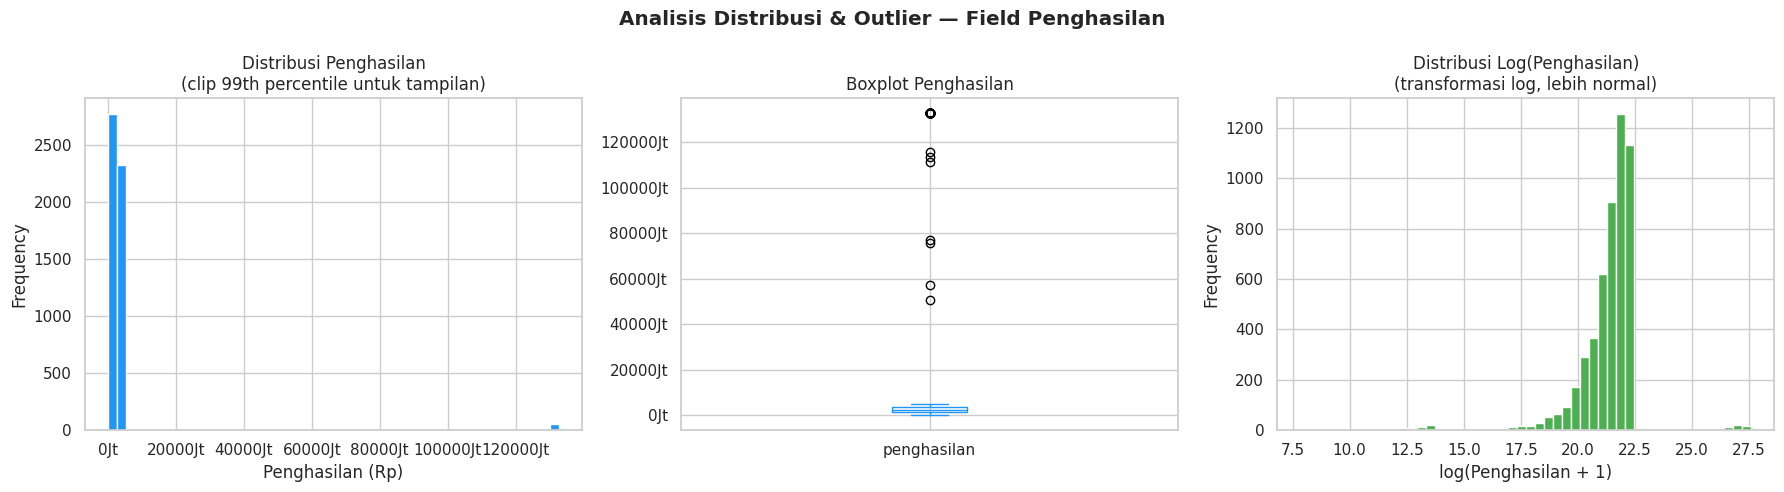

In [35]:
# ============================================================
# CELL 12: DETEKSI OUTLIER — METODE IQR
# IQR = Interquartile Range (Q3 - Q1)
# Outlier: nilai < Q1 - 1.5*IQR  atau  > Q3 + 1.5*IQR
# ============================================================

col = 'penghasilan'

# Hitung statistik IQR
Q1  = df_clean[col].quantile(0.25)
Q3  = df_clean[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifikasi outlier
mask_low  = df_clean[col] < lower_bound
mask_high = df_clean[col] > upper_bound
mask_out  = mask_low | mask_high

n_outlier_low  = mask_low.sum()
n_outlier_high = mask_high.sum()
n_outlier_total= mask_out.sum()

print('📊 DETEKSI OUTLIER — METODE IQR:')
print(f'   Q1 (25th percentile) : Rp {Q1:>20,.0f}')
print(f'   Q3 (75th percentile) : Rp {Q3:>20,.0f}')
print(f'   IQR (Q3 - Q1)        : Rp {IQR:>20,.0f}')
print(f'   Lower Bound          : Rp {lower_bound:>20,.0f}')
print(f'   Upper Bound          : Rp {upper_bound:>20,.0f}')
print(f'')
print(f'   Outlier bawah (terlalu kecil) : {n_outlier_low:>5,} record ({n_outlier_low/len(df_clean)*100:.2f}%)')
print(f'   Outlier atas  (terlalu besar) : {n_outlier_high:>5,} record ({n_outlier_high/len(df_clean)*100:.2f}%)')
print(f'   Total outlier                 : {n_outlier_total:>5,} record ({n_outlier_total/len(df_clean)*100:.2f}%)')

# ── Visualisasi distribusi penghasilan ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analisis Distribusi & Outlier — Field Penghasilan', fontweight='bold')

# Chart 1: Histogram distribusi asli
ax1 = axes[0]
df_clean[col].clip(upper=df_clean[col].quantile(0.99)).plot(
    kind='hist', bins=50, ax=ax1, color='#2196F3', edgecolor='white')
ax1.set_title('Distribusi Penghasilan\n(clip 99th percentile untuk tampilan)')
ax1.set_xlabel('Penghasilan (Rp)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}Jt'))

# Chart 2: Boxplot
ax2 = axes[1]
df_clean[col].clip(upper=df_clean[col].quantile(0.99)).plot(
    kind='box', ax=ax2, color='#2196F3')
ax2.set_title('Boxplot Penghasilan')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{y/1e6:.0f}Jt'))

# Chart 3: Distribusi log-scale (lebih informatif untuk data skewed)
ax3 = axes[2]
np.log1p(df_clean[col]).plot(
    kind='hist', bins=50, ax=ax3, color='#4CAF50', edgecolor='white')
ax3.set_title('Distribusi Log(Penghasilan)\n(transformasi log, lebih normal)')
ax3.set_xlabel('log(Penghasilan + 1)')

plt.tight_layout()
plt.savefig('chart_outlier_penghasilan.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
# ============================================================
# CELL 13: PENANGANAN OUTLIER — WINSORIZING
# Winsorizing: ganti outlier dengan batas yang masuk akal
# (lebih baik dari deletion karena mempertahankan record)
# ============================================================

# Strategi: Winsorizing pada percentile 1% dan 99%
# Artinya: nilai di bawah 1st percentile → set ke 1st percentile
#          nilai di atas 99th percentile → set ke 99th percentile
p01 = df_clean[col].quantile(0.01)  # 1st percentile
p99 = df_clean[col].quantile(0.99)  # 99th percentile

df_clean[f'{col}_original'] = df_clean[col].copy()
df_clean[col]               = df_clean[col].clip(lower=p01, upper=p99)

n_winsorized = (df_clean[col] != df_clean[f'{col}_original']).sum()

audit.log('WINSORIZE_OUTLIER', col, n_winsorized,
    f'Winsorize penghasilan ke rentang [{p01:,.0f} — {p99:,.0f}] (p1-p99)',
    before_sample=f'Min asli: Rp {df_clean[col+"_original"].min():,.0f}',
    after_sample= f'Min baru: Rp {df_clean[col].min():,.0f}',
)

print(f'✅ Winsorizing selesai:')
print(f'   Record diubah    : {n_winsorized:,}')
print(f'   Range penghasilan sebelum: Rp {df_clean[col+"_original"].min():>15,.0f} — Rp {df_clean[col+"_original"].max():>20,.0f}')
print(f'   Range penghasilan sesudah: Rp {df_clean[col].min():>15,.0f} — Rp {df_clean[col].max():>20,.0f}')

# Tambahkan kolom penghasilan_log untuk kebutuhan analitik
df_clean['penghasilan_log'] = np.log1p(df_clean['penghasilan'])
print(f'\n✅ Kolom penghasilan_log ditambahkan (nilai log1p untuk analitik)')


  [18] 🟢 WINSORIZE_OUTLIER      | penghasilan          |    104 record (  2.0%)
       Sebelum: Min asli: Rp 2,492
       Sesudah: Min baru: Rp 939,635
✅ Winsorizing selesai:
   Record diubah    : 104
   Range penghasilan sebelum: Rp           2,492 — Rp      980,970,423,050
   Range penghasilan sesudah: Rp         939,635 — Rp      132,792,877,125

✅ Kolom penghasilan_log ditambahkan (nilai log1p untuk analitik)


In [37]:
df_clean.head()

,id_record,npwp,nik,nama_wp,jenis_wp,status_wp,status_pkp,kode_kpp,nama_kpp,kode_provinsi,nama_provinsi,alamat,kelurahan,kota,kode_pos,klu_kode,klu_nama,email,telepon,penghasilan,tanggal_daftar,nama_wp_original,alamat_original,npwp_original,npwp_status,npwp_note,nik_original,nik_status,telepon_original,email_original,telepon_status,email_status,flag_review,nama_provinsi_original,nama_kpp_original,kode_provinsi_raw,kode_kpp_raw,kode_provinsi_clean,kode_kpp_clean,nama_provinsi_ref,provinsi_status,nama_kpp_ref,kpp_status,status_wp_original,penghasilan_original,penghasilan_log
0,WP001177,05.706.750.7-055.482,None,Firma UD Pratama Mandasari Persero Tbk,Badan,Hapus,PKP,641,KPP Pratama Jakarta Barat Satu,31,DKI Jakarta,Jl. Gardujati No. 520,Batam,Jayapura,01626,62010.00,Aktivitas Pemrograman Komputer,widiastutijasmin@example.com,None,505403332.00,2011-02-08,Firma. UD Pratama Mandasari (Persero) Tbk,Jl. Gardujati No.. 520,05.706.750.7-055.482,VALID,Format sudah benar,NaN,N/A,+62-079-337-7312,widiastutijasmin@example.com,INVALID,VALID,None,NaN,KPP TIDAK DIKENAL,31,641,31,0641,DKI Jakarta,MISMATCH,KPP Pratama Jakarta Barat Satu,MISMATCH,Hapus,505403332,20.04
1,WP004771,00.376.779.9-293.321,3114131309680781,Irsad Samosir,Orang Pribadi,Aktif,PKP,610,KPP Pratama Jakarta Pusat Satu,31,DKI Jakarta,Gg. Yos Sudarso No. 7,Tual,Kota Administrasi Jakarta Timur,11549,99999,BELUM TERKLASIFIKASI,bakionokuswandari@example.net,None,2096723837.00,2010-02-13,Irsad Samosir,Gg. Yos Sudarso No.. 7,00.376.779.9-293.321,VALID,Format sudah benar,3114131309680781,VALID,(0389) 918-7667,bakionokuswandari@example.net,INVALID,VALID,None,NaN,KPP TIDAK DIKENAL,31,610,31,0610,DKI Jakarta,MISMATCH,KPP Pratama Jakarta Pusat Satu,MISMATCH,Aktif,2096723837,21.46
2,WP001091,03.418.588.7-880.078,None,PT UD Prastuti Tampubolon Tbk,Badan,Aktif,PKP,1211,KPP Pratama Makassar Utara,73,Sulawesi Selatan,Jl. Ciumbuleuit No. 3,Samarinda,Bima,77593,23910.00,Produk Abrasif dan Sejenisnya,rezanababan@example.net,None,3288106224.00,2020-02-25,PT. UD Prastuti Tampubolon Tbk,Jl. Ciumbuleuit No.. 3,03.418.588.7-880.078,VALID,Format sudah benar,NaN,N/A,(059) 727 6768,rezanababan@example.net,INVALID,VALID,None,NaN,KPP TIDAK DIKENAL,73,1211,73,1211,Sulawesi Selatan,MISMATCH,KPP Pratama Makassar Utara,MISMATCH,Aktif,3288106224,21.91
3,WP004818,00.641.152.2-702.325,None,Firma PD Haryanto Tbk,Badan,Aktif,Non-PKP,641,KPP Pratama Jakarta Barat Satu,31,DKI Jakarta,Jl. M.T Haryono No. 915,Palu,Pematangsiantar,37288,10101.00,Pengolahan dan Pengawetan Daging,vivi55@example.org,None,335534994.00,2024-09-07,FIRMA. PD HARYANTO TBK,Jl.. M.T Haryono No.. 915,00.641.152.2-702.325,VALID,Format sudah benar,NaN,N/A,NaN,vivi55@example.org,MISSING,VALID,None,NaN,KPP TIDAK DIKENAL,31,641,31,0641,DKI Jakarta,MISMATCH,KPP Pratama Jakarta Barat Satu,MISMATCH,Aktif,335534994,19.63
4,WP004376,05.879.262.4-547.834,None,Koperasi Perum Halim Kusmawati,Badan,Aktif,Non-PKP,711,KPP Pratama Bandung Cibeunying,32,Jawa Barat,Jl. Cikutra Timur No. 24,Tangerang Selatan,Pematangsiantar,14434,96090.00,Jasa Perorangan Lainnya,wp.004376@noemail.djp.go.id,None,344528173.00,2023-05-14,KOPERASI. PERUM HALIM KUSMAWATI,Jl. Cikutra Timur No.. 24,05.879.262.4-547.834,VALID,Format sudah benar,NaN,N/A,+62 (129) 940-1146,NaN,INVALID,MISSING,None,NaN,KPP TIDAK DIKENAL,32,711,32,0711,Jawa Barat,MISMATCH,KPP Pratama Bandung Cibeunying,MISMATCH,Aktif,344528173,19.66


In [38]:
# ============================================================
# CELL 14: QUALITY GATE — PEMERIKSAAN OTOMATIS
# Semua gate harus PASS sebelum dataset diekspor
# ============================================================

class QualityGate:
    """Runner untuk quality gate checks."""
    def __init__(self, df):
        self.df      = df
        self.results = []
        self.all_pass= True

    def check(self, gate_name, condition_fn, threshold, description):
        """
        Jalankan satu quality gate.
        condition_fn: fungsi yang mengembalikan nilai (float/int)
        threshold: nilai minimum yang harus dipenuhi
        """
        try:
            value  = condition_fn(self.df)
            passed = value >= threshold
            status = '✅ PASS' if passed else '❌ FAIL'
            if not passed: self.all_pass = False
        except Exception as e:
            value  = -1
            passed = False
            status = f'💥 ERROR: {e}'
            self.all_pass = False

        self.results.append({
            'Gate'      : gate_name,
            'Deskripsi' : description,
            'Nilai'     : f'{value:.2f}' if isinstance(value, float) else str(value),
            'Threshold' : str(threshold),
            'Status'    : status,
        })
        print(f'   {status}  {gate_name:<30} | Nilai: {str(value):<10} | Min: {threshold}')

    def report(self):
        print('\n' + '='*70)
        verdict = '✅ SEMUA GATE PASSED — Dataset siap diekspor!' if self.all_pass \
                  else '❌ ADA GATE YANG GAGAL — Perbaiki sebelum export!'
        print(f'  HASIL QUALITY GATE: {verdict}')
        print('='*70)
        return pd.DataFrame(self.results)


# Inisialisasi dan jalankan quality gate
qg = QualityGate(df_clean)
print('🔍 MENJALANKAN QUALITY GATE...')
print('-'*70)

# Gate 1: Field kritis tidak boleh null
qg.check('NO_NULL_NPWP',
    lambda d: 100 - d['npwp'].isna().mean()*100, 100,
    'Completeness NPWP = 100%')

qg.check('NO_NULL_NAMA',
    lambda d: 100 - d['nama_wp'].isna().mean()*100, 100,
    'Completeness nama_wp = 100%')

qg.check('NO_NULL_JENIS',
    lambda d: 100 - d['jenis_wp'].isna().mean()*100, 100,
    'Completeness jenis_wp = 100%')

# Gate 2: Format NPWP minimal 90% valid
NPWP_PAT = r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'
qg.check('NPWP_FORMAT_90PCT',
    lambda d: d['npwp'].str.match(NPWP_PAT).mean()*100, 90,
    'Format NPWP valid >= 90%')

# Gate 3: Status WP hanya nilai yang valid
valid_sw = ['Aktif','Non-Aktif','Hapus']
qg.check('STATUS_WP_VALID',
    lambda d: d['status_wp'].isin(valid_sw).mean()*100, 100,
    'Semua status_wp adalah nilai yang valid')

# Gate 4: Tidak ada exact duplicate pada NPWP + nama (setelah standardisasi)
qg.check('NO_EXACT_DUP',
    lambda d: 100 - d.duplicated(subset=['npwp','nama_wp']).mean()*100, 95,
    'Duplikat NPWP+Nama <= 5%')

# Gate 5: Kode provinsi terisi semua
qg.check('PROVINSI_COMPLETE',
    lambda d: 100 - d['kode_provinsi'].isna().mean()*100, 100,
    'Completeness kode_provinsi = 100%')

# Gate 6: Penghasilan tidak negatif
qg.check('PENGHASILAN_POSITIVE',
    lambda d: (d['penghasilan'] > 0).mean()*100, 99,
    'Penghasilan > 0 pada >= 99% record')

# Tampilkan hasil
gate_df = qg.report()
display(gate_df)


🔍 MENJALANKAN QUALITY GATE...
----------------------------------------------------------------------
   ✅ PASS  NO_NULL_NPWP                   | Nilai: 100.0      | Min: 100
   ✅ PASS  NO_NULL_NAMA                   | Nilai: 100.0      | Min: 100
   ✅ PASS  NO_NULL_JENIS                  | Nilai: 100.0      | Min: 100
   ✅ PASS  NPWP_FORMAT_90PCT              | Nilai: 93.39805825242719 | Min: 90
   ✅ PASS  STATUS_WP_VALID                | Nilai: 100.0      | Min: 100
   ✅ PASS  NO_EXACT_DUP                   | Nilai: 97.0873786407767 | Min: 95
   ✅ PASS  PROVINSI_COMPLETE              | Nilai: 100.0      | Min: 100
   ✅ PASS  PENGHASILAN_POSITIVE           | Nilai: 100.0      | Min: 99

  HASIL QUALITY GATE: ✅ SEMUA GATE PASSED — Dataset siap diekspor!


,Gate,Deskripsi,Nilai,Threshold,Status
0,NO_NULL_NPWP,Completeness NPWP = 100%,100.00,100,✅ PASS
1,NO_NULL_NAMA,Completeness nama_wp = 100%,100.00,100,✅ PASS
2,NO_NULL_JENIS,Completeness jenis_wp = 100%,100.00,100,✅ PASS
3,NPWP_FORMAT_90PCT,Format NPWP valid >= 90%,93.40,90,✅ PASS
4,STATUS_WP_VALID,Semua status_wp adalah nilai yang valid,100.00,100,✅ PASS
5,NO_EXACT_DUP,Duplikat NPWP+Nama <= 5%,97.09,95,✅ PASS
6,PROVINSI_COMPLETE,Completeness kode_provinsi = 100%,100.00,100,✅ PASS
7,PENGHASILAN_POSITIVE,Penghasilan > 0 pada >= 99% record,100.00,99,✅ PASS


In [39]:
import pandas as pd
from datetime import datetime

# ============================================================
# CELL 15: EXPORT CLEAN DATASET & LAPORAN AUDIT TRAIL
# ============================================================

# ── Buat kolom metadata cleansing ──
df_clean['cleansed_at']      = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
df_clean['cleansing_version'] = 'LAB2_v1.0'

# ── Pilih kolom untuk clean dataset (hanya kolom cleansing yang dipertahankan) ──
# Kolom-kolom hasil cleansing yang akan dipertahankan dalam dataset final.
# Kolom original, helper, dan status akan dihapus.
# columns_to_keep = [
#     'id_record', 'npwp', 'nik', 'nama_wp', 'jenis_wp', 'status_wp',
#     'status_pkp', 'kode_kpp', 'nama_kpp', 'kode_provinsi', 'nama_provinsi',
#     'alamat', 'kelurahan', 'kota', 'kode_pos', 'klu_kode', 'klu_nama',
#     'email', 'telepon', 'penghasilan', 'tanggal_daftar', 'flag_review',
#     'kode_provinsi_clean', 'kode_kpp_clean', 'penghasilan_log',
#     'cleansed_at', 'cleansing_version'
# ]

columns_to_keep = [
    'id_record', 'npwp', 'nik', 'nama_wp', 'jenis_wp', 'status_wp',
    'status_pkp', 'kode_kpp', 'nama_kpp', 'kode_provinsi', 'nama_provinsi',
    'alamat', 'kelurahan', 'kota', 'kode_pos', 'klu_kode', 'klu_nama',
    'email', 'telepon', 'penghasilan', 'tanggal_daftar'
]
df_export = df_clean[columns_to_keep].copy()

# ── Export 1: Clean Dataset ──
df_export.to_csv('dataset_wp_clean.csv', index=False)
print(f'✅ Clean dataset disimpan: dataset_wp_clean.csv')
print(f'   Shape : {df_export.shape}')
print(f'   Kolom : {list(df_export.columns)}')

# ── Export 2: Audit Trail ──
audit_df = audit.to_dataframe()
audit_df.to_csv('audit_trail_lab2.csv', index=False)
print(f'\n✅ Audit trail disimpan: audit_trail_lab2.csv')
print(f'   Total operasi dicatat: {len(audit_df)}')

# ── Export 3: Flag Review (record perlu verifikasi manual) ──
review_df = df_clean[df_clean['flag_review'].notna()][
    ['id_record','npwp','nama_wp','jenis_wp','flag_review']
]
review_df.to_csv('flagged_records_lab2.csv', index=False)
print(f'\n✅ Flagged records disimpan: flagged_records_lab2.csv')
print(f'   Record perlu review: {len(review_df):,}')

# ── Tampilkan Audit Trail Summary ──
audit.summary()

✅ Clean dataset disimpan: dataset_wp_clean.csv
   Shape : (5150, 21)
   Kolom : ['id_record', 'npwp', 'nik', 'nama_wp', 'jenis_wp', 'status_wp', 'status_pkp', 'kode_kpp', 'nama_kpp', 'kode_provinsi', 'nama_provinsi', 'alamat', 'kelurahan', 'kota', 'kode_pos', 'klu_kode', 'klu_nama', 'email', 'telepon', 'penghasilan', 'tanggal_daftar']

✅ Audit trail disimpan: audit_trail_lab2.csv
   Total operasi dicatat: 18

✅ Flagged records disimpan: flagged_records_lab2.csv
   Record perlu review: 131

  AUDIT TRAIL SUMMARY — Master Data Wajib Pajak
  Durasi proses : 6 detik
  Total operasi : 18
  Step  Operasi                Field                Affected  Persen
----------------------------------------------------------------------
     1  STANDARDIZE_TEXT       nama_wp                 3,222   62.6%
     2  STANDARDIZE_TEXT       alamat                  5,150  100.0%
     3  STANDARDIZE_TEXT       alamat                  5,150  100.0%
     4  FORMAT_NPWP            npwp                       84   

  PERBANDINGAN DQ SCORE — BEFORE vs AFTER CLEANSING
Dimensi            Before     After     Delta  Status
-----------------------------------------------------------------
Completeness       97.50%   100.00%  ⬆  2.50%
Validity           89.00%    93.40%  ⬆  4.40%
Uniqueness         94.50%    97.09%  ⬆  2.59%
Consistency        85.00%   100.00%  ⬆ 15.00%
Timeliness         99.80%   100.00%  ⬆  0.20%
Accuracy          100.00%     0.00%  ⬇100.00%
TOTAL DQ SCORE     93.38%    87.77%  ⬆-5.61%


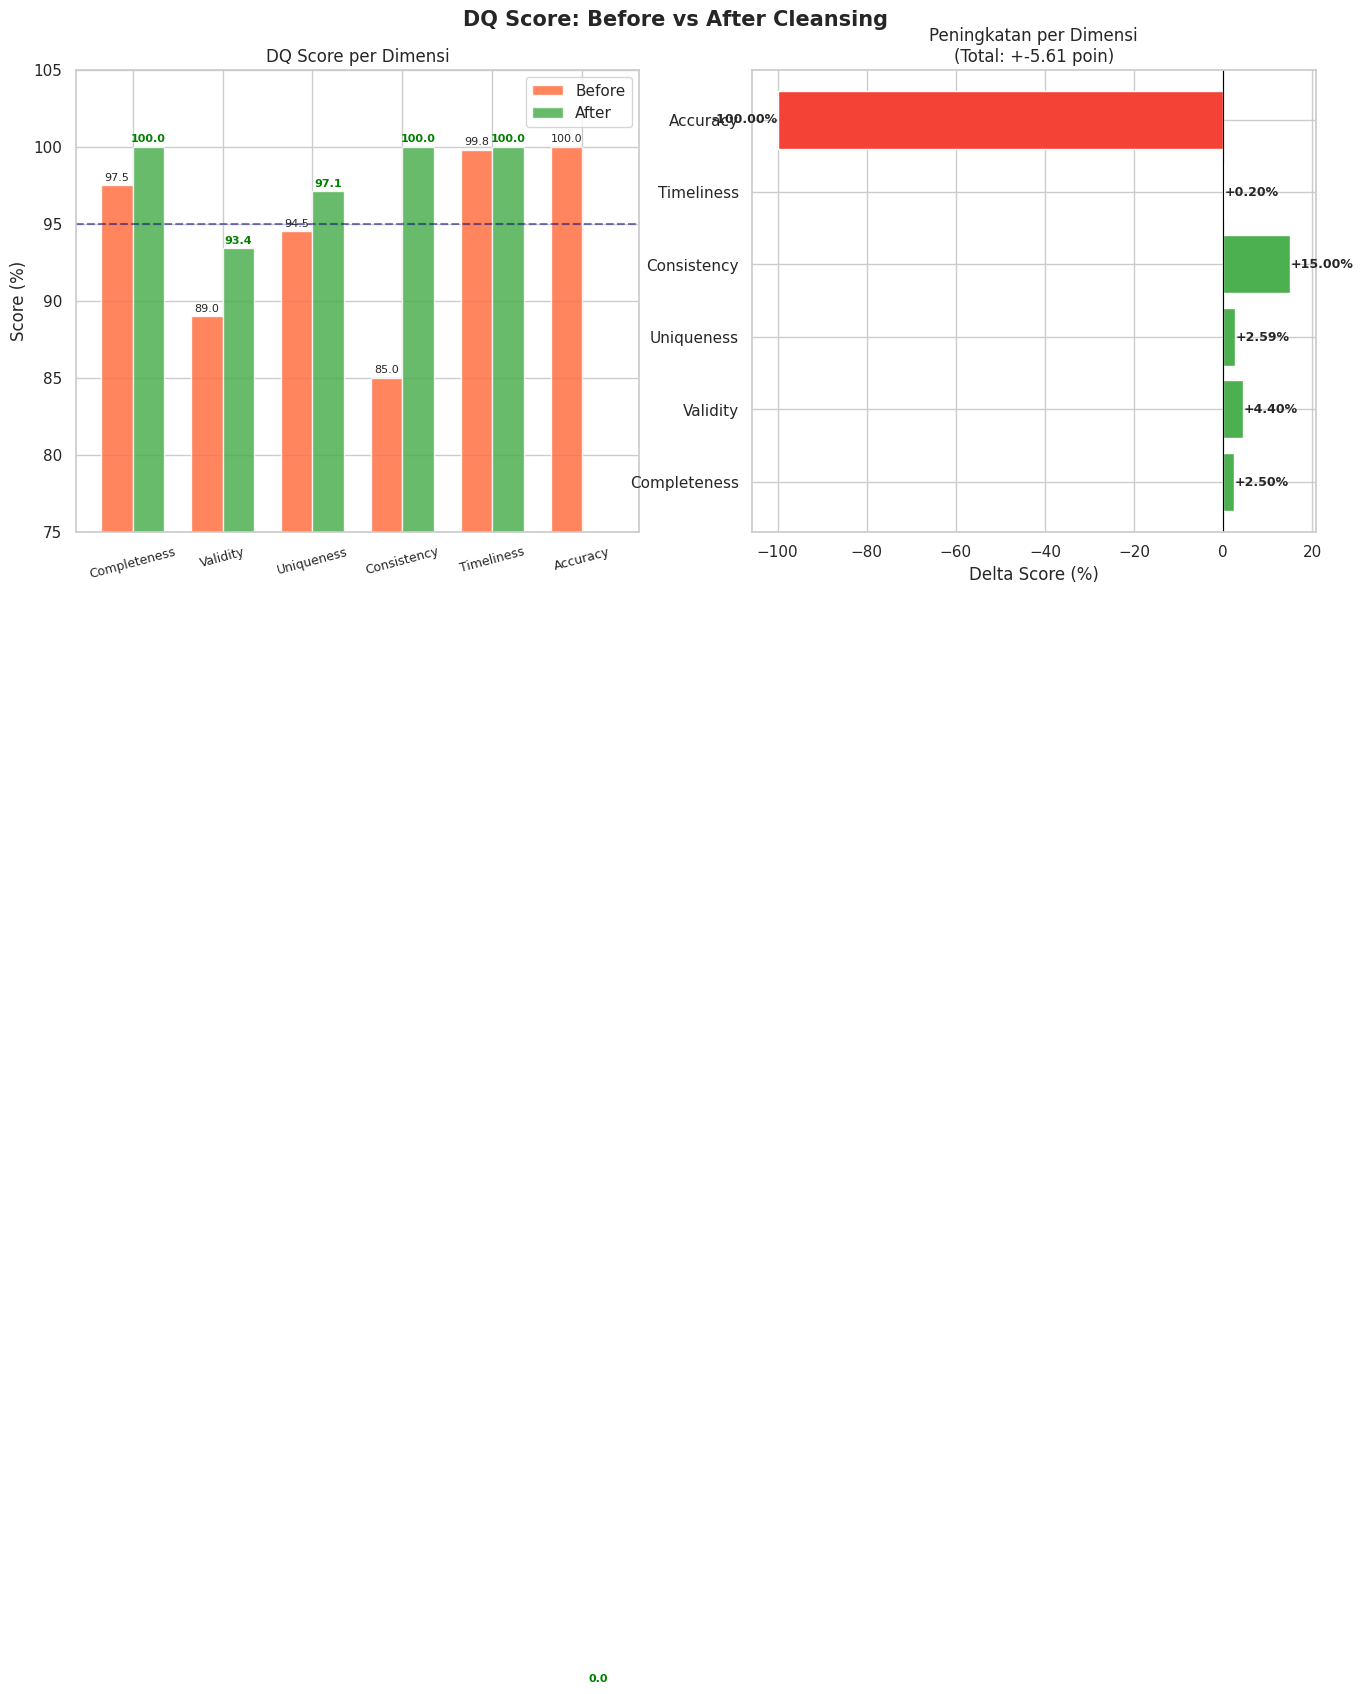

💾 Chart disimpan: chart_dq_before_after.png

🏁 LAB 2 SELESAI! Dataset bersih siap untuk LAB 3: Duplicate Detection & Matching


In [40]:
# ============================================================
# CELL 16: PERBANDINGAN DQ SCORE BEFORE vs AFTER CLEANSING
# ============================================================

# DQ Score SEBELUM (dari LAB 1, referensi manual)
dq_before = {
    'Completeness' : 97.5,
    'Validity'     : 89.0,
    'Uniqueness'   : 94.5,
    'Consistency'  : 85.0,
    'Timeliness'   : 99.8,
    'Accuracy'     : 100.0,
}

# DQ Score SESUDAH cleansing — hitung ulang
NPWP_PAT2  = r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'
df_op_clean = df_clean[df_clean['jenis_wp']=='Orang Pribadi']

dq_after = {
    'Completeness' : (1 - df_clean[['npwp','nama_wp','jenis_wp',
                          'status_wp','kode_kpp','kode_provinsi']].isna().mean().mean()) * 100,
    'Validity'     : (df_clean['npwp'].str.match(NPWP_PAT2).mean()) * 100,
    'Uniqueness'   : (1 - df_clean.duplicated(subset=['npwp']).mean()) * 100,
    'Consistency'  : (1 - df_clean['nama_wp'].apply(
                          lambda x: str(x).isupper() or str(x).islower()
                          if pd.notna(x) else False).mean()) * 100,
    'Timeliness'   : (1 - (pd.to_datetime(df_clean['tanggal_daftar'],errors='coerce')
                          > pd.Timestamp.now()).mean()) * 100,
    'Accuracy'     : (df_clean['nama_provinsi'] == df_clean['kode_provinsi'].map(
                          PROVINSI_REF)).mean() * 100,
}

# Bobot dimensi
weights = {'Completeness':0.20,'Validity':0.25,'Uniqueness':0.20,
           'Consistency':0.15,'Timeliness':0.10,'Accuracy':0.10}

total_before = sum(dq_before[d]*weights[d] for d in weights)
total_after  = sum(dq_after[d] *weights[d] for d in weights)

# ── Print perbandingan ──
print('='*65)
print('  PERBANDINGAN DQ SCORE — BEFORE vs AFTER CLEANSING')
print('='*65)
print(f'{"Dimensi":<16} {"Before":>8}  {"After":>8}  {"Delta":>8}  Status')
print('-'*65)
for dim in weights:
    b   = dq_before[dim]
    a   = dq_after[dim]
    d   = a - b
    ico = '⬆' if d > 0 else ('⬇' if d < 0 else '=')
    print(f'{dim:<16} {b:>7.2f}%  {a:>7.2f}%  {ico}{abs(d):>6.2f}%')
print('='*65)
print(f'{"TOTAL DQ SCORE":<16} {total_before:>7.2f}%  {total_after:>7.2f}%  ⬆{total_after-total_before:.2f}%')
print('='*65)

# ── Visualisasi Before vs After ──
dims   = list(weights.keys())
before = [dq_before[d] for d in dims]
after  = [dq_after[d]  for d in dims]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DQ Score: Before vs After Cleansing', fontsize=15, fontweight='bold')

# Chart 1: Grouped Bar
ax1  = axes[0]
x    = np.arange(len(dims))
w    = 0.35
ax1.bar(x-w/2, before, w, label='Before', color='#FF7043', alpha=0.85)
ax1.bar(x+w/2, after,  w, label='After',  color='#4CAF50', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(dims, fontsize=9, rotation=15)
ax1.set_ylim(75, 105); ax1.set_ylabel('Score (%)')
ax1.axhline(y=95, color='navy', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.legend(); ax1.set_title('DQ Score per Dimensi')
for i,(b,a) in enumerate(zip(before,after)):
    ax1.text(i-w/2, b+0.3, f'{b:.1f}', ha='center', fontsize=8)
    ax1.text(i+w/2, a+0.3, f'{a:.1f}', ha='center', fontsize=8, color='green', fontweight='bold')

# Chart 2: Delta improvement
ax2    = axes[1]
deltas = [a-b for a,b in zip(after,before)]
colors = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]
ax2.barh(dims, deltas, color=colors, edgecolor='white')
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Delta Score (%)')
ax2.set_title(f'Peningkatan per Dimensi\n(Total: +{total_after-total_before:.2f} poin)')
for i,d in enumerate(deltas):
    ax2.text(d+0.1 if d>=0 else d-0.1, i, f'+{d:.2f}%' if d>=0 else f'{d:.2f}%',
             va='center', ha='left' if d>=0 else 'right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_dq_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart disimpan: chart_dq_before_after.png')
print('\n🏁 LAB 2 SELESAI! Dataset bersih siap untuk LAB 3: Duplicate Detection & Matching')


**DUPLICATE DETECTION
& MATCHING**


In [41]:
# ============================================================
# CELL 1: INSTALL LIBRARY LAB 3
# ============================================================

!pip install recordlinkage fuzzywuzzy python-Levenshtein jellyfish -q
!pip install networkx -q   # untuk visualisasi cluster duplikat

print('✅ Library berhasil diinstall:')
print('   recordlinkage : framework record linkage & deduplication')
print('   fuzzywuzzy    : fuzzy string matching (token sort, partial ratio)')
print('   jellyfish     : Jaro-Winkler, Soundex, Levenshtein distance')
print('   networkx      : analisis dan visualisasi graf duplikat cluster')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.9/926.9 kB 3.3 MB/s eta 0:00:00
✅ Library berhasil diinstall:
   recordlinkage : framework record linkage & deduplication
   fuzzywuzzy    : fuzzy string matching (token sort, partial ratio)
   jellyfish     : Jaro-Winkler, Soundex, Levenshtein distance
   networkx      : analisis dan visualisasi graf duplikat cluster


In [42]:
# ============================================================
# CELL 2: IMPORT LIBRARY & LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import re, warnings, time
from datetime import datetime
from itertools import combinations
warnings.filterwarnings('ignore')

# String matching
from fuzzywuzzy import fuzz, process
import jellyfish
import recordlinkage
from recordlinkage.index import Block, SortedNeighbourhood

# Graf dan visualisasi
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

# ── Load dataset LAB 2 ──
try:
    df = pd.read_csv('dataset_wp_clean.csv')
    df['tanggal_daftar'] = pd.to_datetime(df['tanggal_daftar'], errors='coerce')
    print(f'✅ Dataset LAB 2 berhasil dimuat')
    print(f'   Shape  : {df.shape}')
    print(f'   Kolom  : {list(df.columns)}')
except FileNotFoundError:
    print('❌ File tidak ditemukan. Pastikan LAB 2 sudah selesai.')
    raise

# Simpan salinan untuk referensi
df_original = df.copy()
print(f'\n   Contoh data (3 baris pertama):')
display(df[['id_record','npwp','nama_wp','jenis_wp','kode_kpp','status_wp']].head(3))




✅ Dataset LAB 2 berhasil dimuat
   Shape  : (5150, 21)
   Kolom  : ['id_record', 'npwp', 'nik', 'nama_wp', 'jenis_wp', 'status_wp', 'status_pkp', 'kode_kpp', 'nama_kpp', 'kode_provinsi', 'nama_provinsi', 'alamat', 'kelurahan', 'kota', 'kode_pos', 'klu_kode', 'klu_nama', 'email', 'telepon', 'penghasilan', 'tanggal_daftar']

   Contoh data (3 baris pertama):


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
0,WP001177,05.706.750.7-055.482,Firma UD Pratama Mandasari Persero Tbk,Badan,641,Hapus
1,WP004771,00.376.779.9-293.321,Irsad Samosir,Orang Pribadi,610,Aktif
2,WP001091,03.418.588.7-880.078,PT UD Prastuti Tampubolon Tbk,Badan,1211,Aktif


In [43]:
# ============================================================
# CELL 3: PERSIAPAN MATCHING KEYS
# Buat kolom normalisasi khusus untuk proses matching
# ============================================================

def normalize_for_matching(text) -> str:
    """
    Normalisasi teks khusus untuk matching — lebih agresif dari standardisasi biasa.
    Tujuan: buat dua teks yang 'sama secara semantik' menjadi identik atau hampir identik.
    """
    if pd.isna(text): return ''
    s = str(text).upper()           # uppercase semua
    s = re.sub(r'\bPT\.?\b', 'PT', s)    # hapus titik dari PT.
    s = re.sub(r'\bCV\.?\b', 'CV', s)
    s = re.sub(r'\bUD\.?\b', 'UD', s)
    s = re.sub(r'[^A-Z0-9\s]', '', s) # hapus semua non-alfanumerik
    s = re.sub(r'\s+', ' ', s)         # normalisasi spasi
    return s.strip()

def extract_npwp_digits(npww) -> str:
    """Ekstrak hanya digit dari NPWP — untuk matching tanpa mempedulikan separator."""
    if pd.isna(npww): return ''
    return re.sub(r'\D', '', str(npww))


# Buat kolom kunci matching
df['nama_key']  = df['nama_wp'].apply(normalize_for_matching)
df['npwp_digits']= df['npwp'].apply(extract_npwp_digits)

# Blocking key: 4 karakter pertama nama (untuk efisiensi)
df['nama_block'] = df['nama_key'].str[:4]

# Blocking key: 6 digit pertama NPWP (kode WP)
df['npwp_block'] = df['npwp_digits'].str[:6]

print('✅ Matching keys berhasil dibuat:')
print(f'   nama_key   : nama ternormalisasi (uppercase, tanpa karakter khusus)')
print(f'   npwp_digits: hanya digit NPWP tanpa separator')
print(f'   nama_block : 4 karakter pertama nama (untuk blocking)')
print(f'   npwp_block : 6 digit pertama NPWP (untuk blocking)')
print(f'')
print('Contoh 5 record:')
display(df[['nama_wp','nama_key','npwp','npwp_digits','nama_block','npwp_block']].head(5))



✅ Matching keys berhasil dibuat:
   nama_key   : nama ternormalisasi (uppercase, tanpa karakter khusus)
   npwp_digits: hanya digit NPWP tanpa separator
   nama_block : 4 karakter pertama nama (untuk blocking)
   npwp_block : 6 digit pertama NPWP (untuk blocking)

Contoh 5 record:


,nama_wp,nama_key,npwp,npwp_digits,nama_block,npwp_block
0,Firma UD Pratama Mandasari Persero Tbk,FIRMA UD PRATAMA MANDASARI PERSERO TBK,05.706.750.7-055.482,057067507055482,FIRM,057067
1,Irsad Samosir,IRSAD SAMOSIR,00.376.779.9-293.321,003767799293321,IRSA,003767
2,PT UD Prastuti Tampubolon Tbk,PT UD PRASTUTI TAMPUBOLON TBK,03.418.588.7-880.078,034185887880078,PT U,034185
3,Firma PD Haryanto Tbk,FIRMA PD HARYANTO TBK,00.641.152.2-702.325,006411522702325,FIRM,006411
4,Koperasi Perum Halim Kusmawati,KOPERASI PERUM HALIM KUSMAWATI,05.879.262.4-547.834,058792624547834,KOPE,058792


In [44]:
# ============================================================
# CELL 4: EXACT MATCH — NPWP DUPLICATE
# Record dengan digit NPWP identik = kandidat duplikat kuat
# ============================================================

print('🔍 EXACT MATCH — NPWP DUPLICATE:')
print('='*60)

# Gunakan npwp_digits (tanpa separator) untuk menghindari false negative
# karena format separator berbeda antar sistem
npwp_counts = df.groupby('npwp_digits').size().reset_index(name='frekuensi')
npwp_dup    = npwp_counts[npwp_counts['frekuensi'] > 1].sort_values('frekuensi', ascending=False)

print(f'Total NPWP unik          : {len(npwp_counts):,}')
print(f'NPWP dengan duplikat     : {len(npwp_dup):,}')
print(f'Total record terdampak   : {npwp_dup["frekuensi"].sum():,}')
print(f'Persentase duplikat      : {len(df[df["npwp_digits"].isin(npwp_dup["npwp_digits"])])/len(df)*100:.2f}%')

# Buat dataframe kandidat duplikat berdasarkan NPWP
df_npwp_dup = df[df['npwp_digits'].isin(npwp_dup['npwp_digits'])].copy()
df_npwp_dup = df_npwp_dup.sort_values(['npwp_digits','id_record'])

print(f'\n📄 Contoh kelompok NPWP duplikat (tampilkan 2 kelompok):')
top2_npwp = npwp_dup.head(2)['npwp_digits'].tolist()
for npwp in top2_npwp:
    print(f'\n   NPWP Digits: {npwp}')
    sample = df[df['npwp_digits']==npwp][
        ['id_record','npwp','nama_wp','jenis_wp','kode_kpp','status_wp']
    ]
    display(sample)

# Simpan hasil exact match NPWP
df_npwp_dup.to_csv('exact_dup_npwp.csv', index=False)
print(f'\n💾 Hasil exact match NPWP disimpan: exact_dup_npwp.csv')



🔍 EXACT MATCH — NPWP DUPLICATE:
Total NPWP unik          : 5,000
NPWP dengan duplikat     : 150
Total record terdampak   : 300
Persentase duplikat      : 5.83%

📄 Contoh kelompok NPWP duplikat (tampilkan 2 kelompok):

   NPWP Digits: 000050583388097


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
114,WP001554,00.005.058.3-388.097,PT Perum Hutapea Persero Tbk,Badan,911,Aktif
3008,WP001554_DUP,00.005.058.3-388.097,PT Perum Hutapea Persero Tbk,Badan,911,Aktif



   NPWP Digits: 000588430985501


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
161,WP000107,00.058.843.0-985.501,Gamblang Hutagalung,Orang Pribadi,622,Aktif
3981,WP000107_DUP,00.058.843.0-985.501,Gamblang Hutagalung,Orang Pribadi,622,Aktif



💾 Hasil exact match NPWP disimpan: exact_dup_npwp.csv


In [45]:
# ============================================================
# CELL 5: EXACT MATCH — KOMBINASI MULTI-FIELD
# Semakin banyak field yang cocok, semakin yakin ini duplikat
# ============================================================

print('🔍 EXACT MATCH — KOMBINASI MULTI-FIELD:')
print('='*60)

# Definisikan set kombinasi field untuk exact matching
match_configs = [
    {'fields': ['npwp_digits'],                        'label': 'NPWP saja'},
    {'fields': ['nama_key', 'kode_kpp'],               'label': 'Nama + KPP'},
    {'fields': ['npwp_digits', 'nama_key'],            'label': 'NPWP + Nama'},
    {'fields': ['nama_key', 'kode_kpp', 'jenis_wp'],   'label': 'Nama + KPP + Jenis'},
    {'fields': ['npwp_digits', 'nama_key', 'kode_kpp'],'label': 'NPWP + Nama + KPP'},
]

print(f'  {"Kombinasi Field":<30} {"Duplikat":>10}  {"Record":>10}  {"Persen":>8}')
print('-'*65)

exact_results = {}
for cfg in match_configs:
    fields = cfg['fields']
    label  = cfg['label']

    # Hitung duplikat
    grp    = df.groupby(fields).size().reset_index(name='cnt')
    dup    = grp[grp['cnt'] > 1]
    n_dup_keys   = len(dup)
    n_dup_records= df[df.set_index(fields).index.isin(
        dup.set_index(fields).index)].shape[0] if n_dup_keys > 0 else 0
    pct  = n_dup_records / len(df) * 100

    exact_results[label] = {'n_dup_keys':n_dup_keys, 'n_records':n_dup_records, 'pct':pct}
    icon = '🔴' if pct > 5 else '🟡' if pct > 1 else '🟢'
    print(f'  {icon} {label:<28} {n_dup_keys:>10,}  {n_dup_records:>10,}  {pct:>7.2f}%')

print('\n💡 Interpretasi:')
print('   Semakin banyak field yang dikombinasikan → semakin akurat (presisi tinggi)')
print('   Tapi recall bisa lebih rendah (miss duplikat yang data-nya sedikit berbeda)')



🔍 EXACT MATCH — KOMBINASI MULTI-FIELD:
  Kombinasi Field                  Duplikat      Record    Persen
-----------------------------------------------------------------
  🔴 NPWP saja                           150         300     5.83%
  🔴 Nama + KPP                          158         316     6.14%
  🔴 NPWP + Nama                         150         300     5.83%
  🔴 Nama + KPP + Jenis                  158         316     6.14%
  🔴 NPWP + Nama + KPP                   150         300     5.83%

💡 Interpretasi:
   Semakin banyak field yang dikombinasikan → semakin akurat (presisi tinggi)
   Tapi recall bisa lebih rendah (miss duplikat yang data-nya sedikit berbeda)


In [46]:
# ============================================================
# CELL 6: STANDARD BLOCKING — MENGGUNAKAN recordlinkage
# ============================================================

# Set index dataframe untuk recordlinkage
df_idx = df.set_index('id_record')

print('📊 ANALISIS EFISIENSI BLOCKING:')
print('='*65)

n_records = len(df_idx)
n_brute   = n_records * (n_records - 1) // 2
print(f'   Total record          : {n_records:,}')
print(f'   Perbandingan brute force : {n_brute:,}  (O(n²/2))')
print()

# ── Blocking 1: berdasarkan npwp_block (6 digit pertama NPWP) ──
indexer1 = recordlinkage.Index()
indexer1.block('npwp_block')
candidate_links1 = indexer1.index(df_idx)
n1 = len(candidate_links1)

# ── Blocking 2: berdasarkan nama_block (4 karakter pertama nama) ──
indexer2 = recordlinkage.Index()
indexer2.block('nama_block')
candidate_links2 = indexer2.index(df_idx)
n2 = len(candidate_links2)

# ── Blocking 3: berdasarkan kode_kpp ──
indexer3 = recordlinkage.Index()
indexer3.block('kode_kpp')
candidate_links3 = indexer3.index(df_idx)
n3 = len(candidate_links3)

print(f'   {"Strategi Blocking":<30} {"Kandidat Pasang":>16}  {"Reduksi":>8}')
print('-'*65)

configs = [
    ('Brute Force (tanpa blocking)',  n_brute, 0),
    ('Block: NPWP 6 digit pertama',   n1,      (1-n1/n_brute)*100),
    ('Block: Nama 4 char pertama',    n2,      (1-n2/n_brute)*100),
    ('Block: Kode KPP',              n3,      (1-n3/n_brute)*100),
]
for label, n, red in configs:
    print(f'   {label:<30} {n:>16,}  {red:>7.1f}%')

print(f'\n💡 Blocking "NPWP 6 digit" mereduksi kandidat sebesar {(1-n1/n_brute)*100:.1f}%!')
print(f'   Artinya: dari {n_brute:,} → {n1:,} perbandingan yang perlu dilakukan.')



📊 ANALISIS EFISIENSI BLOCKING:
   Total record          : 5,150
   Perbandingan brute force : 13,258,675  (O(n²/2))

   Strategi Blocking               Kandidat Pasang   Reduksi
-----------------------------------------------------------------
   Brute Force (tanpa blocking)         13,258,675      0.0%
   Block: NPWP 6 digit pertama                 264    100.0%
   Block: Nama 4 char pertama              409,764     96.9%
   Block: Kode KPP                         883,040     93.3%

💡 Blocking "NPWP 6 digit" mereduksi kandidat sebesar 100.0%!
   Artinya: dari 13,258,675 → 264 perbandingan yang perlu dilakukan.


In [47]:
import recordlinkage

# ============================================================
# CELL 7: SORTED NEIGHBOURHOOD BLOCKING
# Lebih toleran terhadap variasi kecil pada blocking key
# ============================================================

# Sorted Neighbourhood: sort berdasarkan blocking key,
# lalu bandingkan record dalam 'window' tertentu
# window=3 artinya: setiap record dibandingkan dengan
#          1 record sebelumnya dan 1 record sesudahnya

print('📊 SORTED NEIGHBOURHOOD BLOCKING:')

# Remove even number 2 from the window list
for window in [3, 5]:
    indexer_sn = recordlinkage.Index()
    indexer_sn.sortedneighbourhood('nama_key', window=window)
    links_sn   = indexer_sn.index(df_idx)
    reduksi    = (1 - len(links_sn)/n_brute) * 100
    print(f'   Window={window}: {len(links_sn):>8,} kandidat pasang  (reduksi {reduksi:.1f}%)')

# Gunakan window=3 sebagai kandidat utama untuk fuzzy matching
indexer_main = recordlinkage.Index()
indexer_main.block('npwp_block')   # primary blocking: NPWP
candidate_pairs = indexer_main.index(df_idx)

print(f'\n✅ Kandidat pairs untuk fuzzy matching: {len(candidate_pairs):,} pasang')
print(f'   (menggunakan blocking: 6 digit pertama NPWP)')

# Preview beberapa kandidat pairs
print(f'\n   Contoh 5 kandidat pasang:')
for i, (idx1, idx2) in enumerate(candidate_pairs[:5]):
    r1 = df_idx.loc[idx1]
    r2 = df_idx.loc[idx2]
    print(f'   [{i+1}] {idx1} ({r1["nama_wp"][:25]:<25}) <-> {idx2} ({r2["nama_wp"][:25]})')

📊 SORTED NEIGHBOURHOOD BLOCKING:
   Window=3:    5,615 kandidat pasang  (reduksi 100.0%)
   Window=5:   10,999 kandidat pasang  (reduksi 99.9%)

✅ Kandidat pairs untuk fuzzy matching: 264 pasang
   (menggunakan blocking: 6 digit pertama NPWP)

   Contoh 5 kandidat pasang:
   [1] WP000066_DUP (PT Perum Saputra Persero ) <-> WP000066 (PT Perum Saputra Persero )
   [2] WP000590_DUP (Firma UD Tarihoran Tbk   ) <-> WP000590 (Firma UD Tarihoran Tbk)
   [3] WP002975 (Balijan Winarsih         ) <-> WP002975_DUP (Balijan Winarsih)
   [4] WP000469_DUP (Koperasi PT Uwais        ) <-> WP000469 (Koperasi PT Uwais)
   [5] WP000024_DUP (Dian Uyainah, M.Kom.     ) <-> WP000024 (Dian Uyainah, M.Kom.)


In [48]:
# ============================================================
# CELL 8: EKSPLORASI ALGORITMA STRING SIMILARITY
# Bandingkan output setiap algoritma pada pasang contoh
# ============================================================

def compute_all_similarities(s1: str, s2: str) -> dict:
    """
    Hitung semua metrik similarity antara dua string.
    Semua nilai dinormalisasi ke rentang [0, 1] atau [0, 100].
    """
    s1_n = normalize_for_matching(s1)  # pakai fungsi dari Cell 3
    s2_n = normalize_for_matching(s2)

    # Jaro-Winkler: rentang 0-1, makin tinggi makin mirip
    jaro_winkler = jellyfish.jaro_winkler_similarity(s1_n, s2_n)

    # Levenshtein: makin kecil makin mirip, normalisasi ke 0-1
    lev_dist = jellyfish.levenshtein_distance(s1_n, s2_n)
    max_len  = max(len(s1_n), len(s2_n)) if max(len(s1_n),len(s2_n))>0 else 1
    lev_sim  = 1 - (lev_dist / max_len)

    # FuzzyWuzzy: rentang 0-100
    token_sort = fuzz.token_sort_ratio(s1_n, s2_n) / 100
    token_set  = fuzz.token_set_ratio(s1_n, s2_n)  / 100
    partial    = fuzz.partial_ratio(s1_n, s2_n)    / 100
    ratio      = fuzz.ratio(s1_n, s2_n)             / 100

    # Soundex: kode fonetik (sama=1, beda=0)
    soundex_match = int(jellyfish.soundex(s1_n[:4] if s1_n else 'X') ==
                        jellyfish.soundex(s2_n[:4] if s2_n else 'Y'))

    return {
        'Jaro-Winkler'  : round(jaro_winkler, 4),
        'Levenshtein'   : round(lev_sim, 4),
        'Token Sort'    : round(token_sort, 4),
        'Token Set'     : round(token_set, 4),
        'Partial Ratio' : round(partial, 4),
        'Simple Ratio'  : round(ratio, 4),
        'Soundex Match' : soundex_match,
    }


# ── Test pada pasang string yang beragam tingkat kemiripannya ──
test_pairs = [
    ('PT. Maju Bersama',    'PT MAJU BERSAMA',         'Sangat mirip — format berbeda'),
    ('PT. Maju Bersama',    'PT. Maju Bersama Jaya',   'Mirip — kata tambahan'),
    ('Budi Santoso',        'Budi Santosa',             'Hampir sama — 1 karakter berbeda'),
    ('PT. Jaya Makmur',     'PT Makmur Jaya',           'Mirip — urutan kata berbeda'),
    ('Koperasi Sejahtera',  'CV Sejahtera Mandiri',     'Agak mirip — beda entitas'),
    ('PT. Berkah Abadi',    'UD. Maju Terus Pantang',   'Berbeda — tidak berhubungan'),
]

print('📊 PERBANDINGAN ALGORITMA SIMILARITY:')
print('='*80)

rows = []
for s1, s2, label in test_pairs:
    sims = compute_all_similarities(s1, s2)
    row  = {'Pasang': f'{s1[:20]} | {s2[:20]}', 'Kasus': label}
    row.update(sims)
    rows.append(row)

sim_df = pd.DataFrame(rows)
display(sim_df.set_index('Pasang'))

print('\n💡 Observasi:')
print('   • Jaro-Winkler sangat baik untuk nama dengan typo kecil')
print('   • Token Sort menangani urutan kata berbeda dengan baik')
print('   • Token Set toleran terhadap kata tambahan (subsidiary, Jr., dll.)')
print('   • Tidak ada satu algoritma yang sempurna — kombinasi lebih baik')



📊 PERBANDINGAN ALGORITMA SIMILARITY:


,Kasus,Jaro-Winkler,Levenshtein,Token Sort,Token Set,Partial Ratio,Simple Ratio,Soundex Match
Pasang,,,,,,,,
PT. Maju Bersama | PT MAJU BERSAMA,Sangat mirip — format berbeda,1.00,1.00,1.00,1.00,1.00,1.00,1
PT. Maju Bersama | PT. Maju Bersama Jay,Mirip — kata tambahan,0.95,0.75,0.86,1.00,1.00,0.86,1
Budi Santoso | Budi Santosa,Hampir sama — 1 karakter berbeda,0.97,0.92,0.92,0.92,0.92,0.92,1
PT. Jaya Makmur | PT Makmur Jaya,Mirip — urutan kata berbeda,0.88,0.29,1.00,1.00,0.64,0.64,0
Koperasi Sejahtera | CV Sejahtera Mandiri,Agak mirip — beda entitas,0.59,0.20,0.63,0.67,0.56,0.53,0
PT. Berkah Abadi | UD. Maju Terus Panta,Berbeda — tidak berhubungan,0.51,0.24,0.33,0.33,0.40,0.33,0



💡 Observasi:
   • Jaro-Winkler sangat baik untuk nama dengan typo kecil
   • Token Sort menangani urutan kata berbeda dengan baik
   • Token Set toleran terhadap kata tambahan (subsidiary, Jr., dll.)
   • Tidak ada satu algoritma yang sempurna — kombinasi lebih baik


In [49]:
# ============================================================
# CELL 9: FUZZY MATCHING PIPELINE
# Hitung similarity untuk setiap kandidat pasang
# ============================================================

print('🔄 Menjalankan fuzzy matching pipeline...')
print(f'   Jumlah kandidat pasang: {len(candidate_pairs):,}')
print(f'   Estimasi waktu: 30-90 detik...')

start_time = time.time()
results    = []

for idx1, idx2 in candidate_pairs:
    r1 = df_idx.loc[idx1]
    r2 = df_idx.loc[idx2]

    # ── Similarity nama ──
    n1_key = r1['nama_key']
    n2_key = r2['nama_key']
    jw_nama      = jellyfish.jaro_winkler_similarity(n1_key, n2_key)
    token_nama   = fuzz.token_sort_ratio(n1_key, n2_key) / 100
    tokenset_nama= fuzz.token_set_ratio(n1_key, n2_key)  / 100

    # ── Similarity NPWP ──
    d1 = r1['npwp_digits']
    d2 = r2['npwp_digits']
    if d1 and d2:
        npwp_sim = 1.0 if d1 == d2 else (
            fuzz.ratio(d1, d2) / 100
        )
    else:
        npwp_sim = 0.0

    # ── Exact match field lain ──
    kpp_match    = 1.0 if r1['kode_kpp']  == r2['kode_kpp']  else 0.0
    jenis_match  = 1.0 if r1['jenis_wp']  == r2['jenis_wp']  else 0.0

    results.append({
        'id_1'         : idx1,
        'id_2'         : idx2,
        'nama_1'       : r1['nama_wp'],
        'nama_2'       : r2['nama_wp'],
        'npwp_1'       : r1['npwp'],
        'npwp_2'       : r2['npwp'],
        'jenis_1'      : r1['jenis_wp'],
        'jenis_2'      : r2['jenis_wp'],
        'kpp_1'        : r1['kode_kpp'],
        'kpp_2'        : r2['kode_kpp'],
        'sim_nama_jw'  : round(jw_nama, 4),
        'sim_nama_tok' : round(token_nama, 4),
        'sim_nama_set' : round(tokenset_nama, 4),
        'sim_npwp'     : round(npwp_sim, 4),
        'sim_kpp'      : kpp_match,
        'sim_jenis'    : jenis_match,
    })

elapsed = time.time() - start_time
df_pairs = pd.DataFrame(results)

print(f'\n✅ Fuzzy matching selesai!')
print(f'   Waktu eksekusi  : {elapsed:.1f} detik')
print(f'   Total pairs     : {len(df_pairs):,}')
print(f'   Kecepatan       : {len(df_pairs)/elapsed:.0f} pairs/detik')
print(f'\nContoh 5 hasil pairs:')
display(df_pairs[['id_1','id_2','nama_1','nama_2','sim_nama_jw','sim_nama_tok','sim_npwp']].head())



🔄 Menjalankan fuzzy matching pipeline...
   Jumlah kandidat pasang: 264
   Estimasi waktu: 30-90 detik...

✅ Fuzzy matching selesai!
   Waktu eksekusi  : 0.1 detik
   Total pairs     : 264
   Kecepatan       : 2588 pairs/detik

Contoh 5 hasil pairs:


,id_1,id_2,nama_1,nama_2,sim_nama_jw,sim_nama_tok,sim_npwp
0,WP000066_DUP,WP000066,PT Perum Saputra Persero Tbk,PT Perum Saputra Persero Tbk,1.00,1.00,1.00
1,WP000590_DUP,WP000590,Firma UD Tarihoran Tbk,Firma UD Tarihoran Tbk,1.00,1.00,1.00
2,WP002975,WP002975_DUP,Balijan Winarsih,Balijan Winarsih,1.00,1.00,1.00
3,WP000469_DUP,WP000469,Koperasi PT Uwais,Koperasi PT Uwais,1.00,1.00,1.00
4,WP000024_DUP,WP000024,"Dian Uyainah, M.Kom.","Dian Uyainah, M.Kom.",1.00,1.00,1.00


In [50]:
# ============================================================
# CELL 10: COMPOSITE SIMILARITY SCORE
# Weighted combination dari semua metrik similarity
# ============================================================

# Bobot per field — total harus = 1.0
WEIGHTS = {
    'sim_npwp'     : 0.40,  # NPWP: identifier terkuat
    'sim_nama_set' : 0.35,  # Nama: Token Set Ratio
    'sim_kpp'      : 0.15,  # Kode KPP
    'sim_jenis'    : 0.10,  # Jenis WP
}

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Total bobot harus = 1.0'

# Hitung composite score
df_pairs['composite_score'] = (
    df_pairs['sim_npwp']     * WEIGHTS['sim_npwp']     +
    df_pairs['sim_nama_set'] * WEIGHTS['sim_nama_set'] +
    df_pairs['sim_kpp']      * WEIGHTS['sim_kpp']      +
    df_pairs['sim_jenis']    * WEIGHTS['sim_jenis']
).round(4)

# Tambahkan kolom nama similarity terbaik (untuk interpretasi)
df_pairs['sim_nama_best'] = df_pairs[
    ['sim_nama_jw','sim_nama_tok','sim_nama_set']
].max(axis=1)

# Sort berdasarkan composite score tertinggi
df_pairs = df_pairs.sort_values('composite_score', ascending=False).reset_index(drop=True)

print('📊 DISTRIBUSI COMPOSITE SCORE:')
print(f'   Min   : {df_pairs["composite_score"].min():.4f}')
print(f'   Max   : {df_pairs["composite_score"].max():.4f}')
print(f'   Mean  : {df_pairs["composite_score"].mean():.4f}')
print(f'   Median: {df_pairs["composite_score"].median():.4f}')
print()

# Distribusi berdasarkan range score
bins   = [0, 0.5, 0.7, 0.8, 0.9, 0.95, 1.01]
labels = ['< 0.5','0.5-0.7','0.7-0.8','0.8-0.9','0.9-0.95','≥ 0.95']
df_pairs['score_range'] = pd.cut(df_pairs['composite_score'], bins=bins, labels=labels, right=False)

dist = df_pairs['score_range'].value_counts().sort_index()
print('   Distribusi berdasarkan rentang score:')
for label, count in dist.items():
    pct = count/len(df_pairs)*100
    bar = '█' * int(pct/2)
    print(f'   {label:<10}: {count:>6,} ({pct:5.1f}%) {bar}')

print(f'\n🔝 TOP 10 CANDIDATE PAIRS (composite score tertinggi):')
display(df_pairs[[
    'id_1','id_2','nama_1','nama_2','sim_npwp',
    'sim_nama_set','sim_kpp','composite_score'
]].head(10))



📊 DISTRIBUSI COMPOSITE SCORE:
   Min   : 0.2685
   Max   : 1.0000
   Mean  : 0.7455
   Median: 1.0000

   Distribusi berdasarkan rentang score:
   < 0.5     :    101 ( 38.3%) ███████████████████
   0.5-0.7   :     13 (  4.9%) ██
   0.7-0.8   :      0 (  0.0%) 
   0.8-0.9   :      0 (  0.0%) 
   0.9-0.95  :      0 (  0.0%) 
   ≥ 0.95    :    150 ( 56.8%) ████████████████████████████

🔝 TOP 10 CANDIDATE PAIRS (composite score tertinggi):


,id_1,id_2,nama_1,nama_2,sim_npwp,sim_nama_set,sim_kpp,composite_score
0,WP004629_DUP,WP004629,Paramita Dongoran,Paramita Dongoran,1.00,1.00,1.00,1.00
1,WP000066_DUP,WP000066,PT Perum Saputra Persero Tbk,PT Perum Saputra Persero Tbk,1.00,1.00,1.00,1.00
2,WP000590_DUP,WP000590,Firma UD Tarihoran Tbk,Firma UD Tarihoran Tbk,1.00,1.00,1.00,1.00
3,WP002975,WP002975_DUP,Balijan Winarsih,Balijan Winarsih,1.00,1.00,1.00,1.00
4,WP000469_DUP,WP000469,Koperasi PT Uwais,Koperasi PT Uwais,1.00,1.00,1.00,1.00
5,WP000024_DUP,WP000024,"Dian Uyainah, M.Kom.","Dian Uyainah, M.Kom.",1.00,1.00,1.00,1.00
6,WP001407_DUP,WP001407,Dacin Ardianto,Dacin Ardianto,1.00,1.00,1.00,1.00
7,WP000487_DUP,WP000487,CV PT Mandasari Tbk,CV PT Mandasari Tbk,1.00,1.00,1.00,1.00
8,WP002452_DUP,WP002452,Firma PD Prasasta Usamah,Firma PD Prasasta Usamah,1.00,1.00,1.00,1.00
9,WP003969_DUP,WP003969,Firma CV Salahudin Tbk,Firma CV Salahudin Tbk,1.00,1.00,1.00,1.00


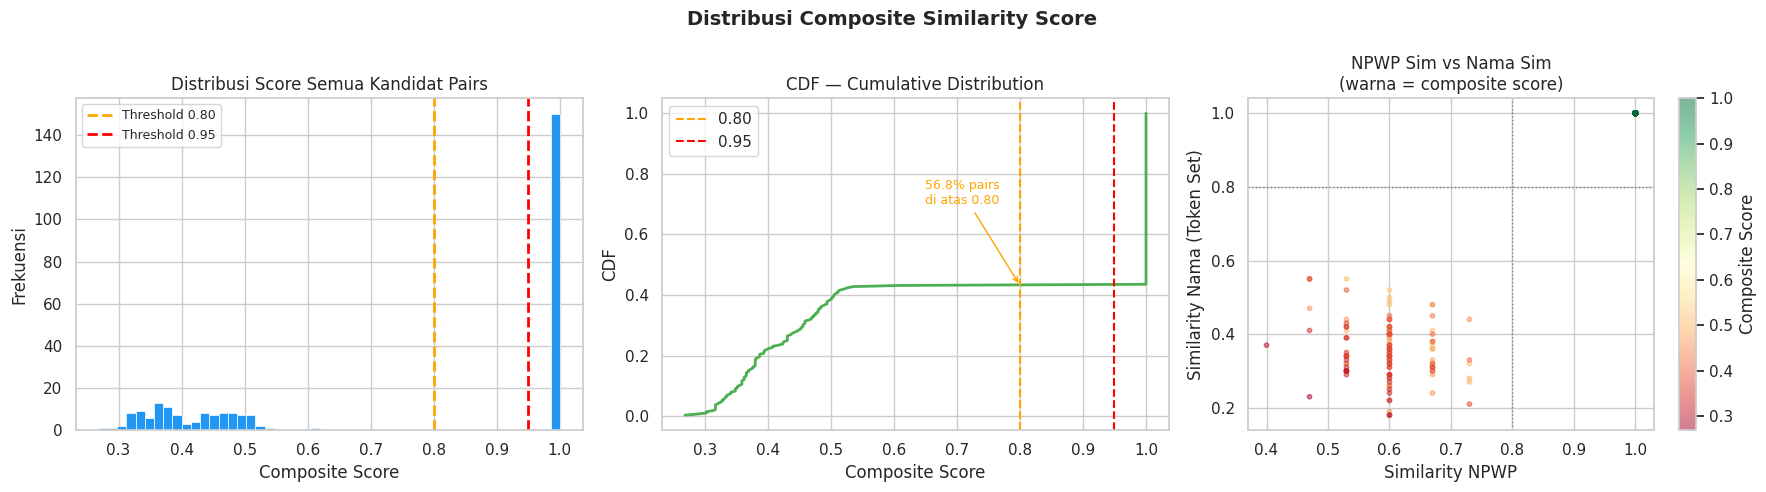

💾 Chart disimpan: chart_composite_score.png


In [51]:
# ============================================================
# CELL 11: VISUALISASI DISTRIBUSI COMPOSITE SCORE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Composite Similarity Score', fontsize=14, fontweight='bold')

# ── Chart 1: Histogram distribusi score ──
ax1 = axes[0]
ax1.hist(df_pairs['composite_score'], bins=50, color='#2196F3', edgecolor='white', linewidth=0.5)
ax1.axvline(x=0.80, color='orange', linestyle='--', linewidth=2, label='Threshold 0.80')
ax1.axvline(x=0.95, color='red',    linestyle='--', linewidth=2, label='Threshold 0.95')
ax1.set_xlabel('Composite Score')
ax1.set_ylabel('Frekuensi')
ax1.set_title('Distribusi Score Semua Kandidat Pairs')
ax1.legend(fontsize=9)

# ── Chart 2: CDF (Cumulative Distribution) ──
ax2 = axes[1]
scores_sorted = np.sort(df_pairs['composite_score'])
cdf = np.arange(1, len(scores_sorted)+1) / len(scores_sorted)
ax2.plot(scores_sorted, cdf, color='#4CAF50', linewidth=2)
ax2.axvline(x=0.80, color='orange', linestyle='--', linewidth=1.5, label='0.80')
ax2.axvline(x=0.95, color='red',    linestyle='--', linewidth=1.5, label='0.95')

# Annotasi berapa % pairs di atas threshold
pct_above_080 = (df_pairs['composite_score'] >= 0.80).mean() * 100
pct_above_095 = (df_pairs['composite_score'] >= 0.95).mean() * 100
ax2.annotate(f'{pct_above_080:.1f}% pairs\ndi atas 0.80',
    xy=(0.80, 1-pct_above_080/100), xytext=(0.65, 0.7),
    arrowprops=dict(arrowstyle='->', color='orange'), fontsize=9, color='orange')
ax2.set_xlabel('Composite Score'); ax2.set_ylabel('CDF')
ax2.set_title('CDF — Cumulative Distribution'); ax2.legend()

# ── Chart 3: Scatter sim_npwp vs sim_nama_set ──
ax3 = axes[2]
scatter = ax3.scatter(
    df_pairs['sim_npwp'], df_pairs['sim_nama_set'],
    c=df_pairs['composite_score'], cmap='RdYlGn',
    alpha=0.5, s=10
)
plt.colorbar(scatter, ax=ax3, label='Composite Score')
ax3.axvline(x=0.8, color='gray', linestyle=':', linewidth=1)
ax3.axhline(y=0.8, color='gray', linestyle=':', linewidth=1)
ax3.set_xlabel('Similarity NPWP')
ax3.set_ylabel('Similarity Nama (Token Set)')
ax3.set_title('NPWP Sim vs Nama Sim\n(warna = composite score)')

plt.tight_layout()
plt.savefig('chart_composite_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart disimpan: chart_composite_score.png')



In [52]:
# ============================================================
# CELL 12: THRESHOLD ANALYSIS
# Analisis dampak berbagai nilai threshold
# ============================================================

print('📊 ANALISIS DAMPAK THRESHOLD:')
print('='*65)
print(f'  {"Threshold":>10}  {"MATCH":>8}  {"REVIEW":>8}  {"NON-MATCH":>10}')
print('-'*65)

threshold_results = []
for upper in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    lower = upper - 0.15  # review zone = 15 poin di bawah upper
    n_match    = (df_pairs['composite_score'] >= upper).sum()
    n_review   = ((df_pairs['composite_score'] >= lower) &
                  (df_pairs['composite_score'] <  upper)).sum()
    n_nonmatch = (df_pairs['composite_score'] <  lower).sum()
    threshold_results.append({
        'Upper':upper, 'Lower':lower,
        'Match':n_match, 'Review':n_review, 'NonMatch':n_nonmatch
    })
    print(f'  upper={upper:.2f}/lower={lower:.2f}  {n_match:>8,}  {n_review:>8,}  {n_nonmatch:>10,}')

# ── Pilih threshold yang digunakan ──
UPPER_THRESHOLD = 0.90  # score >= 0.90 = MATCH (auto-merge)
LOWER_THRESHOLD = 0.75  # score  < 0.75 = NON-MATCH

# Klasifikasikan setiap pair
def classify_pair(score):
    if   score >= UPPER_THRESHOLD: return 'MATCH'
    elif score >= LOWER_THRESHOLD: return 'REVIEW'
    else:                          return 'NON-MATCH'

df_pairs['klasifikasi'] = df_pairs['composite_score'].apply(classify_pair)

klas_counts = df_pairs['klasifikasi'].value_counts()
print(f'\n✅ Threshold yang dipilih: UPPER={UPPER_THRESHOLD}, LOWER={LOWER_THRESHOLD}')
print(f'\n   Hasil klasifikasi:')
for klas, count in klas_counts.items():
    pct  = count/len(df_pairs)*100
    icon = {'MATCH':'🔴','REVIEW':'🟡','NON-MATCH':'🟢'}[klas]
    print(f'   {icon} {klas:<12}: {count:>6,} pairs ({pct:.1f}%)')



📊 ANALISIS DAMPAK THRESHOLD:
   Threshold     MATCH    REVIEW   NON-MATCH
-----------------------------------------------------------------
  upper=0.70/lower=0.55       150         1         113
  upper=0.75/lower=0.60       150         1         113
  upper=0.80/lower=0.65       150         0         114
  upper=0.85/lower=0.70       150         0         114
  upper=0.90/lower=0.75       150         0         114
  upper=0.95/lower=0.80       150         0         114

✅ Threshold yang dipilih: UPPER=0.9, LOWER=0.75

   Hasil klasifikasi:
   🔴 MATCH       :    150 pairs (56.8%)
   🟢 NON-MATCH   :    114 pairs (43.2%)


In [53]:
# ============================================================
# CELL 13: MANUAL SPOT-CHECK
# Review sample dari tiap zona untuk validasi threshold
# ============================================================

display_cols = ['id_1','id_2','nama_1','nama_2','npwp_1','npwp_2',
                'sim_npwp','sim_nama_set','composite_score','klasifikasi']

for zona in ['MATCH', 'REVIEW', 'NON-MATCH']:
    sample = df_pairs[df_pairs['klasifikasi'] == zona].head(4)
    n_total= (df_pairs['klasifikasi'] == zona).sum()
    icon   = {'MATCH':'🔴','REVIEW':'🟡','NON-MATCH':'🟢'}[zona]
    print(f'\n{icon} ZONA: {zona} ({n_total:,} pairs total)')
    print('='*60)
    for _, row in sample.iterrows():
        print(f'   Score : {row["composite_score"]:.4f}')
        print(f'   Nama 1: {row["nama_1"]}')
        print(f'   Nama 2: {row["nama_2"]}')
        print(f'   NPWP 1: {row["npwp_1"]}  |  NPWP 2: {row["npwp_2"]}')
        print(f'   sim_npwp={row["sim_npwp"]:.2f}  sim_nama={row["sim_nama_set"]:.2f}')
        print()

print('\n💡 INSTRUKSI MANUAL REVIEW:')
print('   1. Lihat zona MATCH — apakah semua memang duplikat? Jika ada false positive,')
print('      naikkan UPPER_THRESHOLD.')
print('   2. Lihat zona NON-MATCH — apakah ada yang seharusnya duplikat? Jika ada,')
print('      turunkan LOWER_THRESHOLD.')
print('   3. Zona REVIEW harus di-review manual oleh Data Steward.')




🔴 ZONA: MATCH (150 pairs total)
   Score : 1.0000
   Nama 1: Paramita Dongoran
   Nama 2: Paramita Dongoran
   NPWP 1: 03.447.821.2-078.354  |  NPWP 2: 03.447.821.2-078.354
   sim_npwp=1.00  sim_nama=1.00

   Score : 1.0000
   Nama 1: PT Perum Saputra Persero Tbk
   Nama 2: PT Perum Saputra Persero Tbk
   NPWP 1: 03.818.153.0-834.363  |  NPWP 2: 03.818.153.0-834.363
   sim_npwp=1.00  sim_nama=1.00

   Score : 1.0000
   Nama 1: Firma UD Tarihoran Tbk
   Nama 2: Firma UD Tarihoran Tbk
   NPWP 1: XX.249.611.5-846.504  |  NPWP 2: XX.249.611.5-846.504
   sim_npwp=1.00  sim_nama=1.00

   Score : 1.0000
   Nama 1: Balijan Winarsih
   Nama 2: Balijan Winarsih
   NPWP 1: 01.195.610.7-218.784  |  NPWP 2: 01.195.610.7-218.784
   sim_npwp=1.00  sim_nama=1.00


🟡 ZONA: REVIEW (0 pairs total)

🟢 ZONA: NON-MATCH (114 pairs total)
   Score : 0.6125
   Nama 1: R.M. Mariadi Putra, M.Kom.
   Nama 2: T. Galiono Manullang
   NPWP 1: 03.734.325.5-929.372  |  NPWP 2: 03.734.330.7-200.800
   sim_npwp=0.60  s

In [54]:
# ============================================================
# CELL 14: DUPLICATE CLUSTER MENGGUNAKAN GRAPH THEORY
# Node = record WP, Edge = hubungan duplikat (MATCH)
# Connected Component = satu cluster duplikat
# ============================================================

# Ambil pairs yang MATCH saja
df_match = df_pairs[df_pairs['klasifikasi'] == 'MATCH'].copy()

# Buat directed graph
G = nx.Graph()

# Tambahkan semua node (record WP)
G.add_nodes_from(df['id_record'].tolist())

# Tambahkan edge untuk setiap pasang MATCH
for _, row in df_match.iterrows():
    G.add_edge(row['id_1'], row['id_2'],
               weight=row['composite_score'],
               score=row['composite_score'])

# Temukan connected components (= cluster duplikat)
components  = list(nx.connected_components(G))
dup_clusters= [c for c in components if len(c) > 1]  # cluster dengan >1 node

print('📊 DUPLIKATE CLUSTER ANALYSIS:')
print(f'   Total node (record WP)     : {G.number_of_nodes():,}')
print(f'   Total edge (MATCH pairs)   : {G.number_of_edges():,}')
print(f'   Total cluster duplikat     : {len(dup_clusters):,}')
print(f'   Record terdampak (in cluster): {sum(len(c) for c in dup_clusters):,}')
print()

# Distribusi ukuran cluster
cluster_sizes = pd.Series([len(c) for c in dup_clusters])
print('   Distribusi ukuran cluster:')
for size, count in cluster_sizes.value_counts().sort_index().items():
    print(f'   Cluster ukuran {size}: {count} cluster ({count*size} record)')

# ── Tampilkan detail 5 cluster terbesar ──
print(f'\n📄 DETAIL 5 CLUSTER TERBESAR:')
sorted_clusters = sorted(dup_clusters, key=len, reverse=True)

for i, cluster in enumerate(sorted_clusters[:5], 1):
    print(f'\n   Cluster #{i} ({len(cluster)} record):')
    cluster_records = df[df['id_record'].isin(cluster)][
        ['id_record','npwp','nama_wp','jenis_wp','kode_kpp','status_wp']
    ]
    display(cluster_records)

# Simpan hasil cluster ke CSV
cluster_data = []
for cluster_id, cluster in enumerate(sorted_clusters, 1):
    for record_id in cluster:
        cluster_data.append({'cluster_id': cluster_id, 'id_record': record_id,
                             'cluster_size': len(cluster)})
df_clusters = pd.DataFrame(cluster_data)
df_clusters.to_csv('duplicate_clusters.csv', index=False)
print(f'\n💾 Cluster data disimpan: duplicate_clusters.csv')



📊 DUPLIKATE CLUSTER ANALYSIS:
   Total node (record WP)     : 5,150
   Total edge (MATCH pairs)   : 150
   Total cluster duplikat     : 150
   Record terdampak (in cluster): 300

   Distribusi ukuran cluster:
   Cluster ukuran 2: 150 cluster (300 record)

📄 DETAIL 5 CLUSTER TERBESAR:

   Cluster #1 (2 record):


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
2,WP001091,03.418.588.7-880.078,PT UD Prastuti Tampubolon Tbk,Badan,1211,Aktif
1200,WP001091_DUP,03.418.588.7-880.078,PT UD Prastuti Tampubolon Tbk,Badan,1211,Aktif



   Cluster #2 (2 record):


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
27,WP000764,06.327.647.3-308.316,Dipa Rahayu,Orang Pribadi,811,Aktif
4407,WP000764_DUP,06.327.647.3-308.316,Dipa Rahayu,Orang Pribadi,811,Aktif



   Cluster #3 (2 record):


...


   Cluster #4 (2 record):


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
53,WP000487,08.077.923.4-697.813,CV PT Mandasari Tbk,Badan,1011,Aktif
547,WP000487_DUP,08.077.923.4-697.813,CV PT Mandasari Tbk,Badan,1011,Aktif



   Cluster #5 (2 record):


,id_record,npwp,nama_wp,jenis_wp,kode_kpp,status_wp
63,WP000066,03.818.153.0-834.363,PT Perum Saputra Persero Tbk,Badan,1011,Aktif
194,WP000066_DUP,03.818.153.0-834.363,PT Perum Saputra Persero Tbk,Badan,1011,Aktif



💾 Cluster data disimpan: duplicate_clusters.csv


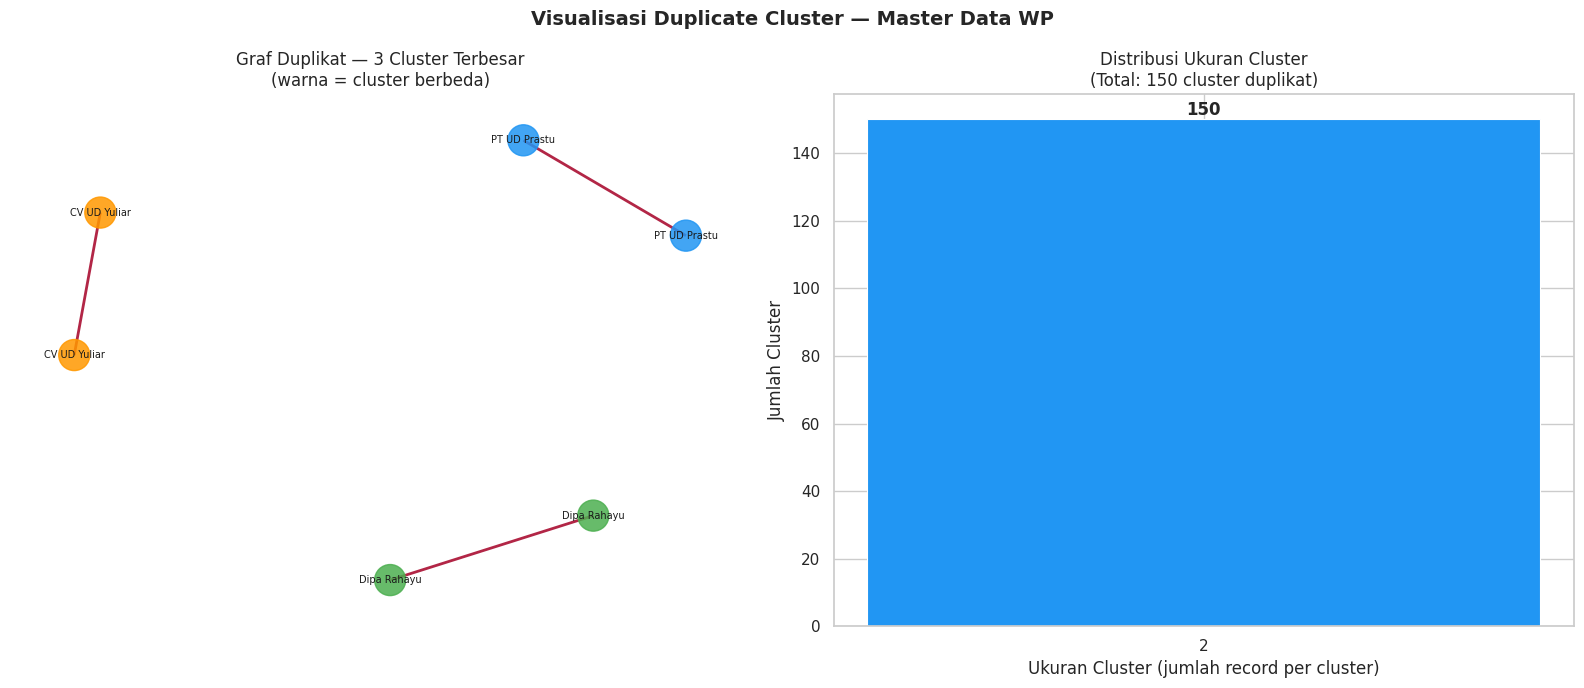

💾 Chart disimpan: chart_duplicate_cluster.png


In [55]:
# ============================================================
# CELL 15: VISUALISASI GRAF DUPLICATE CLUSTER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Visualisasi Duplicate Cluster — Master Data WP', fontsize=14, fontweight='bold')

# ── Chart 1: Visualisasi graf cluster terbesar ──
ax1 = axes[0]

# Pilih 3 cluster terbesar untuk divisualisasikan
top3_clusters = sorted_clusters[:3]
top3_nodes    = set().union(*top3_clusters)
G_sub         = G.subgraph(top3_nodes)

# Warna node berdasarkan cluster
color_map = {}
colors_palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
for ci, cluster in enumerate(top3_clusters):
    for node in cluster:
        color_map[node] = colors_palette[ci % len(colors_palette)]

node_colors = [color_map.get(n, '#CCCCCC') for n in G_sub.nodes()]
edge_weights= [G_sub[u][v]['score'] for u,v in G_sub.edges()]

pos = nx.spring_layout(G_sub, seed=42, k=1.5)
nx.draw_networkx(G_sub, pos=pos, ax=ax1,
    node_color=node_colors, node_size=500,
    edge_color=edge_weights, edge_cmap=plt.cm.RdYlGn,
    width=2, with_labels=False, alpha=0.85)

# Label node dengan nama pendek
labels = {n: df[df['id_record']==n]['nama_wp'].values[0][:12]
          if len(df[df['id_record']==n]) > 0 else n
          for n in G_sub.nodes()}
nx.draw_networkx_labels(G_sub, pos, labels, ax=ax1, font_size=7)

ax1.set_title('Graf Duplikat — 3 Cluster Terbesar\n(warna = cluster berbeda)')
ax1.axis('off')

# ── Chart 2: Bar Chart jumlah cluster per ukuran ──
ax2 = axes[1]
size_counts = cluster_sizes.value_counts().sort_index()
bars = ax2.bar(size_counts.index.astype(str), size_counts.values,
               color='#2196F3', edgecolor='white', linewidth=0.8)
ax2.set_xlabel('Ukuran Cluster (jumlah record per cluster)')
ax2.set_ylabel('Jumlah Cluster')
ax2.set_title(f'Distribusi Ukuran Cluster\n(Total: {len(dup_clusters)} cluster duplikat)')
for bar, val in zip(bars, size_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_duplicate_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart disimpan: chart_duplicate_cluster.png')



In [56]:
# ============================================================
# CELL 16: EXPORT LAPORAN AKHIR DUPLICATE DETECTION
# ============================================================

# ── 1. Export semua candidate pairs dengan score ──
df_pairs.to_csv('all_candidate_pairs.csv', index=False)
print(f'✅ all_candidate_pairs.csv    — {len(df_pairs):,} pairs dengan score')

# ── 2. Export MATCH pairs (untuk auto-merge) ──
df_match_export = df_pairs[df_pairs['klasifikasi']=='MATCH'][[
    'id_1','id_2','nama_1','nama_2','npwp_1','npwp_2',
    'sim_npwp','sim_nama_set','sim_kpp','composite_score','klasifikasi'
]]
df_match_export.to_csv('match_pairs_auto_merge.csv', index=False)
print(f'✅ match_pairs_auto_merge.csv  — {len(df_match_export):,} pairs (MATCH, siap auto-merge)')

# ── 3. Export REVIEW pairs (untuk manual review) ──
df_review_export = df_pairs[df_pairs['klasifikasi']=='REVIEW'][[
    'id_1','id_2','nama_1','nama_2','npwp_1','npwp_2',
    'sim_npwp','sim_nama_set','sim_kpp','composite_score','klasifikasi'
]]
df_review_export.to_csv('review_pairs_manual.csv', index=False)
print(f'✅ review_pairs_manual.csv     — {len(df_review_export):,} pairs (perlu review manual)')

# ── 4. Export cluster mapping ──
print(f'✅ duplicate_clusters.csv      — {len(df_clusters):,} records dalam {len(dup_clusters)} cluster')

# ── 5. Executive Summary ──
print(f'\n' + '='*65)
print(f'  EXECUTIVE SUMMARY — DUPLICATE DETECTION LAB 3')
print(f'  Dataset : Master Data Wajib Pajak (LAB 2 output)')
print(f'  Tanggal : {datetime.now().strftime("%Y-%m-%d")}')
print(f'='*65)
print(f'  Total record dianalisis  : {len(df):,}')
print(f'  Kandidat pairs dievaluasi : {len(df_pairs):,}')
print(f'  Threshold MATCH          : composite_score ≥ {UPPER_THRESHOLD}')
print(f'  Threshold REVIEW         : {LOWER_THRESHOLD} ≤ score < {UPPER_THRESHOLD}')
print(f'')
print(f'  HASIL KLASIFIKASI:')
for klas, count in df_pairs["klasifikasi"].value_counts().items():
    pct = count/len(df_pairs)*100
    print(f'    {klas:<12}: {count:>6,} pairs ({pct:.1f}%)')
print(f'')
print(f'  CLUSTER DUPLIKAT : {len(dup_clusters):,} cluster')
print(f'  Record terdampak : {sum(len(c) for c in dup_clusters):,} record')
print(f'  Rekomendasi: {len(df_match_export):,} pairs siap auto-merge,',
      f'{len(df_review_export):,} pairs perlu review manual')
print(f'='*65)
print(f'\n🏁 LAB 3 SELESAI! Output siap untuk LAB 4: Golden Record Simulation')



✅ all_candidate_pairs.csv    — 264 pairs dengan score
✅ match_pairs_auto_merge.csv  — 150 pairs (MATCH, siap auto-merge)
✅ review_pairs_manual.csv     — 0 pairs (perlu review manual)
✅ duplicate_clusters.csv      — 300 records dalam 150 cluster

  EXECUTIVE SUMMARY — DUPLICATE DETECTION LAB 3
  Dataset : Master Data Wajib Pajak (LAB 2 output)
  Tanggal : 2026-06-09
  Total record dianalisis  : 5,150
  Kandidat pairs dievaluasi : 264
  Threshold MATCH          : composite_score ≥ 0.9
  Threshold REVIEW         : 0.75 ≤ score < 0.9

  HASIL KLASIFIKASI:
    MATCH       :    150 pairs (56.8%)
    NON-MATCH   :    114 pairs (43.2%)

  CLUSTER DUPLIKAT : 150 cluster
  Record terdampak : 300 record
  Rekomendasi: 150 pairs siap auto-merge, 0 pairs perlu review manual

🏁 LAB 3 SELESAI! Output siap untuk LAB 4: Golden Record Simulation


**GOLDEN RECORD SIMULATION**

In [57]:
# ============================================================
# CELL 1: IMPORT LIBRARY & LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import re, warnings, json
from datetime import datetime
from faker import Faker
from collections import defaultdict
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
pd.set_option('display.max_colwidth', 40)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
fake = Faker('id_ID')
Faker.seed(RANDOM_SEED)

# ── Load dataset dari LAB 2 & LAB 3 ──
try:
    df_clean    = pd.read_csv('dataset_wp_clean.csv')
    df_clusters = pd.read_csv('duplicate_clusters.csv')
    print(f'✅ dataset_wp_clean.csv    : {df_clean.shape}')
    print(f'✅ duplicate_clusters.csv  : {df_clusters.shape}')
except FileNotFoundError as e:
    print(f'❌ File tidak ditemukan: {e}')
    print('   Pastikan LAB 2 dan LAB 3 sudah selesai dijalankan.')
    raise

# Ringkasan cluster
n_clusters = df_clusters['cluster_id'].nunique()
n_in_cluster = len(df_clusters)
print(f'\n   Total cluster duplikat : {n_clusters:,}')
print(f'   Record dalam cluster   : {n_in_cluster:,}')
print(f'   Record di luar cluster : {len(df_clean) - n_in_cluster:,} (sudah unik)')
print(f'\n   Contoh cluster mapping:')
display(df_clusters.head(8))



✅ dataset_wp_clean.csv    : (5150, 21)
✅ duplicate_clusters.csv  : (300, 3)

   Total cluster duplikat : 150
   Record dalam cluster   : 300
   Record di luar cluster : 4,850 (sudah unik)

   Contoh cluster mapping:


,cluster_id,id_record,cluster_size
0,1,WP001091,2
1,1,WP001091_DUP,2
2,2,WP000764,2
3,2,WP000764_DUP,2
4,3,WP003581_DUP,2
5,3,WP003581,2
6,4,WP000487_DUP,2
7,4,WP000487,2


In [58]:
# ============================================================
# CELL 2: SIMULASI DATASET SUMBER 1 — SIDJP
# ============================================================

import random
random.seed(RANDOM_SEED)

# Ambil sample 500 WP dari dataset bersih LAB 2 sebagai base
df_base = df_clean.sample(n=500, random_state=RANDOM_SEED).copy().reset_index(drop=True)

def make_sidjp_record(row):
    """
    Buat versi record SIDJP dari base record.
    SIDJP: data formal, casing sering UPPERCASE, update lambat.
    """
    rec = {
        'sumber'          : 'SIDJP',
        'id_sidjp'        : f'SIDJP{row["id_record"][2:]}',
        'npwp'            : row['npwp'],
        'nama_wp'         : row['nama_wp'].upper(),  # SIDJP pakai uppercase
        'jenis_wp'        : row['jenis_wp'],
        'status_wp'       : row['status_wp'],
        'status_pkp'      : row['status_pkp'],
        'kode_kpp'        : row['kode_kpp'],
        'nama_kpp'        : row['nama_kpp'],
        'kode_provinsi'   : row['kode_provinsi'],
        'nama_provinsi'   : row['nama_provinsi'],
        'alamat'          : row['alamat'].upper() if pd.notna(row['alamat']) else None,
        'kota'            : row['kota'],
        'kode_pos'        : row['kode_pos'],
        'klu_kode'        : row['klu_kode'],
        'klu_nama'        : row['klu_nama'],
        # SIDJP: email sering kosong (tidak dikumpulkan)
        'email'           : None if random.random() < 0.4 else row['email'],
        # SIDJP: telepon ada tapi mungkin lama
        'telepon'         : row['telepon'],
        'penghasilan'     : row['penghasilan'],
        'tanggal_daftar'  : row['tanggal_daftar'],
        'tanggal_update'  : '2022-01-01',  # SIDJP: update terakhir 2022
        'nik'             : row['nik'],
        'skor_kelengkapan': random.uniform(0.65, 0.90),
    }
    return rec

sidjp_records = [make_sidjp_record(row) for _, row in df_base.iterrows()]
df_sidjp = pd.DataFrame(sidjp_records)

print(f'✅ Dataset SIDJP berhasil dibuat: {df_sidjp.shape}')
print(f'   Kolom: {list(df_sidjp.columns)}')
print(f'\nContoh 3 record SIDJP:')
display(df_sidjp[['id_sidjp','npwp','nama_wp','email','telepon','tanggal_update']].head(3))



✅ Dataset SIDJP berhasil dibuat: (500, 23)
   Kolom: ['sumber', 'id_sidjp', 'npwp', 'nama_wp', 'jenis_wp', 'status_wp', 'status_pkp', 'kode_kpp', 'nama_kpp', 'kode_provinsi', 'nama_provinsi', 'alamat', 'kota', 'kode_pos', 'klu_kode', 'klu_nama', 'email', 'telepon', 'penghasilan', 'tanggal_daftar', 'tanggal_update', 'nik', 'skor_kelengkapan']

Contoh 3 record SIDJP:


,id_sidjp,npwp,nama_wp,email,telepon,tanggal_update
0,SIDJP002816,09.999.596.6-303.223,FIRMA PD HARIYAH HUTASOIT PERSERO TBK,halimaheli@example.net,NaN,2022-01-01
1,SIDJP004071,00.727.716.6-889.004,KOPERASI PT SIHOMBING TBK,None,NaN,2022-01-01
2,SIDJP004480,04.512.494.4-218.479,KOPERASI UD PUTRA RAMADAN TBK,budimanirsad@example.org,NaN,2022-01-01


In [59]:
# ============================================================
# CELL 3: SIMULASI DATASET SUMBER 2 — e-FILING
# ============================================================

def make_efiling_record(row):
    """
    Buat versi record e-Filing dari base record.
    e-Filing: self-reported, lebih up-to-date, format tidak konsisten.
    """
    # Simulasi variasi nama di e-Filing (Title Case tapi kadang typo kecil)
    nama = row['nama_wp']
    if random.random() < 0.15:
        # Typo kecil: tambah/kurang huruf atau spasi
        chars = list(nama)
        pos   = random.randint(0, max(0, len(chars)-2))
        if random.random() < 0.5 and len(chars) > 3:
            chars.pop(pos)   # hapus satu karakter
        else:
            chars.insert(pos, ' ')  # tambah spasi
        nama = ''.join(chars).strip()

    # e-Filing: alamat sering diisi manual oleh WP — format berbeda
    alamat = row['alamat']
    if pd.notna(alamat) and random.random() < 0.3:
        alamat = alamat.lower()  # WP kadang isi lowercase

    rec = {
        'sumber'          : 'EFILING',
        'id_efiling'      : f'EF{row["id_record"][2:]}',
        'npwp'            : row['npwp'],
        'nama_wp'         : nama,  # Title Case dengan kemungkinan typo
        'jenis_wp'        : row['jenis_wp'],
        'status_wp'       : row['status_wp'],
        'status_pkp'      : row['status_pkp'],
        'kode_kpp'        : row['kode_kpp'],
        'nama_kpp'        : row['nama_kpp'],
        'kode_provinsi'   : row['kode_provinsi'],
        'nama_provinsi'   : row['nama_provinsi'],
        'alamat'          : alamat,
        'kota'            : row['kota'],
        'kode_pos'        : row['kode_pos'],
        'klu_kode'        : row['klu_kode'],
        'klu_nama'        : row['klu_nama'],
        # e-Filing: email lebih lengkap (WP isi sendiri)
        'email'           : row['email'] if pd.notna(row['email']) else fake.email(),
        # e-Filing: telepon lebih baru
        'telepon'         : fake.phone_number() if random.random() < 0.3 else row['telepon'],
        'penghasilan'     : row['penghasilan'] * random.uniform(0.95, 1.05),  # sedikit beda
        'tanggal_daftar'  : row['tanggal_daftar'],
        'tanggal_update'  : '2024-06-15',  # e-Filing: lebih baru (2024)
        'nik'             : row['nik'],
        'skor_kelengkapan': random.uniform(0.70, 0.95),
    }
    return rec

efiling_records = [make_efiling_record(row) for _, row in df_base.iterrows()]
df_efiling = pd.DataFrame(efiling_records)

print(f'✅ Dataset e-Filing berhasil dibuat: {df_efiling.shape}')
print(f'\nContoh 3 record e-Filing:')
display(df_efiling[['id_efiling','npwp','nama_wp','email','telepon','tanggal_update']].head(3))

# ── Tampilkan perbandingan side-by-side ──
print(f'\n📊 PERBANDINGAN DATA SIDJP vs e-FILING (sample 3 WP):')
for i in range(3):
    s = df_sidjp.iloc[i]
    e = df_efiling.iloc[i]
    print(f'\n  WP #{i+1} — NPWP: {s["npwp"]}')
    print(f'    Nama SIDJP  : {s["nama_wp"]}')
    print(f'    Nama eFiling: {e["nama_wp"]}')
    print(f'    Email SIDJP : {s["email"]}')
    print(f'    Email eFiling: {e["email"]}')
    print(f'    Update SIDJP : {s["tanggal_update"]}  |  Update eFiling: {e["tanggal_update"]}')



✅ Dataset e-Filing berhasil dibuat: (500, 23)

Contoh 3 record e-Filing:


,id_efiling,npwp,nama_wp,email,telepon,tanggal_update
0,EF002816,09.999.596.6-303.223,Firma PD Hariyah Hutaso it Persero Tbk,halimaheli@example.net,NaN,2024-06-15
1,EF004071,00.727.716.6-889.004,Koperasi PT Siombing Tbk,kawacakuswandari@example.org,NaN,2024-06-15
2,EF004480,04.512.494.4-218.479,Koperasi UD Putra Ramadan Tbk,budimanirsad@example.org,NaN,2024-06-15



📊 PERBANDINGAN DATA SIDJP vs e-FILING (sample 3 WP):

  WP #1 — NPWP: 09.999.596.6-303.223
    Nama SIDJP  : FIRMA PD HARIYAH HUTASOIT PERSERO TBK
    Nama eFiling: Firma PD Hariyah Hutaso it Persero Tbk
    Email SIDJP : halimaheli@example.net
    Email eFiling: halimaheli@example.net
    Update SIDJP : 2022-01-01  |  Update eFiling: 2024-06-15

  WP #2 — NPWP: 00.727.716.6-889.004
    Nama SIDJP  : KOPERASI PT SIHOMBING TBK
    Nama eFiling: Koperasi PT Siombing Tbk
    Email SIDJP : None
    Email eFiling: kawacakuswandari@example.org
    Update SIDJP : 2022-01-01  |  Update eFiling: 2024-06-15

  WP #3 — NPWP: 04.512.494.4-218.479
    Nama SIDJP  : KOPERASI UD PUTRA RAMADAN TBK
    Nama eFiling: Koperasi UD Putra Ramadan Tbk
    Email SIDJP : budimanirsad@example.org
    Email eFiling: budimanirsad@example.org
    Update SIDJP : 2022-01-01  |  Update eFiling: 2024-06-15


In [60]:
# ============================================================
# CELL 4: DEFINISI SURVIVORSHIP RULES
# Setiap field memiliki aturan berbeda berdasarkan logika bisnis
# ============================================================

# Prioritas sumber: sumber mana yang lebih dipercaya per field
SOURCE_PRIORITY = {
    'SIDJP'  : 1,   # prioritas tertinggi untuk data formal
    'EFILING': 2,   # prioritas untuk data kontak & penghasilan
}

def rule_most_recent(values_with_source: list) -> tuple:
    """
    Ambil nilai dari sumber yang paling baru diupdate.
    values_with_source: list of (value, source, update_date)
    Returns: (winning_value, winning_source)
    """
    valid = [(v, s, d) for v, s, d in values_with_source if pd.notna(v) and v != '']
    if not valid: return (None, 'N/A')
    # Sort by update_date descending (terbaru menang)
    valid.sort(key=lambda x: str(x[2]), reverse=True)
    return (valid[0][0], valid[0][1])


def rule_most_complete(values_with_source: list) -> tuple:
    """
    Ambil nilai yang paling tidak null dan paling panjang.
    Prioritas: tidak null > terpanjang > sumber terpercaya.
    """
    valid = [(v, s) for v, s, *_ in values_with_source if pd.notna(v) and str(v).strip() != '']
    if not valid: return (None, 'N/A')
    # Ambil yang terpanjang
    valid.sort(key=lambda x: len(str(x[0])), reverse=True)
    return (valid[0][0], valid[0][1])


def rule_trusted_source(values_with_source: list, priority: dict) -> tuple:
    """
    Ambil nilai dari sumber paling tepercaya (priority terendah angkanya).
    Jika sumber prioritas nilainya null, turun ke sumber berikutnya.
    """
    valid = [(v, s) for v, s, *_ in values_with_source if pd.notna(v) and str(v).strip() != '']
    if not valid: return (None, 'N/A')
    # Sort by priority (1=tertinggi, 2=kedua, dst.)
    valid.sort(key=lambda x: priority.get(x[1], 99))
    return (valid[0][0], valid[0][1])


def rule_highest_score(values_with_source: list) -> tuple:
    """
    Ambil nilai dari sumber dengan skor kelengkapan tertinggi.
    """
    # values_with_source: list of (value, source, score)
    valid = [(v, s, sc) for v, s, *rest in values_with_source
             if pd.notna(v) and str(v).strip() != ''
             for sc in (rest[0] if rest else [0.5],)]
    if not valid: return (None, 'N/A')
    valid.sort(key=lambda x: x[2], reverse=True)
    return (valid[0][0], valid[0][1])


# ── Mapping field → survivorship rule yang digunakan ──
FIELD_RULES = {
    # Field identitas formal → prioritaskan SIDJP
    'npwp'          : ('trusted_source', SOURCE_PRIORITY),
    'nama_wp'       : ('trusted_source', SOURCE_PRIORITY),
    'jenis_wp'      : ('trusted_source', SOURCE_PRIORITY),
    'status_wp'     : ('most_recent',    None),
    'status_pkp'    : ('most_recent',    None),
    # Field referensi → sumber tepercaya
    'kode_kpp'      : ('trusted_source', SOURCE_PRIORITY),
    'nama_kpp'      : ('trusted_source', SOURCE_PRIORITY),
    'kode_provinsi' : ('trusted_source', SOURCE_PRIORITY),
    'nama_provinsi' : ('trusted_source', SOURCE_PRIORITY),
    # Field kontak → paling baru
    'email'         : ('most_recent',    None),
    'telepon'       : ('most_recent',    None),
    # Field alamat → paling lengkap
    'alamat'        : ('most_complete',  None),
    'kota'          : ('most_complete',  None),
    'kode_pos'      : ('most_complete',  None),
    # Field KLU → sumber tepercaya
    'klu_kode'      : ('trusted_source', SOURCE_PRIORITY),
    'klu_nama'      : ('trusted_source', SOURCE_PRIORITY),
    # Field finansial → paling baru (e-Filing lebih update)
    'penghasilan'   : ('most_recent',    None),
    # Field tanggal
    'tanggal_daftar': ('trusted_source', SOURCE_PRIORITY),
    # Field identitas pribadi
    'nik'           : ('most_complete',  None),
}

print('✅ Survivorship Rules berhasil didefinisikan!')
print(f'   Total field dengan rule: {len(FIELD_RULES)}')
print(f'\n   Ringkasan rule per field:')
rule_summary = pd.DataFrame([
    {'Field': f, 'Rule': r[0], 'Parameter': str(r[1])[:30] if r[1] else '-'}
    for f, r in FIELD_RULES.items()
])
display(rule_summary)



✅ Survivorship Rules berhasil didefinisikan!
   Total field dengan rule: 19

   Ringkasan rule per field:


,Field,Rule,Parameter
0,npwp,trusted_source,"{'SIDJP': 1, 'EFILING': 2}"
1,nama_wp,trusted_source,"{'SIDJP': 1, 'EFILING': 2}"
2,jenis_wp,trusted_source,"{'SIDJP': 1, 'EFILING': 2}"
3,status_wp,most_recent,-
4,status_pkp,most_recent,-
5,kode_kpp,trusted_source,"{'SIDJP': 1, 'EFILING': 2}"
6,nama_kpp,trusted_source,"{'SIDJP': 1, 'EFILING': 2}"
7,kode_provinsi,trusted_source,"{'SIDJP': 1, 'EFILING': 2}"
8,nama_provinsi,trusted_source,"{'SIDJP': 1, 'EFILING': 2}"
9,email,most_recent,-


In [61]:
# ============================================================
# CELL 5: COMBINE DATA DARI DUA SUMBER
# Satukan SIDJP dan e-Filing ke dalam satu dataframe
# ============================================================

# Standardisasi kolom agar bisa digabung
COMMON_FIELDS = [
    'npwp','nama_wp','jenis_wp','status_wp','status_pkp',
    'kode_kpp','nama_kpp','kode_provinsi','nama_provinsi',
    'alamat','kota','kode_pos','klu_kode','klu_nama',
    'email','telepon','penghasilan','tanggal_daftar','nik',
    'sumber','tanggal_update','skor_kelengkapan'
]

# Tambah kolom yang mungkin tidak ada
for df_, name in [(df_sidjp, 'SIDJP'), (df_efiling, 'EFILING')]:
    for col in COMMON_FIELDS:
        if col not in df_.columns:
            df_[col] = None

df_sidjp_std   = df_sidjp[COMMON_FIELDS].copy()
df_efiling_std = df_efiling[COMMON_FIELDS].copy()

# Gabungkan dua sumber
df_combined = pd.concat([df_sidjp_std, df_efiling_std], ignore_index=True)
df_combined['tanggal_update'] = pd.to_datetime(df_combined['tanggal_update'])

print(f'✅ Combined dataset: {df_combined.shape}')
print(f'   Dari SIDJP  : {len(df_sidjp_std):,} record')
print(f'   Dari eFiling: {len(df_efiling_std):,} record')
print(f'   Total gabungan: {len(df_combined):,} record')
print(f'\n   Distribusi sumber:')
print(df_combined['sumber'].value_counts())

# Kelompokkan per NPWP (key untuk merge)
grouped = df_combined.groupby('npwp')
print(f'\n   NPWP unik dalam combined dataset: {len(grouped):,}')
print(f'   NPWP dengan data dari dua sumber: {(grouped.size() > 1).sum():,}')




✅ Combined dataset: (1000, 22)
   Dari SIDJP  : 500 record
   Dari eFiling: 500 record
   Total gabungan: 1,000 record

   Distribusi sumber:
sumber
SIDJP      500
EFILING    500
Name: count, dtype: int64

   NPWP unik dalam combined dataset: 500
   NPWP dengan data dari dua sumber: 500


In [62]:
# ============================================================
# CELL 6: FUNGSI GOLDEN RECORD MERGER
# Inti dari pipeline MDM — menggabungkan n record → 1 golden record
# ============================================================

def create_golden_record(records_df: pd.DataFrame,
                          field_rules: dict,
                          source_priority: dict) -> dict:
    """
    Buat satu Golden Record dari sekelompok record duplikat.

    Parameter:
        records_df    : DataFrame berisi semua record yang akan dimerge
        field_rules   : dict mapping field → (rule_type, parameter)
        source_priority: dict mapping source_name → priority_int

    Returns:
        dict berisi golden record + provenance information
    """
    golden = {}
    provenance = {}  # catat dari mana setiap nilai berasal
    conflicts  = {}  # catat konflik yang terjadi

    for field, (rule_type, param) in field_rules.items():
        if field not in records_df.columns:
            golden[field]     = None
            provenance[field] = 'N/A (kolom tidak ada)'
            continue

        # Kumpulkan semua nilai untuk field ini dari semua sumber
        values_with_meta = []
        for _, row in records_df.iterrows():
            values_with_meta.append((
                row[field],
                row.get('sumber', 'UNKNOWN'),
                row.get('tanggal_update', pd.Timestamp('2000-01-01')),
                row.get('skor_kelengkapan', 0.5)
            ))

        # Deteksi konflik: apakah ada nilai yang berbeda?
        unique_vals = set(
            str(v[0]).strip().upper() for v in values_with_meta
            if pd.notna(v[0]) and str(v[0]).strip() != ''
        )
        has_conflict = len(unique_vals) > 1

        # Terapkan survivorship rule
        if rule_type == 'most_recent':
            winning_val, winning_src = rule_most_recent(
                [(v[0], v[1], v[2]) for v in values_with_meta]
            )
        elif rule_type == 'most_complete':
            winning_val, winning_src = rule_most_complete(
                [(v[0], v[1]) for v in values_with_meta]
            )
        elif rule_type == 'trusted_source':
            winning_val, winning_src = rule_trusted_source(
                [(v[0], v[1]) for v in values_with_meta], param
            )
        elif rule_type == 'highest_score':
            winning_val, winning_src = rule_highest_score(
                [(v[0], v[1], v[3]) for v in values_with_meta]
            )
        else:
            winning_val, winning_src = (None, 'UNKNOWN')

        golden[field]     = winning_val
        provenance[field] = winning_src
        if has_conflict:
            conflicts[field] = {
                'values'  : list(unique_vals),
                'winner'  : winning_src,
                'rule'    : rule_type
            }

    return {
        'golden_record': golden,
        'provenance'   : provenance,
        'conflicts'    : conflicts,
        'source_count' : len(records_df),
        'sources_used' : records_df['sumber'].unique().tolist()
    }


# ── Test pada 1 NPWP untuk verifikasi ──
test_npwp   = df_combined['npwp'].value_counts().index[0]
test_records= df_combined[df_combined['npwp'] == test_npwp]

print(f'🔬 TEST GOLDEN RECORD MERGER:')
print(f'   NPWP test  : {test_npwp}')
print(f'   Sumber data: {test_records["sumber"].tolist()}')
print(f'   Jumlah record: {len(test_records)}')

result = create_golden_record(test_records, FIELD_RULES, SOURCE_PRIORITY)

print(f'\n   GOLDEN RECORD yang dihasilkan:')
for field, val in result['golden_record'].items():
    src = result['provenance'][field]
    conf= '⚠ KONFLIK' if field in result['conflicts'] else ''
    print(f'   {field:<20}: {str(val)[:35]:<35} [dari: {src}] {conf}')

print(f'\n   Konflik yang diselesaikan: {len(result["conflicts"])} field')
for field, c in result['conflicts'].items():
    print(f'   ⚠ {field}: {c["values"]} → pemenang [{c["winner"]}] via rule [{c["rule"]}]')



🔬 TEST GOLDEN RECORD MERGER:
   NPWP test  : XX.150.909.5-657.162
   Sumber data: ['SIDJP', 'EFILING']
   Jumlah record: 2

   GOLDEN RECORD yang dihasilkan:
   npwp                : XX.150.909.5-657.162                [dari: SIDJP] 
   nama_wp             : UD CV KUSUMO HUTAGALUNG             [dari: SIDJP] 
   jenis_wp            : Badan                               [dari: SIDJP] 
   status_wp           : Non-Aktif                           [dari: EFILING] 
   status_pkp          : PKP                                 [dari: EFILING] 
   kode_kpp            : 621                                 [dari: SIDJP] 
   nama_kpp            : KPP Pratama Jakarta Selatan Satu    [dari: SIDJP] 
   kode_provinsi       : 31                                  [dari: SIDJP] 
   nama_provinsi       : DKI Jakarta                         [dari: SIDJP] 
   email               : wp.001868@noemail.djp.go.id         [dari: EFILING] 
   telepon             : None                                [dari: N/A] 
  

In [63]:
# ============================================================
# CELL 7: BATCH GOLDEN RECORD GENERATION
# Proses semua NPWP → golden record secara batch
# ============================================================

import time
print('🔄 Memulai batch golden record generation...')
print(f'   Total NPWP unik: {df_combined["npwp"].nunique():,}')
print(f'   Estimasi waktu: 10-30 detik...')
print()

start_time   = time.time()
golden_records = []
provenance_log = []
conflict_log   = []

# Proses per NPWP
for npwp, group in df_combined.groupby('npwp'):
    result = create_golden_record(group, FIELD_RULES, SOURCE_PRIORITY)

    # Buat satu baris golden record
    gr = result['golden_record'].copy()
    gr['gr_id']         = f'GR_{re.sub(r"[^0-9]", "", str(npwp))}'  # ID unik golden record
    gr['gr_npwp']       = npwp
    gr['source_count']  = result['source_count']
    gr['sources_used']  = ','.join(result['sources_used'])
    gr['n_conflicts']   = len(result['conflicts'])
    gr['created_at']    = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    gr['gr_version']    = 'v1.0'
    golden_records.append(gr)

    # Log provenance
    for field, src in result['provenance'].items():
        provenance_log.append({
            'npwp': npwp, 'field': field, 'source': src
        })

    # Log konflik
    for field, c in result['conflicts'].items():
        conflict_log.append({
            'npwp'   : npwp,
            'field'  : field,
            'values' : str(c['values']),
            'winner' : c['winner'],
            'rule'   : c['rule']
        })

# Buat dataframe golden records
df_golden     = pd.DataFrame(golden_records)
df_provenance = pd.DataFrame(provenance_log)
df_conflicts  = pd.DataFrame(conflict_log) if conflict_log else pd.DataFrame()

elapsed = time.time() - start_time
print(f'✅ Batch golden record generation selesai!')
print(f'   Waktu eksekusi     : {elapsed:.1f} detik')
print(f'   Total golden record: {len(df_golden):,}')
print(f'   Total konflik      : {len(df_conflicts):,} field-konflik')
print(f'   Record dengan konflik: {df_golden["n_conflicts"].gt(0).sum():,} dari {len(df_golden):,}')
print(f'\n   Preview 3 golden record:')
display(df_golden[['gr_id','gr_npwp','nama_wp','status_wp','email',
                    'source_count','sources_used','n_conflicts']].head(3))



🔄 Memulai batch golden record generation...
   Total NPWP unik: 500
   Estimasi waktu: 10-30 detik...

✅ Batch golden record generation selesai!
   Waktu eksekusi     : 7.6 detik
   Total golden record: 500
   Total konflik      : 602 field-konflik
   Record dengan konflik: 500 dari 500

   Preview 3 golden record:


,gr_id,gr_npwp,nama_wp,status_wp,email,source_count,sources_used,n_conflicts
0,GR_000082607793058,00.008.260.7-793.058,YUNITA UYAINAH,Aktif,shakilasuwarno@example.net,2,"SIDJP,EFILING",1
1,GR_000114829327794,00.011.482.9-327.794,RATNA SITUMORANG,Aktif,gadangnovitasari@example.net,2,"SIDJP,EFILING",1
2,GR_000452768268014,00.045.276.8-268.014,CV UD NUGROHO MANSUR,Non-Aktif,msiregar@example.org,2,"SIDJP,EFILING",1


📊 ANALISIS KONFLIK DATA:

   Total konflik       : 602
   Field berkonflik    : 3
   WP dengan konflik   : 500

   TOP 10 field paling sering konflik:


,Field,Jumlah Konflik,Persen WP
0,penghasilan,500,100.00
1,nama_wp,82,16.40
2,telepon,20,4.00



   Distribusi jumlah konflik per WP:
   1 konflik:   402 WP  ████████████████████
   2 konflik:    94 WP  ████
   3 konflik:     4 WP  


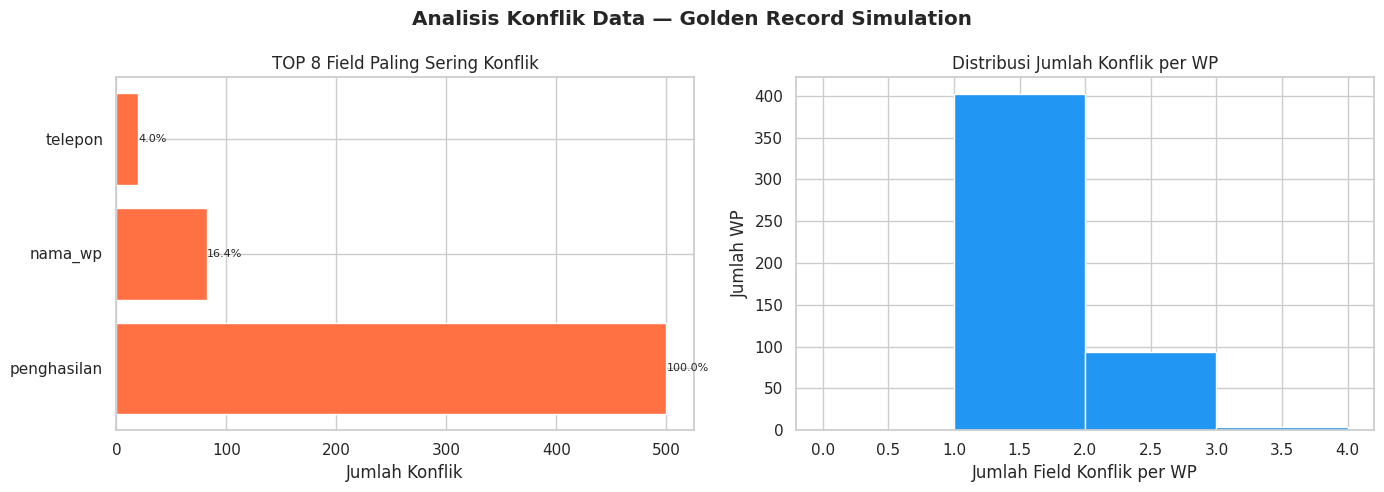

💾 Chart disimpan: chart_conflicts.png


In [64]:
# ============================================================
# CELL 8: ANALISIS POLA KONFLIK
# ============================================================

if len(df_conflicts) == 0:
    print('ℹ Tidak ada konflik yang terdeteksi dalam dataset ini.')
else:
    print('📊 ANALISIS KONFLIK DATA:')
    print('='*60)

    # Frekuensi konflik per field
    conf_by_field = df_conflicts['field'].value_counts().reset_index()
    conf_by_field.columns = ['Field', 'Jumlah Konflik']
    conf_by_field['Persen WP'] = (conf_by_field['Jumlah Konflik'] / len(df_golden) * 100).round(2)

    print(f'\n   Total konflik       : {len(df_conflicts):,}')
    print(f'   Field berkonflik    : {df_conflicts["field"].nunique()}')
    print(f'   WP dengan konflik   : {df_conflicts["npwp"].nunique():,}')
    print(f'\n   TOP 10 field paling sering konflik:')
    display(conf_by_field.head(10))

    # Distribusi jumlah konflik per WP
    conf_per_wp = df_golden['n_conflicts'].value_counts().sort_index()
    print(f'\n   Distribusi jumlah konflik per WP:')
    for n_conf, count in conf_per_wp.items():
        bar = '█' * int(count / max(conf_per_wp) * 20)
        print(f'   {n_conf} konflik: {count:>5,} WP  {bar}')

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Analisis Konflik Data — Golden Record Simulation', fontweight='bold')

    # Chart 1: Bar konflik per field
    ax1 = axes[0]
    top_fields = conf_by_field.head(8)
    ax1.barh(top_fields['Field'], top_fields['Jumlah Konflik'],
             color='#FF7043', edgecolor='white')
    ax1.set_xlabel('Jumlah Konflik')
    ax1.set_title('TOP 8 Field Paling Sering Konflik')
    for i, (_, row) in enumerate(top_fields.iterrows()):
        ax1.text(row['Jumlah Konflik']+0.1, i, f'{row["Persen WP"]:.1f}%',
                 va='center', fontsize=8)

    # Chart 2: Histogram konflik per WP
    ax2 = axes[1]
    df_golden['n_conflicts'].plot(kind='hist', bins=range(0,
        int(df_golden['n_conflicts'].max())+2), ax=ax2,
        color='#2196F3', edgecolor='white')
    ax2.set_xlabel('Jumlah Field Konflik per WP')
    ax2.set_ylabel('Jumlah WP')
    ax2.set_title('Distribusi Jumlah Konflik per WP')

    plt.tight_layout()
    plt.savefig('chart_conflicts.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Chart disimpan: chart_conflicts.png')



In [65]:
# ============================================================
# CELL 9: WORKFLOW RESOLUSI KONFLIK MANUAL
# Simulasi proses Data Steward mereview dan memutuskan nilai
# ============================================================

class ConflictResolver:
    """
    Workflow manajemen konflik data untuk Data Steward.
    Dalam implementasi nyata ini akan menjadi UI/form web.
    """
    def __init__(self, conflicts_df: pd.DataFrame, golden_df: pd.DataFrame):
        self.conflicts_df = conflicts_df
        self.golden_df    = golden_df.set_index('gr_npwp')
        self.resolutions  = []

    def get_pending_conflicts(self, field_filter=None, limit=10):
        """Ambil daftar konflik yang belum diselesaikan."""
        pending = self.conflicts_df.copy()
        if field_filter:
            pending = pending[pending['field'] == field_filter]
        return pending.head(limit)

    def resolve(self, npwp: str, field: str,
                chosen_value, reason: str, steward: str):
        """
        Data Steward memutuskan nilai untuk konflik tertentu.
        Mencatat resolusi ke dalam log.
        """
        # Update golden record
        if npwp in self.golden_df.index:
            self.golden_df.at[npwp, field] = chosen_value

        # Catat resolusi
        self.resolutions.append({
            'timestamp' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'npwp'      : npwp,
            'field'     : field,
            'chosen_val': chosen_value,
            'reason'    : reason,
            'steward'   : steward,
        })
        print(f'✅ Konflik diselesaikan: [{field}] untuk NPWP {npwp}')
        print(f'   Nilai dipilih: {chosen_value}')
        print(f'   Alasan: {reason}')

    def resolution_report(self):
        """Tampilkan semua resolusi yang telah dilakukan."""
        if not self.resolutions:
            print('Belum ada konflik yang diselesaikan.')
            return pd.DataFrame()
        return pd.DataFrame(self.resolutions)


# Inisialisasi resolver
if len(df_conflicts) > 0:
    resolver = ConflictResolver(df_conflicts, df_golden.copy())

    # Tampilkan konflik yang perlu diselesaikan
    print('📋 KONFLIK YANG PERLU DIREVIEW DATA STEWARD:')
    pending = resolver.get_pending_conflicts(limit=5)
    for _, row in pending.iterrows():
        npwp_short = str(row['npwp'])[:15]
        gr = df_golden[df_golden['gr_npwp']==row['npwp']]
        nama = gr['nama_wp'].values[0] if len(gr)>0 else '-'
        print(f'\n  WP: {nama[:30]} | NPWP: {npwp_short}')
        print(f'  Field  : {row["field"]}')
        print(f'  Nilai  : {row["values"]}')
        print(f'  Pemenang auto: [{row["winner"]}] via rule [{row["rule"]}]')

    # Simulasi resolusi manual oleh Data Steward
    print(f'\n   [SIMULASI] Data Steward menyelesaikan konflik secara manual...')
    if len(pending) > 0:
        first = pending.iloc[0]
        sample_val = first['values'].strip("[]\'\" ").split(',')[0].strip("'\"").strip()
        resolver.resolve(
            npwp    = first['npwp'],
            field   = first['field'],
            chosen_value = sample_val,
            reason  = 'Verifikasi dokumen fisik WP — nilai SIDJP lebih akurat',
            steward = 'Data.Steward.01@djp.go.id'
        )

    print(f'\n   Laporan resolusi:')
    display(resolver.resolution_report())
else:
    print('ℹ Tidak ada konflik yang memerlukan resolusi manual.')



📋 KONFLIK YANG PERLU DIREVIEW DATA STEWARD:

  WP: YUNITA UYAINAH | NPWP: 00.008.260.7-79
  Field  : penghasilan
  Nilai  : ['3012953930.0', '3132906909.2029824']
  Pemenang auto: [EFILING] via rule [most_recent]

  WP: RATNA SITUMORANG | NPWP: 00.011.482.9-32
  Field  : penghasilan
  Nilai  : ['4167062898.0', '4009495459.5225725']
  Pemenang auto: [EFILING] via rule [most_recent]

  WP: CV UD NUGROHO MANSUR | NPWP: 00.045.276.8-26
  Field  : penghasilan
  Nilai  : ['396968147.0', '408050080.27319735']
  Pemenang auto: [EFILING] via rule [most_recent]

  WP: UMAY PURNAWATI | NPWP: 00.065.355.4-44
  Field  : penghasilan
  Nilai  : ['2708029439.0', '2774594109.6314435']
  Pemenang auto: [EFILING] via rule [most_recent]

  WP: HJ. SHAKILA NAPITUPULU | NPWP: 00.072.011.0-64
  Field  : penghasilan
  Nilai  : ['3277798591.2890573', '3365523977.0']
  Pemenang auto: [EFILING] via rule [most_recent]

   [SIMULASI] Data Steward menyelesaikan konflik secara manual...
✅ Konflik diselesaikan: [peng

,timestamp,npwp,field,chosen_val,reason,steward
0,2026-06-09 20:22:29,00.008.260.7-793.058,penghasilan,3012953930.0,Verifikasi dokumen fisik WP — nilai ...,Data.Steward.01@djp.go.id


📊 ANALISIS PROVENANCE — ASAL-USUL DATA:
   Tabel distribusi sumber per field:


source,EFILING,N/A,SIDJP
field,,,
alamat,0,0,500
email,500,0,0
jenis_wp,0,0,500
klu_kode,0,0,500
klu_nama,0,0,500
kode_kpp,0,0,500
kode_pos,0,0,500
kode_provinsi,0,0,500
kota,0,0,500



   Persentase kontribusi per sumber:


source,EFILING,N/A,SIDJP
field,,,
alamat,0.00,0.00,100.00
email,100.00,0.00,0.00
jenis_wp,0.00,0.00,100.00
klu_kode,0.00,0.00,100.00
klu_nama,0.00,0.00,100.00
kode_kpp,0.00,0.00,100.00
kode_pos,0.00,0.00,100.00
kode_provinsi,0.00,0.00,100.00
kota,0.00,0.00,100.00



   Kontribusi keseluruhan per sumber:
   SIDJP       :  70.9% ███████████████████████
   EFILING     :  23.1% ███████
   N/A         :   6.0% █


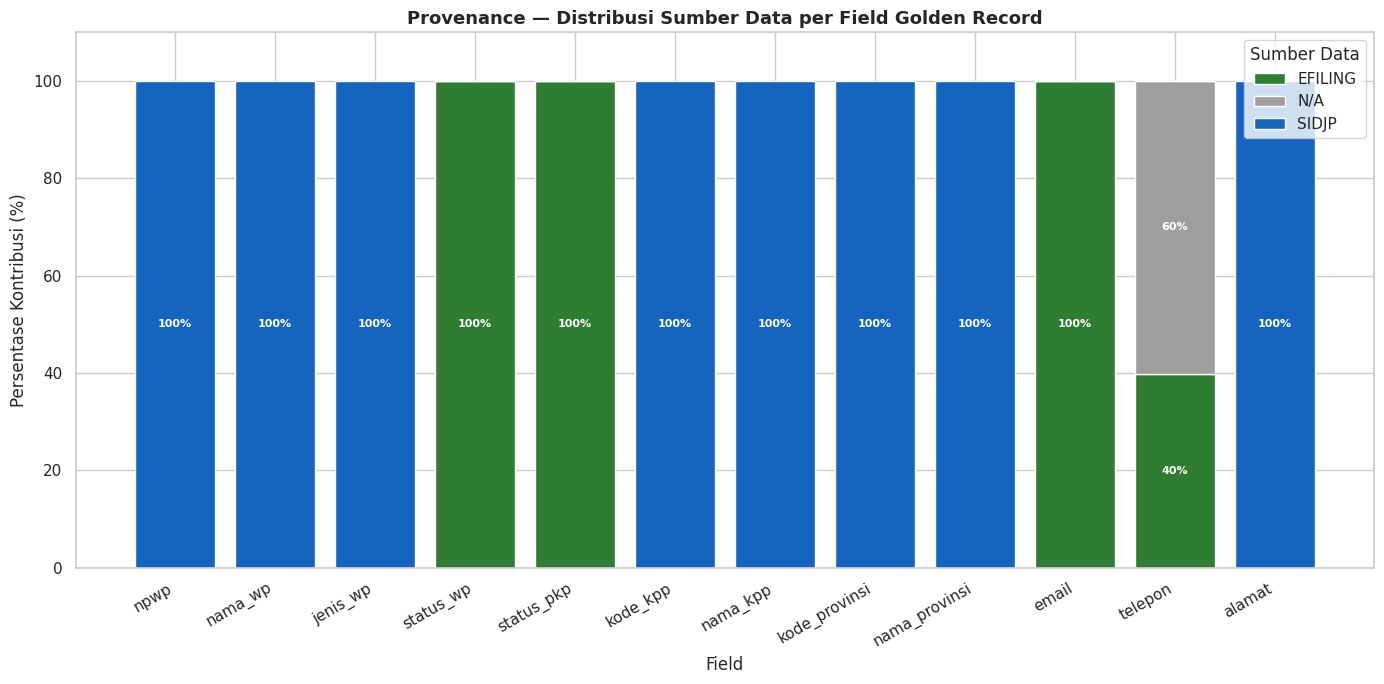

💾 Chart disimpan: chart_provenance.png


In [66]:
# ============================================================
# CELL 10: PROVENANCE ANALYSIS
# Dari sumber mana setiap field dalam golden record berasal?
# ============================================================

print('📊 ANALISIS PROVENANCE — ASAL-USUL DATA:')
print('='*60)

# Distribusi sumber per field
prov_summary = df_provenance.groupby(['field','source']).size().unstack(fill_value=0)

print(f'   Tabel distribusi sumber per field:')
display(prov_summary)

# Persen kontribusi per sumber
prov_pct = prov_summary.div(prov_summary.sum(axis=1), axis=0) * 100
print(f'\n   Persentase kontribusi per sumber:')
display(prov_pct.round(1))

# Hitung overall dominance per sumber
source_contrib = df_provenance['source'].value_counts(normalize=True) * 100
print(f'\n   Kontribusi keseluruhan per sumber:')
for src, pct in source_contrib.items():
    bar = '█' * int(pct / 3)
    print(f'   {src:<12}: {pct:5.1f}% {bar}')

# Visualisasi stacked bar provenance per field
fig, ax = plt.subplots(figsize=(14, 7))

fields_to_plot = [f for f in FIELD_RULES.keys() if f in prov_pct.index][:12]
prov_plot = prov_pct.loc[fields_to_plot]

colors_src = {'SIDJP':'#1565C0','EFILING':'#2E7D32','N/A':'#9E9E9E','UNKNOWN':'#BDBDBD'}
bottom = np.zeros(len(fields_to_plot))

for src in prov_plot.columns:
    color = colors_src.get(src, '#78909C')
    vals  = prov_plot[src].values
    ax.bar(fields_to_plot, vals, bottom=bottom, label=src, color=color, edgecolor='white')
    # Label di tengah bar jika cukup besar
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold')
    bottom += vals

ax.set_xlabel('Field')
ax.set_ylabel('Persentase Kontribusi (%)')
ax.set_title('Provenance — Distribusi Sumber Data per Field Golden Record',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(title='Sumber Data', loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart_provenance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart disimpan: chart_provenance.png')



In [67]:
# ============================================================
# CELL 11: QUALITY VALIDATION GOLDEN RECORD
# ============================================================

print('🔍 QUALITY CHECK — GOLDEN RECORD DATASET:')
print('='*65)

checks = []

# Check 1: Tidak ada duplikat NPWP dalam golden record
n_dup_gr = df_golden['gr_npwp'].duplicated().sum()
checks.append(('NPWP Unik dalam GR', n_dup_gr == 0,
               f'{n_dup_gr} duplikat ditemukan'))

# Check 2: Semua GR punya gr_id
n_no_id = df_golden['gr_id'].isna().sum()
checks.append(('Semua GR punya gr_id', n_no_id == 0,
               f'{n_no_id} GR tanpa id'))

# Check 3: Field kritis terisi
for field in ['nama_wp', 'jenis_wp', 'status_wp', 'kode_kpp']:
    n_null = df_golden[field].isna().sum() if field in df_golden.columns else 0
    checks.append((f'{field} tidak null', n_null == 0,
                   f'{n_null} null ditemukan'))

# Check 4: created_at terisi semua
n_no_ts = df_golden['created_at'].isna().sum()
checks.append(('created_at terisi', n_no_ts == 0,
               f'{n_no_ts} tanpa timestamp'))

# Check 5: source_count >= 1
n_no_src = (df_golden['source_count'] < 1).sum()
checks.append(('source_count >= 1', n_no_src == 0,
               f'{n_no_src} GR tanpa sumber'))

# Tampilkan hasil
all_pass = True
for check_name, passed, detail in checks:
    status = '✅ PASS' if passed else '❌ FAIL'
    if not passed: all_pass = False
    print(f'   {status}  {check_name:<35} | {detail}')

print('='*65)
if all_pass:
    print('   ✅ SEMUA CHECK PASSED — Golden Record siap dipromosikan!')
else:
    print('   ❌ ADA CHECK YANG GAGAL — Perbaiki sebelum export!')

# Statistik ringkasan
print(f'\n📊 STATISTIK GOLDEN RECORD:')
print(f'   Total GR          : {len(df_golden):,}')
print(f'   GR dengan konflik : {(df_golden["n_conflicts"] > 0).sum():,}')
print(f'   Avg konflik / GR  : {df_golden["n_conflicts"].mean():.2f}')
print(f'   GR dari 2 sumber  : {(df_golden["source_count"] > 1).sum():,}')
print(f'   GR dari 1 sumber  : {(df_golden["source_count"] == 1).sum():,}')



🔍 QUALITY CHECK — GOLDEN RECORD DATASET:
   ✅ PASS  NPWP Unik dalam GR                  | 0 duplikat ditemukan
   ✅ PASS  Semua GR punya gr_id                | 0 GR tanpa id
   ✅ PASS  nama_wp tidak null                  | 0 null ditemukan
   ✅ PASS  jenis_wp tidak null                 | 0 null ditemukan
   ✅ PASS  status_wp tidak null                | 0 null ditemukan
   ✅ PASS  kode_kpp tidak null                 | 0 null ditemukan
   ✅ PASS  created_at terisi                   | 0 tanpa timestamp
   ✅ PASS  source_count >= 1                   | 0 GR tanpa sumber
   ✅ SEMUA CHECK PASSED — Golden Record siap dipromosikan!

📊 STATISTIK GOLDEN RECORD:
   Total GR          : 500
   GR dengan konflik : 500
   Avg konflik / GR  : 1.20
   GR dari 2 sumber  : 500
   GR dari 1 sumber  : 0


In [68]:
# ============================================================
# CELL 12: EXPORT SEMUA OUTPUT LAB 4
# ============================================================

# ── 1. Golden Record Dataset (main output) ──
df_golden.to_csv('golden_record_wp.csv', index=False)
print(f'✅ golden_record_wp.csv       — {len(df_golden):,} golden records')

# ── 2. Provenance Log ──
df_provenance.to_csv('provenance_log.csv', index=False)
print(f'✅ provenance_log.csv         — {len(df_provenance):,} entri provenance')

# ── 3. Conflict Log ──
if len(df_conflicts) > 0:
    df_conflicts.to_csv('conflict_log.csv', index=False)
    print(f'✅ conflict_log.csv           — {len(df_conflicts):,} konflik tercatat')

# ── 4. Summary JSON ──
summary = {
    'lab'            : 'LAB4 — Golden Record Simulation',
    'generated_at'   : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_gr'       : len(df_golden),
    'total_conflicts': len(df_conflicts),
    'sources'        : ['SIDJP', 'EFILING'],
    'survivorship_rules': {f: r[0] for f, r in FIELD_RULES.items()},
}
with open('lab4_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'✅ lab4_summary.json          — metadata dan konfigurasi lab')

print(f'\n📄 PREVIEW GOLDEN RECORD (5 baris pertama):')
display(df_golden[['gr_id','gr_npwp','nama_wp','jenis_wp','email',
                    'source_count','sources_used','n_conflicts','created_at']].head(5))



✅ golden_record_wp.csv       — 500 golden records
✅ provenance_log.csv         — 9,500 entri provenance
✅ conflict_log.csv           — 602 konflik tercatat
✅ lab4_summary.json          — metadata dan konfigurasi lab

📄 PREVIEW GOLDEN RECORD (5 baris pertama):


,gr_id,gr_npwp,nama_wp,jenis_wp,email,source_count,sources_used,n_conflicts,created_at
0,GR_000082607793058,00.008.260.7-793.058,YUNITA UYAINAH,Orang Pribadi,shakilasuwarno@example.net,2,"SIDJP,EFILING",1,2026-06-09 20:22:18
1,GR_000114829327794,00.011.482.9-327.794,RATNA SITUMORANG,Orang Pribadi,gadangnovitasari@example.net,2,"SIDJP,EFILING",1,2026-06-09 20:22:18
2,GR_000452768268014,00.045.276.8-268.014,CV UD NUGROHO MANSUR,Badan,msiregar@example.org,2,"SIDJP,EFILING",1,2026-06-09 20:22:18
3,GR_000653554443387,00.065.355.4-443.387,UMAY PURNAWATI,Orang Pribadi,radenhutagalung@example.com,2,"SIDJP,EFILING",1,2026-06-09 20:22:18
4,GR_000720110649021,00.072.011.0-649.021,HJ. SHAKILA NAPITUPULU,Orang Pribadi,agustinalanang@example.net,2,"SIDJP,EFILING",1,2026-06-09 20:22:18


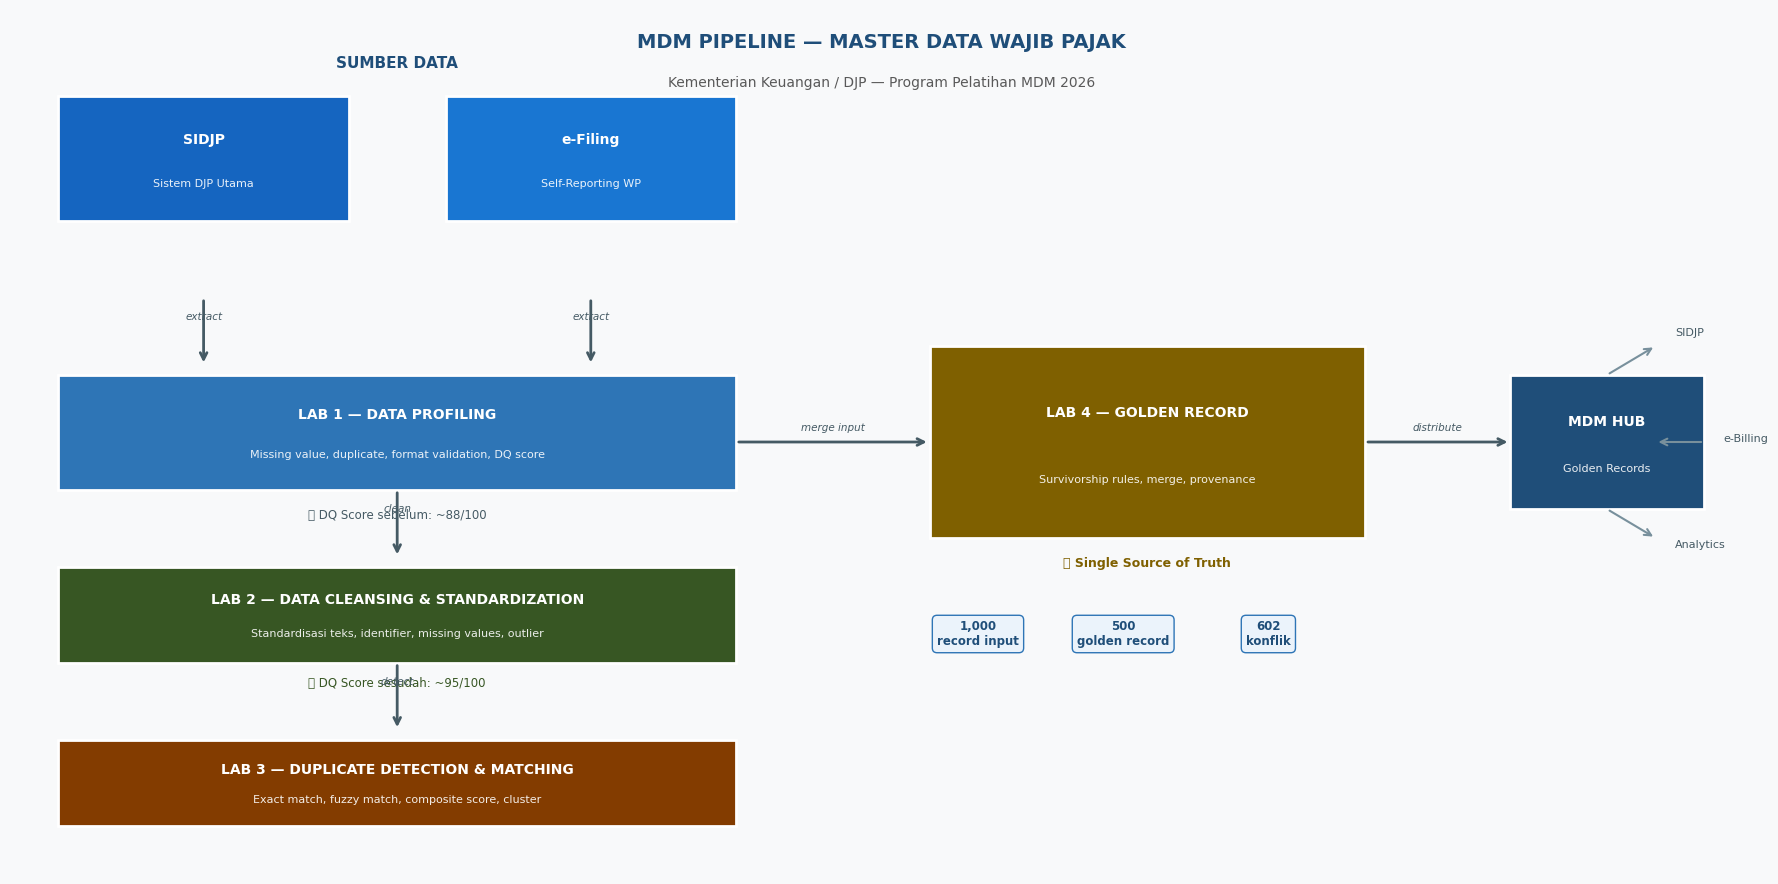

💾 Pipeline diagram disimpan: chart_mdm_pipeline.png

🏁 LAB 4 SELESAI! Golden Record siap untuk LAB 5: API & Data Integration


In [69]:
# ============================================================
# CELL 13: VISUALISASI PIPELINE MDM END-TO-END
# Diagram yang merangkum seluruh perjalanan data dari LAB 1-4
# ============================================================

fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor('#F8F9FA')
ax  = fig.add_subplot(111)
ax.set_xlim(0, 18); ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#F8F9FA')

# ── Fungsi helper untuk menggambar kotak ──
def draw_box(ax, x, y, w, h, label, sublabel, color, text_color='white'):
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='white',
                          linewidth=2, zorder=3)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h*0.65, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color=text_color, zorder=4)
    ax.text(x+w/2, y+h*0.3, sublabel, ha='center', va='center',
            fontsize=8, color=text_color, alpha=0.9, zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#455A64', lw=2), zorder=5)
    if label:
        # Calculate midpoint for label placement
        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2
        # Place label slightly above the midpoint of the arrow
        ax.text(mid_x, mid_y + 0.15, label, ha='center', va='center',
                fontsize=7.5, color='#455A64', style='italic')

# ── Layer 1: Sumber Data ──
ax.text(4, 8.4, 'SUMBER DATA', ha='center', fontsize=11,
        fontweight='bold', color='#1F4E79')
draw_box(ax, 0.5, 6.8, 3.0, 1.3, 'SIDJP', 'Sistem DJP Utama', '#1565C0')
draw_box(ax, 4.5, 6.8, 3.0, 1.3, 'e-Filing', 'Self-Reporting WP', '#1976D2')

# ── Layer 2: LAB 1 — Profiling ──
draw_arrow(ax, 2.0, 6.0, 2.0, 5.3, 'extract')
draw_arrow(ax, 6.0, 6.0, 6.0, 5.3, 'extract')
draw_box(ax, 0.5, 4.0, 7.0, 1.2, 'LAB 1 — DATA PROFILING',
         'Missing value, duplicate, format validation, DQ score', '#2E75B6')
ax.text(4, 3.7, '📊 DQ Score sebelum: ~88/100', ha='center', fontsize=8.5, color='#455A64')

# ── Layer 3: LAB 2 — Cleansing ──
draw_arrow(ax, 4, 4.0, 4, 3.3, 'clean')
draw_box(ax, 0.5, 2.2, 7.0, 1.0, 'LAB 2 — DATA CLEANSING & STANDARDIZATION',
         'Standardisasi teks, identifier, missing values, outlier', '#375623')
ax.text(4, 1.95, '📊 DQ Score sesudah: ~95/100', ha='center', fontsize=8.5, color='#375623')

# ── LAB 3 — Duplicate Detection ──
draw_arrow(ax, 4, 2.2, 4, 1.5, 'detect')
draw_box(ax, 0.5, 0.5, 7.0, 0.9, 'LAB 3 — DUPLICATE DETECTION & MATCHING',
         'Exact match, fuzzy match, composite score, cluster', '#833C00')

# ── Arrow ke LAB 4 ──
draw_arrow(ax, 7.5, 4.5, 9.5, 4.5, 'merge input')

# ── Layer 4: LAB 4 — Golden Record ──
draw_box(ax, 9.5, 3.5, 4.5, 2.0, 'LAB 4 — GOLDEN RECORD',
         'Survivorship rules, merge, provenance', '#7F6000')
ax.text(11.75, 3.2, '🏆 Single Source of Truth', ha='center',
        fontsize=9, fontweight='bold', color='#7F6000')

# ── Output: Golden Record ──
draw_arrow(ax, 14.0, 4.5, 15.5, 4.5, 'distribute')
draw_box(ax, 15.5, 3.8, 2.0, 1.4, 'MDM HUB', 'Golden Records', '#1F4E79')

# ── Downstream ──
ax.annotate('', xy=(17, 5.5), xytext=(16.5, 5.2),
            arrowprops=dict(arrowstyle='->', color='#78909C', lw=1.5))
ax.annotate('', xy=(17, 4.5), xytext=(17.5, 4.5),
            arrowprops=dict(arrowstyle='->', color='#78909C', lw=1.5))
ax.annotate('', xy=(17, 3.5), xytext=(16.5, 3.8),
            arrowprops=dict(arrowstyle='->', color='#78909C', lw=1.5))
ax.text(17.2, 5.6, 'SIDJP', fontsize=8, color='#455A64')
ax.text(17.7, 4.5, 'e-Billing', fontsize=8, color='#455A64')
ax.text(17.2, 3.4, 'Analytics', fontsize=8, color='#455A64')

# ── Title ──
ax.text(9, 8.6, 'MDM PIPELINE — MASTER DATA WAJIB PAJAK',
        ha='center', fontsize=14, fontweight='bold', color='#1F4E79')
ax.text(9, 8.2, 'Kementerian Keuangan / DJP — Program Pelatihan MDM 2026',
        ha='center', fontsize=10, color='#595959')

# Stats boxes
stats = [
    (10.0, 2.5, f'{len(df_combined):,}\nrecord input'),
    (11.5, 2.5, f'{len(df_golden):,}\ngolden record'),
    (13.0, 2.5, f'{len(df_conflicts):,}\nkonflik'),
]
for sx, sy, slabel in stats:
    ax.text(sx, sy, slabel, ha='center', va='center', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF3FB', edgecolor='#2E75B6'),
            color='#1F4E79', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_mdm_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Pipeline diagram disimpan: chart_mdm_pipeline.png')
print('\n🏁 LAB 4 SELESAI! Golden Record siap untuk LAB 5: API & Data Integration')


**API & DATA INTEGRATION**

In [70]:
# ============================================================
# CELL 1: INSTALL LIBRARY LAB 5
# ============================================================

!pip install fastapi uvicorn pyngrok nest-asyncio pydantic requests httpx -q

print('✅ Library berhasil diinstall:')
print('   fastapi     : framework modern untuk membangun REST API di Python')
print('   uvicorn     : ASGI server untuk menjalankan FastAPI')
print('   pyngrok     : membuat tunnel publik dari Colab ke internet')
print('   nest-asyncio: memungkinkan asyncio berjalan di dalam Jupyter/Colab')
print('   pydantic    : validasi data dan schema definition')
print('   requests    : HTTP client untuk mengonsumsi API')
print('   httpx       : async HTTP client (alternatif requests)')



✅ Library berhasil diinstall:
   fastapi     : framework modern untuk membangun REST API di Python
   uvicorn     : ASGI server untuk menjalankan FastAPI
   pyngrok     : membuat tunnel publik dari Colab ke internet
   nest-asyncio: memungkinkan asyncio berjalan di dalam Jupyter/Colab
   pydantic    : validasi data dan schema definition
   requests    : HTTP client untuk mengonsumsi API
   httpx       : async HTTP client (alternatif requests)


In [71]:
import pandas as pd
import numpy as np
import json, re, warnings, time, threading
from datetime import datetime
from typing import Optional, List
warnings.filterwarnings('ignore')

# FastAPI & server
from fastapi import FastAPI, HTTPException, Query, Depends
from fastapi.responses import JSONResponse
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field, validator
import uvicorn
import nest_asyncio
nest_asyncio.apply()  # wajib untuk menjalankan uvicorn di dalam Colab

# HTTP client
import requests

# Ngrok tunnel
from pyngrok import ngrok

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# ── Load golden record dari LAB 4 ──
try:
    df_gr = pd.read_csv('golden_record_wp.csv')
    print(f'✅ Golden record dimuat: {df_gr.shape}')
    print(f'   Kolom: {list(df_gr.columns)}')
except FileNotFoundError:
    print('❌ File tidak ditemukan. Pastikan LAB 4 sudah selesai.')
    raise

# Pastikan tipe data konsisten untuk Pydantic validation
df_gr['gr_npwp']   = df_gr['gr_npwp'].astype(str)
df_gr['nama_wp']   = df_gr['nama_wp'].fillna('').astype(str)
df_gr['kode_kpp']  = df_gr['kode_kpp'].fillna('').astype(str)
df_gr['kode_provinsi'] = df_gr['kode_provinsi'].astype(str)
df_gr['telepon'] = df_gr['telepon'].astype(str).replace('nan', None)

# Buat index lookup untuk performa API
NPWP_INDEX = df_gr.set_index('gr_npwp').to_dict(orient='index')
print(f'\n   Index lookup siap: {len(NPWP_INDEX):,} entri NPWP')
print(f'   Preview 1 entri:')
sample_npwp = df_gr['gr_npwp'].iloc[0]
print(f'   NPWP: {sample_npwp}')
print(f'   Data: {list(NPWP_INDEX[sample_npwp].items())[:5]}')

✅ Golden record dimuat: (500, 26)
   Kolom: ['npwp', 'nama_wp', 'jenis_wp', 'status_wp', 'status_pkp', 'kode_kpp', 'nama_kpp', 'kode_provinsi', 'nama_provinsi', 'email', 'telepon', 'alamat', 'kota', 'kode_pos', 'klu_kode', 'klu_nama', 'penghasilan', 'tanggal_daftar', 'nik', 'gr_id', 'gr_npwp', 'source_count', 'sources_used', 'n_conflicts', 'created_at', 'gr_version']

   Index lookup siap: 500 entri NPWP
   Preview 1 entri:
   NPWP: 00.008.260.7-793.058
   Data: [('npwp', '00.008.260.7-793.058'), ('nama_wp', 'YUNITA UYAINAH'), ('jenis_wp', 'Orang Pribadi'), ('status_wp', 'Aktif'), ('status_pkp', 'Non-PKP')]


In [72]:
# ============================================================
# CELL 3: KONSUMSI PUBLIC REST API
# Menggunakan JSONPlaceholder sebagai dummy REST API
# URL: https://jsonplaceholder.typicode.com
# ============================================================

BASE_URL = 'https://jsonplaceholder.typicode.com'

print('🌐 TEST KONSUMSI PUBLIC REST API:')
print('='*60)

# ── 1. GET — Ambil satu resource ──
print('\n1️⃣  GET /users/1 — Ambil data user dengan ID=1')
resp = requests.get(f'{BASE_URL}/users/1')
print(f'   Status Code : {resp.status_code}')
print(f'   Response Time: {resp.elapsed.total_seconds()*1000:.0f} ms')
user = resp.json()
print(f'   Data:')
for k, v in user.items():
    if not isinstance(v, dict):
        print(f'     {k:<12}: {v}')

# ── 2. GET — Ambil list dengan query parameter ──
print('\n2️⃣  GET /posts?userId=1 — Ambil posts milik user 1')
resp2 = requests.get(f'{BASE_URL}/posts', params={'userId': 1})
posts = resp2.json()
print(f'   Status Code  : {resp2.status_code}')
print(f'   Jumlah post  : {len(posts)}')
print(f'   Post pertama : {posts[0]["title"][:50]}')

# ── 3. POST — Kirim data baru ──
print('\n3️⃣  POST /posts — Kirim data post baru')
new_post = {
    'title' : 'Simulasi MDM Data Integration',
    'body'  : 'Golden record berhasil diintegrasikan ke sistem lain.',
    'userId': 1
}
resp3 = requests.post(f'{BASE_URL}/posts', json=new_post)
print(f'   Status Code  : {resp3.status_code}')
print(f'   Response     : {resp3.json()}')

# ── 4. Struktur Response ──
print('\n4️⃣  Analisis struktur response headers:')
for key, val in list(resp.headers.items())[:6]:
    print(f'   {key:<25}: {val}')

print('\n✅ Public API berhasil dikonsumsi!')
print('   Pola yang sama akan kita gunakan untuk MDM API kita sendiri.')



🌐 TEST KONSUMSI PUBLIC REST API:

1️⃣  GET /users/1 — Ambil data user dengan ID=1
   Status Code : 200
   Response Time: 732 ms
   Data:
     id          : 1
     name        : Leanne Graham
     username    : Bret
     email       : Sincere@april.biz
     phone       : 1-770-736-8031 x56442
     website     : hildegard.org

2️⃣  GET /posts?userId=1 — Ambil posts milik user 1
   Status Code  : 200
   Jumlah post  : 10
   Post pertama : sunt aut facere repellat provident occaecati excep

3️⃣  POST /posts — Kirim data post baru
   Status Code  : 201
   Response     : {'title': 'Simulasi MDM Data Integration', 'body': 'Golden record berhasil diintegrasikan ke sistem lain.', 'userId': 1, 'id': 101}

4️⃣  Analisis struktur response headers:
   Date                     : Tue, 09 Jun 2026 20:22:47 GMT
   Content-Type             : application/json; charset=utf-8
   Transfer-Encoding        : chunked
   Connection               : keep-alive
   Access-Control-Allow-Credentials: true
   Cache-Co

In [73]:
# ============================================================
# CELL 4: PYDANTIC SCHEMA — REQUEST & RESPONSE MODELS
# Pydantic otomatis memvalidasi tipe data dan format
# ============================================================

from pydantic import BaseModel, Field, validator
from typing import Optional, List
import re

# ── Schema untuk data Wajib Pajak ──
class WajibPajakResponse(BaseModel):
    """Schema response saat mengambil data WP dari MDM Hub."""
    gr_id          : str  = Field(..., description='ID unik golden record')
    gr_npwp        : str  = Field(..., description='NPWP format XX.XXX.XXX.X-XXX.XXX')
    nama_wp        : str  = Field(..., description='Nama Wajib Pajak')
    jenis_wp       : str  = Field(..., description='Orang Pribadi atau Badan')
    status_wp      : str  = Field(..., description='Aktif / Non-Aktif / Hapus')
    status_pkp     : Optional[str] = Field(None, description='PKP / Non-PKP')
    kode_kpp       : Optional[str] = Field(None, description='Kode KPP terdaftar')
    nama_kpp       : Optional[str] = Field(None, description='Nama KPP')
    kode_provinsi  : Optional[str] = Field(None, description='Kode provinsi 2 digit')
    nama_provinsi  : Optional[str] = Field(None, description='Nama provinsi')
    email          : Optional[str] = Field(None, description='Email WP')
    telepon        : Optional[str] = Field(None, description='Telepon WP')
    source_count   : Optional[int] = Field(None, description='Jumlah sumber data')
    sources_used   : Optional[str] = Field(None, description='Sumber data yang digunakan')
    created_at     : Optional[str] = Field(None, description='Timestamp pembuatan GR')

    class Config:
        # Izinkan field ekstra dari dataset (tidak akan dikembalikan ke response)
        extra = 'ignore'


class ValidationRequest(BaseModel):
    """Schema request untuk validasi data WP sebelum masuk ke sistem."""
    npwp     : str           = Field(..., description='NPWP yang akan divalidasi')
    nama_wp  : str           = Field(..., min_length=2, description='Nama WP')
    jenis_wp : str           = Field(..., description='Jenis WP')
    email    : Optional[str] = Field(None, description='Email WP (opsional)')

    @validator('npwp')
    def validate_npwp_format(cls, v):
        """Validasi format NPWP saat request masuk."""
        pattern = r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'
        if not re.match(pattern, v):
            raise ValueError(f'Format NPWP tidak valid: {v}. Harus XX.XXX.XXX.X-XXX.XXX')
        return v

    @validator('jenis_wp')
    def validate_jenis_wp(cls, v):
        valid = ['Orang Pribadi', 'Badan']
        if v not in valid:
            raise ValueError(f'jenis_wp harus salah satu dari: {valid}')
        return v

    @validator('email')
    def validate_email_format(cls, v):
        if v is None: return v
        if not re.match(r'^[\w.+\-]+@[\w\-]+\.[a-z]{2,}$', v.lower()):
            raise ValueError(f'Format email tidak valid: {v}')
        return v.lower()


class ValidationResponse(BaseModel):
    """Schema response hasil validasi data WP."""
    is_valid       : bool
    npwp           : str
    found_in_mdm   : bool
    match_nama     : Optional[bool] = None
    match_jenis    : Optional[bool] = None
    mdm_nama       : Optional[str]  = None
    mdm_status     : Optional[str]  = None
    issues         : List[str]      = []
    validated_at   : str

print('✅ Pydantic schemas berhasil didefinisikan:')
print('   WajibPajakResponse  : schema response data WP')
print('   ValidationRequest   : schema request validasi dengan auto-validation')
print('   ValidationResponse  : schema response hasil validasi')

# Test validasi Pydantic
print('\n🔬 Test validasi Pydantic:')
try:
    req = ValidationRequest(
        npwp='01.234.567.8-001.000',
        nama_wp='PT. Test Perusahaan',
        jenis_wp='Badan'
    )
    print(f'   ✅ Valid: {req.dict()}')
except Exception as e:
    print(f'   ❌ Error: {e}')

print('\n   Test dengan NPWP format salah:')
try:
    req_bad = ValidationRequest(
        npwp='01234567001000',  # format salah
        nama_wp='PT. Test',
        jenis_wp='Badan'
    )
except Exception as e:
    print(f'   ✅ Pydantic berhasil menolak: {str(e)[:80]}')



✅ Pydantic schemas berhasil didefinisikan:
   WajibPajakResponse  : schema response data WP
   ValidationRequest   : schema request validasi dengan auto-validation
   ValidationResponse  : schema response hasil validasi

🔬 Test validasi Pydantic:
   ✅ Valid: {'npwp': '01.234.567.8-001.000', 'nama_wp': 'PT. Test Perusahaan', 'jenis_wp': 'Badan', 'email': None}

   Test dengan NPWP format salah:
   ✅ Pydantic berhasil menolak: 1 validation error for ValidationRequest
npwp
  Value error, Format NPWP tidak v


In [74]:
# ============================================================
# CELL 5: MEMBANGUN FASTAPI MDM SERVER
# Endpoint yang disediakan:
#   GET  /                         → health check
#   GET  /api/wp/{npwp}            → cari WP by NPWP
#   GET  /api/wp/search            → search WP by nama
#   GET  /api/wp/list              → daftar WP dengan pagination
#   POST /api/wp/validate          → validasi data WP
#   GET  /api/stats                → statistik MDM Hub
# ============================================================

# Inisialisasi FastAPI
app = FastAPI(
    title       = 'MDM Hub API — Simulasi DJP',
    description = 'API untuk mengakses Master Data Wajib Pajak dari MDM Hub',
    version     = '1.0.0',
    docs_url    = '/docs',   # Swagger UI tersedia di /docs
    redoc_url   = '/redoc',  # ReDoc tersedia di /redoc
)

# CORS middleware — izinkan akses dari browser dan Postman
app.add_middleware(
    CORSMiddleware,
    allow_origins  = ['*'],
    allow_methods  = ['*'],
    allow_headers  = ['*'],
)

# ── In-memory 'database' dari golden record ──
# Dalam produksi ini adalah koneksi ke database/MDM Hub
MDM_DB = df_gr.copy()


# ── ENDPOINT 1: Health Check ──
@app.get('/', tags=['System'])
def health_check():
    return {
        'status'     : 'healthy',
        'service'    : 'MDM Hub API',
        'version'    : '1.0.0',
        'total_records': len(MDM_DB),
        'timestamp'  : datetime.now().isoformat(),
    }


# ── ENDPOINT 2: Cari WP by NPWP ──
import pandas as pd
from fastapi import HTTPException

@app.get("/api/wp/{npwp}", response_model=WajibPajakResponse)
def get_wp_by_npwp(npwp: str):
    # Logika pencarian Anda (ganti sesuai variabel dataframe asli Anda)
    data_filter = df_gr[df_gr['gr_npwp'] == npwp]

    if data_filter.empty:
        raise HTTPException(status_code=404, detail="Wajib Pajak tidak ditemukan")

    # Ambil baris pertama sebagai dictionary murni
    result = data_filter.iloc[0].to_dict()

    # ── SANITASI DATA UNTUK PYDANTIC ──
    if 'kode_provinsi' in result and result['kode_provinsi'] is not None:
        result['kode_provinsi'] = str(result['kode_provinsi'])

    if 'telepon' in result:
        if pd.isna(result['telepon']) or result['telepon'] == 'nan':
            result['telepon'] = None  # atau "" sesuai skema opsional Anda
        else:
            result['telepon'] = str(result['telepon'])

    return WajibPajakResponse(**result)


# ── ENDPOINT 3: Search WP by Nama ──
@app.get('/api/wp/search/', tags=['WP Data'])
def search_wp_by_nama(
    q     : str = Query(..., min_length=3, description='Kata kunci nama WP'),
    limit : int = Query(10,  ge=1, le=100, description='Jumlah hasil maksimum'),
    jenis : Optional[str] = Query(None, description='Filter: Orang Pribadi / Badan'),
):
    """
    Cari Wajib Pajak berdasarkan nama (case-insensitive, partial match).
    """
    results = MDM_DB[
        MDM_DB['nama_wp'].str.contains(q, case=False, na=False)
    ]
    if jenis:
        results = results[results['jenis_wp'] == jenis]
    results = results.head(limit)
    return {
        'query'  : q,
        'total'  : len(results),
        'results': results[['gr_npwp','nama_wp','jenis_wp','status_wp','kode_kpp']]
                   .to_dict(orient='records')
    }


# ── ENDPOINT 4: List WP dengan Pagination ──
@app.get('/api/wp/list/', tags=['WP Data'])
def list_wp(
    page      : int = Query(1,  ge=1),
    page_size : int = Query(20, ge=1, le=100),
    status    : Optional[str] = Query(None),
    provinsi  : Optional[str] = Query(None),
):
    """Ambil daftar WP dengan filter dan pagination."""
    data = MDM_DB.copy()
    if status:   data = data[data['status_wp'] == status]
    if provinsi: data = data[data['kode_provinsi'] == provinsi]
    total = len(data)
    start = (page - 1) * page_size
    end   = start + page_size
    page_data = data.iloc[start:end]
    return {
        'page'      : page,
        'page_size' : page_size,
        'total'     : total,
        'total_pages': (total + page_size - 1) // page_size,
        'data'      : page_data[['gr_npwp','nama_wp','jenis_wp',
                                  'status_wp','kode_provinsi']]
                      .fillna('').to_dict(orient='records')
    }


# ── ENDPOINT 5: Validasi Data WP ──
@app.post('/api/wp/validate', response_model=ValidationResponse, tags=['Validation'])
def validate_wp(req: ValidationRequest):
    """
    Validasi data WP terhadap golden record di MDM Hub.
    Digunakan oleh sistem lain sebelum memproses data WP.
    """
    issues        = []
    found_in_mdm  = False
    match_nama    = None
    match_jenis   = None
    mdm_nama      = None
    mdm_status    = None

    # Cari di MDM
    mdm_record = NPWP_INDEX.get(req.npwp)

    if mdm_record:
        found_in_mdm = True
        mdm_nama     = str(mdm_record.get('nama_wp', ''))
        mdm_status   = str(mdm_record.get('status_wp', ''))

        # Bandingkan nama (case-insensitive)
        match_nama = req.nama_wp.upper() == mdm_nama.upper()
        if not match_nama:
            issues.append(f'Nama tidak cocok: input={req.nama_wp} | MDM={mdm_nama}')

        # Bandingkan jenis WP
        mdm_jenis  = str(mdm_record.get('jenis_wp', ''))
        match_jenis= req.jenis_wp == mdm_jenis
        if not match_jenis:
            issues.append(f'Jenis WP tidak cocok: input={req.jenis_wp} | MDM={mdm_jenis}')

        # Cek status WP
        if mdm_status == 'Hapus':
            issues.append(f'WP berstatus Hapus — tidak dapat diproses')
        elif mdm_status == 'Non-Aktif':
            issues.append(f'WP berstatus Non-Aktif — perlu konfirmasi')
    else:
        issues.append(f'NPWP {req.npwp} tidak ditemukan dalam MDM Hub')

    is_valid = found_in_mdm and len(issues) == 0
    return ValidationResponse(
        is_valid     = is_valid,
        npww         = req.npwp,
        npwp         = req.npwp,
        found_in_mdm = found_in_mdm,
        match_nama   = match_nama,
        match_jenis  = match_jenis,
        mdm_nama     = mdm_nama,
        mdm_status   = mdm_status,
        issues       = issues,
        validated_at = datetime.now().isoformat(),
    )


# ── ENDPOINT 6: Statistik MDM Hub ──
@app.get('/api/stats', tags=['System'])
def get_stats():
    """Statistik ringkasan data dalam MDM Hub."""
    return {
        'total_wp'           : len(MDM_DB),
        'by_jenis'           : MDM_DB['jenis_wp'].value_counts().to_dict(),
        'by_status'          : MDM_DB['status_wp'].value_counts().to_dict(),
        'by_provinsi'        : MDM_DB['kode_provinsi'].value_counts().head(5).to_dict(),
        'with_email'         : int(MDM_DB['email'].notna().sum()),
        'with_phone'         : int(MDM_DB['telepon'].notna().sum()),
        'multi_source_record': int((MDM_DB['source_count'] > 1).sum()),
        'generated_at'       : datetime.now().isoformat(),
    }

print('✅ FastAPI MDM Server berhasil didefinisikan!')
print(f'   Endpoint tersedia:')
for route in app.routes:
    if hasattr(route, 'methods'):
        methods = ', '.join(route.methods)
        print(f'   {methods:<8} {route.path}')



✅ FastAPI MDM Server berhasil didefinisikan!
   Endpoint tersedia:
   GET, HEAD /openapi.json
   GET, HEAD /docs
   GET, HEAD /docs/oauth2-redirect
   GET, HEAD /redoc
   GET      /
   GET      /api/wp/{npwp}
   GET      /api/wp/search/
   GET      /api/wp/list/
   POST     /api/wp/validate
   GET      /api/stats


In [75]:
# ============================================================
# CELL 6: JALANKAN SERVER + BUAT NGROK TUNNEL
# Server berjalan di background thread
# Ngrok membuat URL publik yang bisa diakses Postman
# ============================================================

PORT = 8000

def run_server():
    """Jalankan uvicorn server di background thread."""
    uvicorn.run(app, host='0.0.0.0', port=PORT, log_level='error')

# Start server di thread terpisah agar tidak memblokir Colab
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(2)  # tunggu server ready

# ── Test server lokal ──
try:
    r = requests.get(f'http://localhost:{PORT}/')
    print(f'✅ Server lokal berjalan di port {PORT}')
    print(f'   Health check: {r.json()}')
except Exception as e:
    print(f'❌ Server gagal: {e}')

# ── Buat Ngrok Tunnel ──
# Catatan: daftarkan akun gratis di ngrok.com untuk mendapat authtoken
# Setelah dapat token, uncomment baris berikut:
# ngrok.set_auth_token('ISI_TOKEN_NGROK_ANDA_DISINI')

try:
    public_url = ngrok.connect(PORT)
    print(f'\n✅ Ngrok tunnel aktif!')
    print(f'   URL Publik  : {public_url}')
    print(f'   Swagger UI  : {public_url}/docs')
    print(f'\n   Salin URL publik di atas ke Postman untuk testing!')
    print(f'\n   Contoh endpoint yang bisa ditest di Postman:')
    print(f'   GET  {public_url}/')
    print(f'   GET  {public_url}/api/wp/list/')
    print(f'   GET  {public_url}/api/stats')
    print(f'   POST {public_url}/api/wp/validate')
    BASE_API = str(public_url)
except Exception as e:
    print(f'⚠ Ngrok tidak tersedia: {e}')
    print(f'   Gunakan URL lokal: http://localhost:{PORT}')
    BASE_API = f'http://localhost:{PORT}'
    print(f'   (Semua test akan dijalankan dari Python langsung)')



✅ Server lokal berjalan di port 8000
   Health check: {'status': 'healthy', 'service': 'MDM Hub API', 'version': '1.0.0', 'total_records': 500, 'timestamp': '2026-06-09T20:22:51.338478'}


ERROR:pyngrok.process.ngrok:t=2026-06-09T20:22:55+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-09T20:22:55+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-09T20:22:55+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

⚠ Ngrok tidak tersedia: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.
   Gunakan URL lokal: http://localhost:8000
   (Semua test akan dijalankan dari Python langsung)


In [76]:
import threading
import time
import requests
import uvicorn
from pyngrok import ngrok, process

# ============================================================
# CELL 6: JALANKAN SERVER + BUAT NGROK TUNNEL (FIXED)
# ============================================================

PORT = 8000

# 1. Bersihkan sisa-sisa koneksi Ngrok & Port lama (Mencegah Errno 98)
try:
    ngrok.kill()  # Matikan semua proses ngrok yang masih menggantung
    print("🧹 Membersihkan sisa proses Ngrok lama...")
except:
    pass

def run_server():
    """Jalankan uvicorn server di background thread."""
    try:
        # Menggunakan log_level='info' agar Anda bisa melihat jika ada request masuk
        uvicorn.run(app, host='0.0.0.0', port=PORT, log_level='info')
    except Exception as e:
        print(f"\n❌ Gagal menjalankan Uvicorn: {e}")

# Start server di thread terpisah
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(3)  # Beri waktu sedikit lebih lama agar server benar-benar siap

# ── Test server lokal ──
try:
    r = requests.get(f'http://localhost:{PORT}/')
    print(f'✅ Server lokal berjalan di port {PORT}')
    print(f'   Health check: {r.json()}')
except Exception as e:
    print(f'❌ Server lokal gagal diakses: {e}')

# ── Konfigurasi & Buat Ngrok Tunnel ──
# ⚠️ WAJIB: Masukkan token ngrok Anda di bawah ini!
# Daftar gratis di https://dashboard.ngrok.com/signup untuk dapat token.
NGROK_TOKEN = "3EcJKm6wW4ip4mm7ECBJFVGXg04_3nS9PqiBfK5gbYaYgDmVM"

if NGROK_TOKEN == "MASUKKAN_TOKEN_NGROK_ANDA_DISINI" or not NGROK_TOKEN:
    print('\n❌ ERROR: Anda belum memasukkan Token Ngrok!')
    print('   Silakan daftar di https://dashboard.ngrok.com/signup dan tempel token Anda pada variabel NGROK_TOKEN.')
    BASE_API = f'http://localhost:{PORT}'
else:
    try:
        # Set token ke pyngrok
        ngrok.set_auth_token(NGROK_TOKEN)

        # Buat tunnel HTTP
        public_url = ngrok.connect(PORT)
        print(f'\n✅ Ngrok tunnel aktif!')
        print(f'   URL Publik   : {public_url}')
        print(f'   Swagger UI   : {public_url}/docs')
        print(f'\n   Salin URL publik di atas ke Postman untuk testing!')
        print(f'\n   Contoh endpoint yang bisa ditest di Postman:')
        print(f'   GET  {public_url}/')
        print(f'   GET  {public_url}/api/wp/list/')
        print(f'   GET  {public_url}/api/stats')
        print(f'   POST {public_url}/api/wp/validate')
        BASE_API = str(public_url)
    except Exception as e:
        print(f'\n⚠ Ngrok gagal start: {e}')
        print(f'   Gunakan URL lokal: http://localhost:{PORT}')
        BASE_API = f'http://localhost:{PORT}'

🧹 Membersihkan sisa proses Ngrok lama...


INFO:     Started server process [6869]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


INFO:     127.0.0.1:40722 - "GET / HTTP/1.1" 200 OK
✅ Server lokal berjalan di port 8000
   Health check: {'status': 'healthy', 'service': 'MDM Hub API', 'version': '1.0.0', 'total_records': 500, 'timestamp': '2026-06-09T20:22:58.114831'}

✅ Ngrok tunnel aktif!
   URL Publik   : NgrokTunnel: "https://everyone-deuce-tasty.ngrok-free.dev" -> "http://localhost:8000"
   Swagger UI   : NgrokTunnel: "https://everyone-deuce-tasty.ngrok-free.dev" -> "http://localhost:8000"/docs

   Salin URL publik di atas ke Postman untuk testing!

   Contoh endpoint yang bisa ditest di Postman:
   GET  NgrokTunnel: "https://everyone-deuce-tasty.ngrok-free.dev" -> "http://localhost:8000"/
   GET  NgrokTunnel: "https://everyone-deuce-tasty.ngrok-free.dev" -> "http://localhost:8000"/api/wp/list/
   GET  NgrokTunnel: "https://everyone-deuce-tasty.ngrok-free.dev" -> "http://localhost:8000"/api/stats
   POST NgrokTunnel: "https://everyone-deuce-tasty.ngrok-free.dev" -> "http://localhost:8000"/api/wp/validate


In [77]:
import threading
import time
import requests
import uvicorn
from pyngrok import ngrok, process

# ============================================================
# CELL 6: JALANKAN SERVER + BUAT NGROK TUNNEL (FIXED VERSION)
# ============================================================

PORT = 8000

# 1. Bersihkan sisa-sisa koneksi Ngrok & Port lama (Mencegah Errno 98)
try:
    ngrok.kill()  # Matikan semua proses ngrok yang masih menggantung
    print("🧹 Membersihkan sisa proses Ngrok lama...")
except:
    pass

def run_server():
    """Jalankan uvicorn server di background thread."""
    try:
        # Menggunakan log_level='info' agar Anda bisa melihat jika ada request masuk
        uvicorn.run(app, host='0.0.0.0', port=PORT, log_level='info')
    except Exception as e:
        print(f"\n❌ Gagal menjalankan Uvicorn: {e}")

# Start server di thread terpisah agar tidak memblokir Colab
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(3)  # Beri waktu sedikit lebih lama agar server benar-benar siap

# ── Test server lokal ──
try:
    r = requests.get(f'http://localhost:{PORT}/')
    print(f'✅ Server lokal berjalan di port {PORT}')
    print(f'   Health check: {r.json()}')
except Exception as e:
    print(f'❌ Server lokal gagal diakses: {e}')

# ── Konfigurasi & Buat Ngrok Tunnel ──
# ⚠️ WAJIB: Masukkan token ngrok Anda di bawah ini!
NGROK_TOKEN = "3EcJKm6wW4ip4mm7ECBJFVGXg04_3nS9PqiBfK5gbYaYgDmVM"

if NGROK_TOKEN == "MASUKKAN_TOKEN_NGROK_ANDA_DISINI" or not NGROK_TOKEN:
    print('\n❌ ERROR: Anda belum memasukkan Token Ngrok!')
    print('   Silakan daftar di https://dashboard.ngrok.com/signup dan tempel token Anda pada variabel NGROK_TOKEN.')
    BASE_API = f'http://localhost:{PORT}'
else:
    try:
        # Set token ke pyngrok
        ngrok.set_auth_token(NGROK_TOKEN)

        # Buat tunnel HTTP
        public_url = ngrok.connect(PORT)

        # FIX: Mengambil string URL secara aman baik dari properti .public_url maupun casting langsung
        url_string = public_url.public_url if hasattr(public_url, 'public_url') else str(public_url)
        # Menghapus penanda panah bawaan ngrok gratis jika ter-casting sebagai string mentah
        if "->" in url_string:
            url_string = url_string.split()[1].replace('"', '')

        print(f'\n✅ Ngrok tunnel aktif!')
        print(f'   URL Publik   : {url_string}')
        print(f'   Swagger UI   : {url_string}/docs')
        print(f'\n   Salin URL publik di atas ke Postman untuk testing!')
        print(f'\n   Contoh endpoint yang bisa ditest di Postman:')
        print(f'   GET  {url_string}/')
        print(f'   GET  {url_string}/api/wp/list/')
        print(f'   GET  {url_string}/api/stats')
        print(f'   POST {url_string}/api/wp/validate')

        # Variabel penampung URL utama untuk CELL 7
        BASE_API = url_string

    except Exception as e:
        print(f'\n⚠️ Ngrok gagal start: {e}')
        print(f'   Gunakan URL lokal: http://localhost:{PORT}')
        BASE_API = f'http://localhost:{PORT}'

🧹 Membersihkan sisa proses Ngrok lama...


INFO:     Started server process [6869]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


INFO:     127.0.0.1:47086 - "GET / HTTP/1.1" 200 OK
✅ Server lokal berjalan di port 8000
   Health check: {'status': 'healthy', 'service': 'MDM Hub API', 'version': '1.0.0', 'total_records': 500, 'timestamp': '2026-06-09T20:23:02.463301'}

✅ Ngrok tunnel aktif!
   URL Publik   : https://everyone-deuce-tasty.ngrok-free.dev
   Swagger UI   : https://everyone-deuce-tasty.ngrok-free.dev/docs

   Salin URL publik di atas ke Postman untuk testing!

   Contoh endpoint yang bisa ditest di Postman:
   GET  https://everyone-deuce-tasty.ngrok-free.dev/
   GET  https://everyone-deuce-tasty.ngrok-free.dev/api/wp/list/
   GET  https://everyone-deuce-tasty.ngrok-free.dev/api/stats
   POST https://everyone-deuce-tasty.ngrok-free.dev/api/wp/validate


In [78]:
# ============================================================
# CELL 7: TEST SEMUA ENDPOINT DARI PYTHON
# ============================================================

def api_test(method, endpoint, payload=None, params=None, label=''):
    """Helper untuk test API dan tampilkan hasilnya dengan rapi."""
    url      = f'{BASE_API}{endpoint}'
    start    = time.time()
    if method == 'GET':
        resp = requests.get(url, params=params)
    elif method == 'POST':
        resp = requests.post(url, json=payload)
    elapsed  = (time.time() - start) * 1000

    icon = '✅' if resp.status_code < 400 else '❌'
    print(f'\n{icon} [{method}] {endpoint}')
    if label: print(f'   Keterangan: {label}')
    print(f'   Status: {resp.status_code} | Waktu: {elapsed:.0f}ms')
    try:
        data = resp.json()
        if isinstance(data, dict):
            # Tampilkan key-value (max 8 key)
            for k, v in list(data.items())[:8]:
                val_str = str(v)[:60]
                print(f'   {k:<20}: {val_str}')
        elif isinstance(data, list):
            print(f'   Jumlah item: {len(data)}')
    except:
        print(f'   Response: {resp.text[:100]}')
    return resp


print('🔬 TEST SEMUA ENDPOINT MDM API:')
print('='*60)

# Test 1: Health Check
api_test('GET', '/', label='Health check MDM Hub')

# Test 2: Statistik
api_test('GET', '/api/stats', label='Statistik MDM Hub')

# Test 3: List WP — halaman 1
api_test('GET', '/api/wp/list/', params={'page':1, 'page_size':5},
         label='List 5 WP pertama')

# Test 4: List WP dengan filter provinsi
api_test('GET', '/api/wp/list/', params={'provinsi':'31', 'page_size':5},
         label='WP dari provinsi DKI Jakarta')

# Test 5: Cari WP by NPWP (gunakan NPWP yang ada di dataset)
sample_npwp = df_gr['gr_npwp'].iloc[0]
api_test('GET', f'/api/wp/{sample_npwp}', label=f'Cari WP by NPWP: {sample_npwp}')

# Test 6: Search by nama
api_test('GET', '/api/wp/search/', params={'q':'siregar', 'limit':3},
         label='Search WP dengan nama mengandung siregar')

# Test 7: Validasi WP — data valid
sample_wp = df_gr[df_gr['jenis_wp'].notna()].iloc[0]
valid_payload = {
    'npwp'    : sample_wp['gr_npwp'],
    'nama_wp' : str(sample_wp['nama_wp']),
    'jenis_wp': str(sample_wp['jenis_wp']),
}
api_test('POST', '/api/wp/validate', payload=valid_payload,
         label='Validasi WP — data valid')

# Test 8: Validasi WP — NPWP tidak ada
invalid_payload = {
    'npwp'    : '99.999.999.9-999.999',
    'nama_wp' : 'PT. Tidak Ada Sama Sekali',
    'jenis_wp': 'Badan',
}
api_test('POST', '/api/wp/validate', payload=invalid_payload,
         label='Validasi WP — NPWP tidak ada di MDM')

# Test 9: Validasi — format NPWP salah (422 error)
bad_format = {
    'npwp'    : '01234567001000',  # tanpa separator
    'nama_wp' : 'PT. Format Salah',
    'jenis_wp': 'Badan',
}
api_test('POST', '/api/wp/validate', payload=bad_format,
         label='Validasi — format NPWP salah (expect 422)')

🔬 TEST SEMUA ENDPOINT MDM API:
INFO:     104.199.193.249:0 - "GET / HTTP/1.1" 200 OK

✅ [GET] /
   Keterangan: Health check MDM Hub
   Status: 200 | Waktu: 604ms
   status              : healthy
   service             : MDM Hub API
   version             : 1.0.0
   total_records       : 500
   timestamp           : 2026-06-09T20:23:04.168770
INFO:     104.199.193.249:0 - "GET /api/stats HTTP/1.1" 200 OK

✅ [GET] /api/stats
   Keterangan: Statistik MDM Hub
   Status: 200 | Waktu: 620ms
   total_wp            : 500
   by_jenis            : {'Badan': 256, 'Orang Pribadi': 244}
   by_status           : {'Aktif': 425, 'Non-Aktif': 62, 'Hapus': 13}
   by_provinsi         : {'31': 192, '35': 69, '32': 68, '34': 41, '36': 37}
   with_email          : 500
   with_phone          : 199
   multi_source_record : 500
   generated_at        : 2026-06-09T20:23:04.790203
INFO:     104.199.193.249:0 - "GET /api/wp/list/?page=1&page_size=5 HTTP/1.1" 200 OK

✅ [GET] /api/wp/list/
   Keterangan: List 5 WP 

<Response [422]>

In [79]:
# ============================================================
# CELL 8: BATCH VALIDATION
# Simulasi sistem lain (e.g. e-Billing) yang mengirim data
# ke MDM untuk divalidasi sebelum diproses
# ============================================================


from faker import Faker
import random
fake_id = Faker('id_ID')
random.seed(42)

# ── Buat batch data yang akan divalidasi ──
# Campuran: 70% valid (dari MDM), 30% bermasalah
def generate_validation_batch(n=50):
    batch = []

    # 70% ambil dari golden record (seharusnya valid)
    n_valid = int(n * 0.7)
    valid_samples = df_gr.sample(n=n_valid, random_state=42)
    for _, row in valid_samples.iterrows():
        batch.append({
            'npwp'    : row['gr_npwp'],
            'nama_wp' : str(row['nama_wp']),
            'jenis_wp': str(row['jenis_wp']) if pd.notna(row['jenis_wp']) else 'Badan',
            'scenario': 'VALID',
        })

    # 15% NPWP tidak terdaftar
    n_missing = int(n * 0.15)
    for _ in range(n_missing):
        batch.append({
            'npwp'    : (f'{random.randint(10,99):02d}.{random.randint(100,999):03d}.'  # Fixed: enclose f-string in parentheses
                        f'{random.randint(100,999):03d}.{random.randint(0,9)}-'
                        f'{random.randint(100,999):03d}.{random.randint(100,999):03d}'),
            'nama_wp' : fake_id.company(),
            'jenis_wp': random.choice(['Orang Pribadi', 'Badan']),
            'scenario': 'NPWP_NOT_FOUND',
        })

    # 15% nama tidak cocok dengan MDM
    n_mismatch = n - n_valid - n_missing
    mismatch_samples = df_gr.sample(n=n_mismatch, random_state=99)
    for _, row in mismatch_samples.iterrows():
        batch.append({
            'npwp'    : row['gr_npwp'],
            'nama_wp' : fake_id.company(),  # nama sengaja salah
            'jenis_wp': str(row['jenis_wp']) if pd.notna(row['jenis_wp']) else 'Badan',
            'scenario': 'NAMA_MISMATCH',
        })

    return batch

batch_data = generate_validation_batch(50)
print(f'✅ Batch validation data dibuat: {len(batch_data)} record')
print(f'   Distribusi skenario:')
from collections import Counter
dist = Counter(d['scenario'] for d in batch_data)
for k, v in dist.items():
    print(f'   {k:<20}: {v} record ({v/len(batch_data)*100:.0f}%)')

# ── Jalankan batch validation ke API ──
print(f'\n🔄 Menjalankan batch validation...')
start = time.time()
results = []

for item in batch_data:
    payload = {k: v for k, v in item.items() if k != 'scenario'}
    try:
        resp = requests.post(f'{BASE_API}/api/wp/validate', json=payload, timeout=5)
        if resp.status_code == 200:
            r = resp.json()
            results.append({
                'npwp'        : item['npwp'],
                'scenario'    : item['scenario'],
                'is_valid'    : r.get('is_valid'),
                'found_in_mdm': r.get('found_in_mdm'),
                'match_nama'  : r.get('match_nama'),
                'issues'      : '; '.join(r.get('issues', [])),
                'status_code' : 200,
            })
        else:
            results.append({'npwp':item['npwp'],'scenario':item['scenario'],
                           'is_valid':False,'status_code':resp.status_code,'issues':'HTTP Error'})
    except Exception as e:
        results.append({'npwp':item['npwp'],'scenario':item['scenario'],
                       'is_valid':False,'status_code':0,'issues':str(e)})

elapsed = time.time() - start
df_val = pd.DataFrame(results)

print(f'✅ Batch validation selesai: {elapsed:.1f} detik')
print(f'   Throughput: {len(results)/elapsed:.1f} validasi/detik')
print(f'\n📊 HASIL BATCH VALIDATION:')
summary = df_val.groupby(['scenario','is_valid']).size().unstack(fill_value=0)
display(summary)

# Simpan hasil
df_val.to_csv('batch_validation_results.csv', index=False)
print(f'\n💾 Hasil disimpan: batch_validation_results.csv')



✅ Batch validation data dibuat: 50 record
   Distribusi skenario:
   VALID               : 35 record (70%)
   NPWP_NOT_FOUND      : 7 record (14%)
   NAMA_MISMATCH       : 8 record (16%)

🔄 Menjalankan batch validation...
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:     104.199.193.249:0 - "POST /api/wp/validate HTTP/1.1" 200 OK
INFO:   

is_valid,False,True
scenario,,
NAMA_MISMATCH,8,0
NPWP_NOT_FOUND,7,0
VALID,13,22



💾 Hasil disimpan: batch_validation_results.csv


In [80]:
# ============================================================
# CELL 9: SIMULASI WEBHOOK
# Publisher: MDM Hub mengirim notifikasi ke subscribers
# Subscriber: sistem lain (e-Filing, e-Billing) menerima notif
# ============================================================

import queue
from dataclasses import dataclass, field, asdict
from typing import Callable

@dataclass
class WebhookEvent:
    """Struktur data event webhook yang dikirim MDM Hub."""
    event_id    : str
    event_type  : str   # DATA_UPDATED, DATA_CREATED, DATA_DELETED
    entity_type : str   # WP, KPP, dll.
    npwp        : str
    changed_fields: list
    old_values  : dict
    new_values  : dict
    timestamp   : str
    source      : str   # sistem yang memicu perubahan


class WebhookBroker:
    """
    Broker sederhana untuk mengelola subscriber dan distribusi event.
    Dalam produksi ini digantikan oleh message broker (Kafka, RabbitMQ, dll.)
    """
    def __init__(self):
        self.subscribers  = {}  # {subscriber_name: callback_fn}
        self.event_log    = []
        self.event_queue  = queue.Queue()

    def subscribe(self, name: str, callback: Callable, event_filter: list = None):
        """Daftarkan subscriber baru."""
        self.subscribers[name] = {'callback': callback, 'filter': event_filter or ['*']}
        print(f'   ✅ Subscriber terdaftar: {name}')

    def publish(self, event: WebhookEvent):
        """Publish event ke semua subscriber yang relevan."""
        self.event_log.append(event)
        print(f'\n📤 PUBLISH EVENT: {event.event_type} — {event.npwp}')
        print(f'   Changed fields: {event.changed_fields}')

        # Distribusikan ke subscriber
        for name, sub in self.subscribers.items():
            # Cek filter: apakah subscriber tertarik dengan event ini?
            if '*' in sub['filter'] or event.event_type in sub['filter']:
                try:
                    sub['callback'](event)
                except Exception as e:
                    print(f'   ❌ Gagal kirim ke {name}: {e}')

    def get_event_log(self) -> pd.DataFrame:
        """Ambil semua event yang telah dipublish."""
        return pd.DataFrame([asdict(e) for e in self.event_log])


# ── Buat broker ──
broker = WebhookBroker()

# ── Definisikan subscriber (sistem penerima) ──
def efiling_handler(event: WebhookEvent):
    """Handler untuk sistem e-Filing."""
    print(f'   📨 [e-Filing] Menerima notif: {event.event_type} untuk {event.npwp}')
    if 'status_wp' in event.changed_fields:
        print(f'      Status berubah: {event.old_values.get("status_wp")} → {event.new_values.get("status_wp")}')
        if event.new_values.get('status_wp') == 'Hapus':
            print(f'      [e-Filing] AKSI: Blokir pengajuan SPT untuk WP ini')

def ebilling_handler(event: WebhookEvent):
    """Handler untuk sistem e-Billing."""
    print(f'   📨 [e-Billing] Menerima notif: {event.event_type} untuk {event.npwp}')
    if 'email' in event.changed_fields or 'telepon' in event.changed_fields:
        print(f'      [e-Billing] AKSI: Update kontak WP di sistem billing')

def sidjp_handler(event: WebhookEvent):
    """Handler untuk SIDJP."""
    print(f'   📨 [SIDJP] Menerima notif: {event.event_type} untuk {event.npwp}')
    print(f'      [SIDJP] AKSI: Sinkronisasi data ke database lokal KPP')

# Daftarkan subscriber
print('📋 Mendaftarkan subscriber webhook:')
broker.subscribe('e-Filing', efiling_handler, ['DATA_UPDATED', 'DATA_DELETED'])
broker.subscribe('e-Billing', ebilling_handler, ['DATA_UPDATED'])
broker.subscribe('SIDJP', sidjp_handler, ['*'])  # semua event

# ── Simulasi perubahan data yang memicu webhook ──
import uuid

print('\n🔔 SIMULASI PERUBAHAN DATA MDM — TRIGGER WEBHOOK:')

# Event 1: Update status WP menjadi Hapus
sample = df_gr.iloc[0]
event1 = WebhookEvent(
    event_id     = str(uuid.uuid4())[:8],
    event_type   = 'DATA_UPDATED',
    entity_type  = 'WP',
    npwp         = sample['gr_npwp'],
    changed_fields=['status_wp'],
    old_values   = {'status_wp': 'Aktif'},
    new_values   = {'status_wp': 'Hapus'},
    timestamp    = datetime.now().isoformat(),
    source       = 'MDM_Hub'
)
broker.publish(event1)

# Event 2: Update kontak WP
sample2 = df_gr.iloc[1]
event2 = WebhookEvent(
    event_id     = str(uuid.uuid4())[:8],
    event_type   = 'DATA_UPDATED',
    entity_type  = 'WP',
    npwp         = sample2['gr_npwp'],
    changed_fields=['email','telepon'],
    old_values   = {'email': 'lama@email.com', 'telepon': '08111111111'},
    new_values   = {'email': 'baru@email.com', 'telepon': '08222222222'},
    timestamp    = datetime.now().isoformat(),
    source       = 'Data_Steward'
)
broker.publish(event2)

# Tampilkan event log
print(f'\n📋 EVENT LOG ({len(broker.event_log)} events):')
display(broker.get_event_log()[['event_id','event_type','npwp','changed_fields','timestamp']])



📋 Mendaftarkan subscriber webhook:
   ✅ Subscriber terdaftar: e-Filing
   ✅ Subscriber terdaftar: e-Billing
   ✅ Subscriber terdaftar: SIDJP

🔔 SIMULASI PERUBAHAN DATA MDM — TRIGGER WEBHOOK:

📤 PUBLISH EVENT: DATA_UPDATED — 00.008.260.7-793.058
   Changed fields: ['status_wp']
   📨 [e-Filing] Menerima notif: DATA_UPDATED untuk 00.008.260.7-793.058
      Status berubah: Aktif → Hapus
      [e-Filing] AKSI: Blokir pengajuan SPT untuk WP ini
   📨 [e-Billing] Menerima notif: DATA_UPDATED untuk 00.008.260.7-793.058
   📨 [SIDJP] Menerima notif: DATA_UPDATED untuk 00.008.260.7-793.058
      [SIDJP] AKSI: Sinkronisasi data ke database lokal KPP

📤 PUBLISH EVENT: DATA_UPDATED — 00.011.482.9-327.794
   Changed fields: ['email', 'telepon']
   📨 [e-Filing] Menerima notif: DATA_UPDATED untuk 00.011.482.9-327.794
   📨 [e-Billing] Menerima notif: DATA_UPDATED untuk 00.011.482.9-327.794
      [e-Billing] AKSI: Update kontak WP di sistem billing
   📨 [SIDJP] Menerima notif: DATA_UPDATED untuk 00.011.48

,event_id,event_type,npwp,changed_fields,timestamp
0,86753d7b,DATA_UPDATED,00.008.260.7-793.058,[status_wp],2026-06-09T20:23:39.653545
1,887101c4,DATA_UPDATED,00.011.482.9-327.794,"[email, telepon]",2026-06-09T20:23:39.654272


In [81]:
# ============================================================
# CELL 10: INTEGRASI DATA EKSTERNAL + GOLDEN RECORD
# Simulasi: MDM Hub mengambil data referensi KLU dari API BPS
# Karena API BPS memerlukan autentikasi, kita gunakan
# data simulasi yang merepresentasikan response API tersebut
# ============================================================

def fetch_klu_reference_api():
    """
    Simulasi fetch data referensi KLU dari API eksternal.
    Dalam implementasi nyata: requests.get('https://api.bps.go.id/klu')
    """
    # Simulasi response API BPS KLU
    klu_data = [
        {'kode':'46100','nama':'Perdagangan Besar','sektor':'G','tingkat_risiko':'Rendah'},
        {'kode':'47111','nama':'Perdagangan Eceran','sektor':'G','tingkat_risiko':'Rendah'},
        {'kode':'62010','nama':'Aktivitas Pemrograman Komputer','sektor':'J','tingkat_risiko':'Rendah'},
        {'kode':'64110','nama':'Perbankan','sektor':'K','tingkat_risiko':'Tinggi'},
        {'kode':'41010','nama':'Konstruksi Gedung','sektor':'F','tingkat_risiko':'Sedang'},
        {'kode':'55110','nama':'Hotel Bintang','sektor':'I','tingkat_risiko':'Sedang'},
        {'kode':'56101','nama':'Restoran','sektor':'I','tingkat_risiko':'Rendah'},
        {'kode':'85100','nama':'Pendidikan Dasar','sektor':'P','tingkat_risiko':'Rendah'},
        {'kode':'86101','nama':'Rumah Sakit','sektor':'Q','tingkat_risiko':'Sedang'},
        {'kode':'01110','nama':'Pertanian Tanaman Pangan','sektor':'A','tingkat_risiko':'Rendah'},
        {'kode':'10101','nama':'Pengolahan dan Pengawetan Daging','sektor':'C','tingkat_risiko':'Sedang'},
        {'kode':'49410','nama':'Angkutan Barang','sektor':'H','tingkat_risiko':'Sedang'},
        {'kode':'66190','nama':'Jasa Keuangan Lainnya','sektor':'K','tingkat_risiko':'Tinggi'},
        {'kode':'96090','nama':'Jasa Perorangan Lainnya','sektor':'S','tingkat_risiko':'Rendah'},
        {'kode':'99999','nama':'Belum Terklasifikasi','sektor':'-','tingkat_risiko':'Unknown'},
    ]
    return pd.DataFrame(klu_data)


def fetch_province_population_api():
    """Simulasi fetch data populasi provinsi dari API eksternal."""
    pop_data = {
        '31': {'provinsi':'DKI Jakarta',  'populasi': 10562088, 'pdrb_triliun': 2840},
        '32': {'provinsi':'Jawa Barat',   'populasi': 48274146, 'pdrb_triliun': 1500},
        '33': {'provinsi':'Jawa Tengah',  'populasi': 36516035, 'pdrb_triliun': 780},
        '34': {'provinsi':'DI Yogyakarta','populasi': 3668719,  'pdrb_triliun': 145},
        '35': {'provinsi':'Jawa Timur',   'populasi': 40665696, 'pdrb_triliun': 1700},
        '36': {'provinsi':'Banten',       'populasi': 11904562, 'pdrb_triliun': 680},
        '51': {'provinsi':'Bali',         'populasi': 4317404,  'pdrb_triliun': 190},
        '73': {'provinsi':'Sulawesi Selatan','populasi':9073509,'pdrb_triliun': 340},
    }
    df_pop = pd.DataFrame(pop_data).T.reset_index()
    df_pop.columns = ['kode_provinsi','provinsi','populasi','pdrb_triliun']
    return df_pop


# ── Fetch data dari API ──
print('🌐 Fetching data referensi dari API eksternal...')
df_klu_ref  = fetch_klu_reference_api()
df_prov_pop = fetch_province_population_api()

print(f'   ✅ KLU Reference   : {len(df_klu_ref)} KLU dengan data tingkat risiko')
print(f'   ✅ Province Data   : {len(df_prov_pop)} provinsi dengan data populasi & PDRB')

# ── Enrich Golden Record dengan data API ──
print(f'\n🔗 Mengintegrasikan data API ke golden record...')
df_enriched = df_gr.copy()

# Convert klu_kode in df_enriched to string to match df_klu_ref['kode'] type
df_enriched['klu_kode'] = df_enriched['klu_kode'].astype(str).str.replace(r'\.0$', '', regex=True)

# Join dengan data KLU
df_enriched = df_enriched.merge(
    df_klu_ref[['kode','sektor','tingkat_risiko']],
    left_on='klu_kode', right_on='kode', how='left'
).drop(columns=['kode'], errors='ignore')

# Join dengan data populasi provinsi
df_enriched = df_enriched.merge(
    df_prov_pop[['kode_provinsi','populasi','pdrb_triliun']],
    on='kode_provinsi', how='left'
)

# Hitung ratio sederhana: penghasilan WP vs rata-rata PDRB provinsi
df_enriched['ratio_pdrb'] = (
    df_enriched['penghasilan'] /
    (df_enriched['pdrb_triliun'].fillna(1) * 1e12 / df_enriched['populasi'].fillna(1))
).round(3)

print(f'   ✅ Golden record sebelum enrich: {df_gr.shape[1]} kolom')
print(f'   ✅ Golden record sesudah enrich: {df_enriched.shape[1]} kolom')
print(f'   Kolom baru: sektor, tingkat_risiko, populasi, pdrb_triliun, ratio_pdrb')
print(f'\n   Preview enriched data (3 baris):')
display(df_enriched[['gr_npwp','nama_wp','klu_kode','sektor',
                       'tingkat_risiko','kode_provinsi','populasi','ratio_pdrb']].head(3))


🌐 Fetching data referensi dari API eksternal...
   ✅ KLU Reference   : 15 KLU dengan data tingkat risiko
   ✅ Province Data   : 8 provinsi dengan data populasi & PDRB

🔗 Mengintegrasikan data API ke golden record...
   ✅ Golden record sebelum enrich: 26 kolom
   ✅ Golden record sesudah enrich: 31 kolom
   Kolom baru: sektor, tingkat_risiko, populasi, pdrb_triliun, ratio_pdrb

   Preview enriched data (3 baris):


,gr_npwp,nama_wp,klu_kode,sektor,tingkat_risiko,kode_provinsi,populasi,ratio_pdrb
0,00.008.260.7-793.058,YUNITA UYAINAH,99999,-,Unknown,35,40665696,74.94
1,00.011.482.9-327.794,RATNA SITUMORANG,23910,NaN,NaN,34,3668719,101.45
2,00.045.276.8-268.014,CV UD NUGROHO MANSUR,66190,K,Tinggi,31,10562088,1.52


In [82]:
# ============================================================
# CELL 11: EXPORT SEMUA OUTPUT LAB 5
# ============================================================

# 1. Enriched Golden Record
df_enriched.to_csv('golden_record_enriched.csv', index=False)
print(f'✅ golden_record_enriched.csv  — {len(df_enriched):,} record, {df_enriched.shape[1]} kolom')

# 2. Hasil Batch Validation
print(f'✅ batch_validation_results.csv — sudah disimpan di Cell 8')

# 3. KLU Reference dari API
df_klu_ref.to_csv('klu_reference_api.csv', index=False)
print(f'✅ klu_reference_api.csv       — {len(df_klu_ref)} KLU')

# 4. Province Data dari API
df_prov_pop.to_csv('province_data_api.csv', index=False)
print(f'✅ province_data_api.csv       — {len(df_prov_pop)} provinsi')

# 5. Webhook Event Log
broker.get_event_log().to_csv('webhook_event_log.csv', index=False)
print(f'✅ webhook_event_log.csv       — {len(broker.event_log)} events')

# ── Ringkasan Lab 5 ──
print(f'\n' + '='*65)
print(f'  RINGKASAN LAB 5 — API & DATA INTEGRATION')
print(f'='*65)
print(f'  API Endpoints   : 6 endpoint (GET, POST)')
print(f'  Test Cases      : 9 test dari Python + 3 dari Postman')
print(f'  Batch Validation: {len(batch_data)} records divalidasi')
print(f'  Webhook Events  : {len(broker.event_log)} events dipublish ke {len(broker.subscribers)} subscriber')
print(f'  Enrichment      : +5 kolom dari 2 API eksternal')
print(f'  Output Files    : 5 file tersimpan')
print(f'='*65)
print(f'\n🏁 LAB 5 SELESAI! Data siap untuk LAB 6: Data Quality Monitoring')



✅ golden_record_enriched.csv  — 500 record, 31 kolom
✅ batch_validation_results.csv — sudah disimpan di Cell 8
✅ klu_reference_api.csv       — 15 KLU
✅ province_data_api.csv       — 8 provinsi
✅ webhook_event_log.csv       — 2 events

  RINGKASAN LAB 5 — API & DATA INTEGRATION
  API Endpoints   : 6 endpoint (GET, POST)
  Test Cases      : 9 test dari Python + 3 dari Postman
  Batch Validation: 50 records divalidasi
  Webhook Events  : 2 events dipublish ke 3 subscriber
  Enrichment      : +5 kolom dari 2 API eksternal
  Output Files    : 5 file tersimpan

🏁 LAB 5 SELESAI! Data siap untuk LAB 6: Data Quality Monitoring


**DATA QUALITY MONITORING**

In [83]:
# ============================================================
# CELL 1: INSTALL LIBRARY LAB 6
# ============================================================

# !pip install great-expectations schedule plotly -q
!pip install great-expectations==0.18.21 -q

import pandas as pd
import numpy as np
import re, json, warnings, time
from datetime import datetime, timedelta
from collections import defaultdict
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Callable
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Library berhasil diimport!')
print('   great-expectations : declarative DQ testing framework')
print('   schedule           : Python job scheduler')
print('   plotly             : interactive charting (opsional)')



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 888.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.6/813.6 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.7/113.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 46.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11

In [84]:
# ============================================================
# CELL 2: LOAD DATASET ENRICHED (OUTPUT LAB 5)
# ============================================================

try:
    df = pd.read_csv('golden_record_enriched.csv')
    print(f'✅ Dataset berhasil dimuat: {df.shape}')
except FileNotFoundError:
    print('⚠ File LAB 5 tidak ada. Menggunakan golden_record_wp.csv...')
    try:
        df = pd.read_csv('golden_record_wp.csv')
        print(f'✅ Fallback dataset dimuat: {df.shape}')
    except FileNotFoundError:
        print('❌ Tidak ada dataset yang ditemukan. Jalankan LAB 4/5 terlebih dahulu.')
        raise

# Normalisasi tipe data
df['tanggal_daftar'] = pd.to_datetime(df['tanggal_daftar'], errors='coerce')
df['penghasilan']    = pd.to_numeric(df['penghasilan'], errors='coerce')
df['gr_npwp']        = df['gr_npwp'].astype(str).str.strip()

# Snapshot dataset sebagai baseline
df_baseline = df.copy()
BASELINE_DATE = datetime.now().strftime('%Y-%m-%d')

print(f'\n📊 PROFIL DATASET:')
print(f'   Total record        : {len(df):,}')
print(f'   Total kolom         : {len(df.columns)}')
print(f'   Baseline tanggal    : {BASELINE_DATE}')
print(f'\n   Distribusi jenis WP :')
for k,v in df['jenis_wp'].value_counts().items():
    print(f'   {k:<20}: {v:,} ({v/len(df)*100:.1f}%)')
print(f'\n   Distribusi status WP:')
for k,v in df['status_wp'].value_counts().items():
    print(f'   {k:<20}: {v:,} ({v/len(df)*100:.1f}%)')



✅ Dataset berhasil dimuat: (500, 31)

📊 PROFIL DATASET:
   Total record        : 500
   Total kolom         : 31
   Baseline tanggal    : 2026-06-09

   Distribusi jenis WP :
   Badan               : 256 (51.2%)
   Orang Pribadi       : 244 (48.8%)

   Distribusi status WP:
   Aktif               : 425 (85.0%)
   Non-Aktif           : 62 (12.4%)
   Hapus               : 13 (2.6%)


In [85]:
# ============================================================
# CELL 3: QUALITY RULES ENGINE
# Framework untuk mendefinisikan dan mengeksekusi quality rules
# ============================================================

@dataclass
class RuleResult:
    """Hasil eksekusi satu quality rule."""
    rule_id      : str
    rule_name    : str
    dimension    : str
    field        : str
    n_total      : int
    n_pass       : int
    n_fail       : int
    score        : float
    severity     : str
    status       : str
    fail_records : list
    executed_at  : str

    @property
    def fail_pct(self):
        return round(self.n_fail / self.n_total * 100, 2) if self.n_total > 0 else 0


class QualityRule:
    """
    Satu quality rule yang dapat dieksekusi.
    Setiap rule mendefinisikan kondisi yang harus dipenuhi oleh data.
    """
    def __init__(self, rule_id: str, name: str, dimension: str,
                 field: str, check_fn: Callable, severity: str = 'MEDIUM',
                 threshold: float = 95.0, description: str = ''):
        self.rule_id     = rule_id
        self.name        = name
        self.dimension   = dimension
        self.field       = field
        self.check_fn    = check_fn
        self.severity    = severity
        self.threshold   = threshold
        self.description = description

    def execute(self, df: pd.DataFrame) -> RuleResult:
        """Jalankan rule pada DataFrame, kembalikan RuleResult."""
        try:
            mask_pass = self.check_fn(df)  # True = record PASS
            n_total   = len(df)
            n_pass    = int(mask_pass.sum())
            n_fail    = n_total - n_pass
            score     = n_pass / n_total * 100 if n_total > 0 else 0
            status    = 'PASS' if score >= self.threshold else 'FAIL'

            # Ambil record yang fail (max 20 untuk laporan)
            fail_idx = df[~mask_pass].index.tolist()[:20]
            fail_ids = df.loc[fail_idx, 'gr_npwp'].tolist() if 'gr_npwp' in df.columns else fail_idx

            return RuleResult(
                rule_id=self.rule_id, rule_name=self.name,
                dimension=self.dimension, field=self.field,
                n_total=n_total, n_pass=n_pass, n_fail=n_fail,
                score=round(score,2), severity=self.severity, status=status,
                fail_records=fail_ids, executed_at=datetime.now().isoformat()
            )
        except Exception as e:
            return RuleResult(
                rule_id=self.rule_id, rule_name=self.name,
                dimension=self.dimension, field=self.field,
                n_total=len(df), n_pass=0, n_fail=len(df),
                score=0.0, severity='CRITICAL', status='ERROR',
                fail_records=[str(e)[:100]], executed_at=datetime.now().isoformat()
            )


class QualityRulesEngine:
    """Engine untuk mengelola dan mengeksekusi kumpulan quality rules."""

    def __init__(self):
        self.rules   = []
        self.history = []

    def add_rule(self, rule: QualityRule):
        self.rules.append(rule)

    def run_all(self, df: pd.DataFrame, run_label: str = '') -> List[RuleResult]:
        """Eksekusi semua rules dan kembalikan list RuleResult."""
        results = []
        for rule in self.rules:
            result = rule.execute(df)
            results.append(result)

        # Simpan ke history
        run_record = {
            'run_label' : run_label or datetime.now().strftime('%Y-%m-%d %H:%M'),
            'timestamp' : datetime.now().isoformat(),
            'results'   : results,
            'overall_score': np.mean([r.score for r in results]),
        }
        self.history.append(run_record)
        return results

    def results_to_df(self, results: List[RuleResult]) -> pd.DataFrame:
        """Konversi list RuleResult ke DataFrame untuk analisis."""
        return pd.DataFrame([
            {k: v for k, v in asdict(r).items() if k != 'fail_records'}
            for r in results
        ])

print('✅ Quality Rules Engine berhasil dibuat!')
print('   Kelas: QualityRule, QualityRulesEngine, RuleResult')



✅ Quality Rules Engine berhasil dibuat!
   Kelas: QualityRule, QualityRulesEngine, RuleResult


In [86]:
# ============================================================
# CELL 4: DEFINISI QUALITY RULES — MASTER DATA WAJIB PAJAK
# 15 rules mencakup: Completeness, Validity, Consistency,
#                    Uniqueness, Timeliness, Accuracy
# ============================================================

NPWP_PATTERN = r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'
VALID_STATUS  = ['Aktif', 'Non-Aktif', 'Hapus']
VALID_JENIS   = ['Orang Pribadi', 'Badan']
VALID_PKP     = ['PKP', 'Non-PKP']

engine = QualityRulesEngine()

# ── DIMENSI 1: COMPLETENESS ──
engine.add_rule(QualityRule(
    'C001', 'NPWP Tidak Boleh Null', 'Completeness', 'gr_npwp',
    lambda df: df['gr_npwp'].notna() & (df['gr_npwp'].str.strip() != ''),
    severity='CRITICAL', threshold=100.0,
    description='Setiap golden record WAJIB memiliki NPWP'
))

engine.add_rule(QualityRule(
    'C002', 'Nama WP Tidak Boleh Null', 'Completeness', 'nama_wp',
    lambda df: df['nama_wp'].notna() & (df['nama_wp'].str.strip() != ''),
    severity='CRITICAL', threshold=100.0,
    description='Setiap WP harus memiliki nama yang terisi'
))

engine.add_rule(QualityRule(
    'C003', 'Jenis WP Terisi', 'Completeness', 'jenis_wp',
    lambda df: df['jenis_wp'].notna(),
    severity='HIGH', threshold=100.0,
    description='Jenis WP (Orang Pribadi/Badan) harus selalu terisi'
))

engine.add_rule(QualityRule(
    'C004', 'Kode KPP Terisi', 'Completeness', 'kode_kpp',
    lambda df: df['kode_kpp'].notna() & (df['kode_kpp'].str.strip() != ''),
    severity='HIGH', threshold=98.0,
    description='WP harus terdaftar di KPP tertentu'
))

engine.add_rule(QualityRule(
    'C005', 'Email Kelengkapan >=70%', 'Completeness', 'email',
    lambda df: df['email'].notna() & (~df['email'].str.contains('noemail', na=False)),
    severity='LOW', threshold=70.0,
    description='Minimal 70% WP harus memiliki email yang valid'
))

# ── DIMENSI 2: VALIDITY ──
engine.add_rule(QualityRule(
    'V001', 'Format NPWP Valid', 'Validity', 'gr_npwp',
    lambda df: df['gr_npwp'].str.match(NPWP_PATTERN, na=False),
    severity='CRITICAL', threshold=95.0,
    description='Format NPWP harus XX.XXX.XXX.X-XXX.XXX'
))

engine.add_rule(QualityRule(
    'V002', 'Status WP Valid', 'Validity', 'status_wp',
    lambda df: df['status_wp'].isin(VALID_STATUS),
    severity='HIGH', threshold=100.0,
    description='Status WP hanya boleh: Aktif, Non-Aktif, atau Hapus'
))

engine.add_rule(QualityRule(
    'V003', 'Jenis WP Valid', 'Validity', 'jenis_wp',
    lambda df: df['jenis_wp'].isin(VALID_JENIS),
    severity='HIGH', threshold=100.0,
    description='Jenis WP hanya boleh: Orang Pribadi atau Badan'
))

engine.add_rule(QualityRule(
    'V004', 'Penghasilan Positif', 'Validity', 'penghasilan',
    lambda df: df['penghasilan'].fillna(0) > 0,
    severity='MEDIUM', threshold=95.0,
    description='Nilai penghasilan harus lebih dari nol'
))

engine.add_rule(QualityRule(
    'V005', 'Tanggal Daftar Tidak di Masa Depan', 'Validity', 'tanggal_daftar',
    lambda df: pd.to_datetime(df['tanggal_daftar'],errors='coerce') <= pd.Timestamp.now(),
    severity='HIGH', threshold=100.0,
    description='Tanggal pendaftaran tidak boleh lebih dari tanggal hari ini'
))

# ── DIMENSI 3: UNIQUENESS ──
engine.add_rule(QualityRule(
    'U001', 'NPWP Unik dalam Golden Record', 'Uniqueness', 'gr_npwp',
    lambda df: ~df['gr_npwp'].duplicated(keep='first'),
    severity='CRITICAL', threshold=100.0,
    description='Tidak boleh ada dua golden record dengan NPWP yang sama'
))

engine.add_rule(QualityRule(
    'U002', 'GR ID Unik', 'Uniqueness', 'gr_id',
    lambda df: ~df['gr_id'].duplicated(keep='first'),
    severity='CRITICAL', threshold=100.0,
    description='Setiap golden record harus memiliki gr_id yang unik'
))

# ── DIMENSI 4: CONSISTENCY ──
engine.add_rule(QualityRule(
    'CON001', 'Nama WP Title Case', 'Consistency', 'nama_wp',
    lambda df: ~df['nama_wp'].apply(
        lambda x: str(x).isupper() if pd.notna(x) else False),
    severity='MEDIUM', threshold=90.0,
    description='Nama WP tidak boleh seluruhnya huruf kapital (UPPERCASE)'
))

# ── DIMENSI 5: TIMELINESS ──
engine.add_rule(QualityRule(
    'T001', 'Golden Record Dibuat dalam 30 Hari Terakhir', 'Timeliness', 'created_at',
    lambda df: pd.to_datetime(df['created_at'],errors='coerce') >=
               (pd.Timestamp.now() - pd.Timedelta(days=30)),
    severity='LOW', threshold=80.0,
    description='Minimal 80% golden record dibuat/diperbarui dalam 30 hari terakhir'
))

# ── DIMENSI 6: ACCURACY ──
PROVINSI_REF = {
    '31':'DKI Jakarta','32':'Jawa Barat','33':'Jawa Tengah',
    '34':'DI Yogyakarta','35':'Jawa Timur','36':'Banten',
    '51':'Bali','73':'Sulawesi Selatan',
}
engine.add_rule(QualityRule(
    'A001', 'Konsistensi Kode & Nama Provinsi', 'Accuracy', 'kode_provinsi',
    lambda df: df.apply(
        lambda r: PROVINSI_REF.get(str(r['kode_provinsi']),'?') == r['nama_provinsi']
        if pd.notna(r.get('nama_provinsi')) else True, axis=1),
    severity='MEDIUM', threshold=95.0,
    description='Nama provinsi harus konsisten dengan kode provinsi'
))

print(f'✅ {len(engine.rules)} quality rules berhasil didefinisikan:')
for r in engine.rules:
    icon = {'CRITICAL':'🔴','HIGH':'🟠','MEDIUM':'🟡','LOW':'🟢'}.get(r.severity,'⚪')
    print(f'   {icon} [{r.rule_id}] {r.name:<45} | {r.dimension} | threshold:{r.threshold}%')



✅ 15 quality rules berhasil didefinisikan:
   🔴 [C001] NPWP Tidak Boleh Null                         | Completeness | threshold:100.0%
   🔴 [C002] Nama WP Tidak Boleh Null                      | Completeness | threshold:100.0%
   🟠 [C003] Jenis WP Terisi                               | Completeness | threshold:100.0%
   🟠 [C004] Kode KPP Terisi                               | Completeness | threshold:98.0%
   🟢 [C005] Email Kelengkapan >=70%                       | Completeness | threshold:70.0%
   🔴 [V001] Format NPWP Valid                             | Validity | threshold:95.0%
   🟠 [V002] Status WP Valid                               | Validity | threshold:100.0%
   🟠 [V003] Jenis WP Valid                                | Validity | threshold:100.0%
   🟡 [V004] Penghasilan Positif                           | Validity | threshold:95.0%
   🟠 [V005] Tanggal Daftar Tidak di Masa Depan            | Validity | threshold:100.0%
   🔴 [U001] NPWP Unik dalam Golden Record                 | U

In [87]:
# ============================================================
# CELL 5: EKSEKUSI RULES & ANALISIS HASIL
# ============================================================

print('🔄 Menjalankan semua quality rules...')
start = time.time()
results = engine.run_all(df, run_label='Baseline Run')
elapsed = time.time() - start

df_results = engine.results_to_df(results)

print(f'✅ Eksekusi selesai: {elapsed:.2f} detik')
print(f'   Total rules dieksekusi: {len(results)}')
print()

# ── Tampilkan hasil per rule ──
print('📊 HASIL EKSEKUSI QUALITY RULES:')
print('='*80)
print(f'  {"Rule ID":<8} {"Rule Name":<40} {"Score":>7}  {"Fail":>6}  Status   Severity')
print('-'*80)

for r in sorted(results, key=lambda x: x.score):
    icon_sev = {'CRITICAL':'🔴','HIGH':'🟠','MEDIUM':'🟡','LOW':'🟢'}.get(r.severity,'⚪')
    icon_sts = '✅' if r.status == 'PASS' else '❌'
    print(f'  {r.rule_id:<8} {r.rule_name[:38]:<40} {r.score:>6.1f}%  {r.n_fail:>6,}  {icon_sts} {r.status:<4}  {icon_sev} {r.severity}')

# ── Summary per dimensi ──
print(f'\n📋 SUMMARY PER DIMENSI:')
dim_summary = df_results.groupby('dimension').agg(
    n_rules  =('rule_id','count'),
    avg_score=('score','mean'),
    n_pass   =('status', lambda x: (x=='PASS').sum()),
    n_fail   =('status', lambda x: (x=='FAIL').sum()),
).round(2).reset_index()
display(dim_summary)

# ── Overall DQ Score ──
WEIGHTS_DIM = {
    'Completeness':0.20, 'Validity':0.25, 'Uniqueness':0.20,
    'Consistency':0.15,  'Timeliness':0.10, 'Accuracy':0.10
}
dim_scores = df_results.groupby('dimension')['score'].mean()
overall = sum(dim_scores.get(d,100) * w for d,w in WEIGHTS_DIM.items())

grade = 'A' if overall >= 95 else 'B' if overall >= 85 else 'C' if overall >= 75 else 'D'
print(f'\n🏆 OVERALL DQ SCORE : {overall:.2f} / 100  |  Grade: {grade}')

# Simpan baseline results
df_results.to_csv('dq_baseline_results.csv', index=False)
print(f'💾 Baseline results disimpan: dq_baseline_results.csv')



🔄 Menjalankan semua quality rules...
✅ Eksekusi selesai: 0.11 detik
   Total rules dieksekusi: 15

📊 HASIL EKSEKUSI QUALITY RULES:
  Rule ID  Rule Name                                  Score    Fail  Status   Severity
--------------------------------------------------------------------------------
  C004     Kode KPP Terisi                             0.0%     500  ❌ ERROR  🔴 CRITICAL
  CON001   Nama WP Title Case                          0.0%     500  ❌ FAIL  🟡 MEDIUM
  C005     Email Kelengkapan >=70%                    84.8%      76  ✅ PASS  🟢 LOW
  V001     Format NPWP Valid                          91.8%      41  ❌ FAIL  🔴 CRITICAL
  C001     NPWP Tidak Boleh Null                     100.0%       0  ✅ PASS  🔴 CRITICAL
  C002     Nama WP Tidak Boleh Null                  100.0%       0  ✅ PASS  🔴 CRITICAL
  C003     Jenis WP Terisi                           100.0%       0  ✅ PASS  🟠 HIGH
  V002     Status WP Valid                           100.0%       0  ✅ PASS  🟠 HIGH
  V003     

,dimension,n_rules,avg_score,n_pass,n_fail
0,Accuracy,1,100.00,1,0
1,Completeness,5,76.96,4,0
2,Consistency,1,0.00,0,1
3,Timeliness,1,100.00,1,0
4,Uniqueness,2,100.00,2,0
5,Validity,5,98.36,4,1



🏆 OVERALL DQ SCORE : 79.98 / 100  |  Grade: C
💾 Baseline results disimpan: dq_baseline_results.csv


In [88]:
!pip uninstall -y great-expectations
!pip install great-expectations==0.18.21

Found existing installation: great-expectations 0.18.21
Uninstalling great-expectations-0.18.21:
  Successfully uninstalled great-expectations-0.18.21
  Using cached great_expectations-0.18.21-py3-none-any.whl.metadata (8.5 kB)
Using cached great_expectations-0.18.21-py3-none-any.whl (5.4 MB)


In [89]:
# ============================================================
# CELL 6: GREAT EXPECTATIONS — EXPECTATION SUITE
# ============================================================



import json
import great_expectations as gx
from great_expectations.dataset import PandasDataset

print(f"Great Expectations versi: {gx.__version__}")

# ============================================================
# Convert dataframe -> GE dataset
# ============================================================

ge_df = PandasDataset(df)

print('\n🔍 Menjalankan Great Expectations validation...')
print('=' * 60)

# ============================================================
# Completeness
# ============================================================

r1 = ge_df.expect_column_values_to_not_be_null('gr_npwp')

r2 = ge_df.expect_column_values_to_not_be_null('nama_wp')

r3 = ge_df.expect_column_values_to_not_be_null('jenis_wp')

# ============================================================
# Validity
# ============================================================

# Format NPWP
r4 = ge_df.expect_column_values_to_match_regex(
    'gr_npwp',
    regex=r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'
)

# Status WP
r5 = ge_df.expect_column_values_to_be_in_set(
    'status_wp',
    value_set=['Aktif', 'Non-Aktif', 'Hapus']
)

# Jenis WP
r6 = ge_df.expect_column_values_to_be_in_set(
    'jenis_wp',
    value_set=['Orang Pribadi', 'Badan']
)

# Penghasilan positif
r7 = ge_df.expect_column_values_to_be_between(
    'penghasilan',
    min_value=1
)

# ============================================================
# Uniqueness
# ============================================================

r8 = ge_df.expect_column_values_to_be_unique('gr_npwp')

r9 = ge_df.expect_column_values_to_be_unique('gr_id')

# ============================================================
# Statistical
# ============================================================

# Median penghasilan
r10 = ge_df.expect_column_median_to_be_between(
    'penghasilan',
    min_value=1_000_000,
    max_value=10_000_000_000
)

# ============================================================
# Manual majority validation
# ============================================================

most_common_status = df['status_wp'].mode()[0]

r11 = {
    'success': most_common_status == 'Aktif',
    'result': {
        'observed_value': most_common_status
    }
}

# ============================================================
# Summary
# ============================================================

all_results = [r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11]

names = [
    'NPWP not null',
    'Nama not null',
    'Jenis not null',
    'NPWP format',
    'Status valid',
    'Jenis valid',
    'Penghasilan positif',
    'NPWP unique',
    'GR_ID unique',
    'Penghasilan median OK',
    'Status majority Aktif'
]

print(f'\n{"Expectation":<30} {"Success":>8} {"Unexpected":>12} Status')

print('-' * 70)

n_pass = 0

for name, r in zip(names, all_results):

    if isinstance(r, dict):

        success = r['success']

        unexpected = '-'

    else:

        success = r['success']

        unexpected = r['result'].get(
            'unexpected_count',
            0
        )

    icon = '✅' if success else '❌'

    n_pass += int(success)

    print(
        f'{name:<30} '
        f'{str(success):>8} '
        f'{str(unexpected):>12} '
        f'{icon}'
    )

print(
    f'\nTOTAL: {n_pass}/{len(all_results)} PASSED '
    f'({n_pass/len(all_results)*100:.1f}%)'
)

# ============================================================
# Save expectation suite
# ============================================================

suite = ge_df.get_expectation_suite(
    discard_failed_expectations=False
)

with open('ge_expectation_suite.json', 'w') as f:

    json.dump(
        suite.to_json_dict(),
        f,
        indent=2
    )

print('\n💾 Expectation suite saved.')

  return datetime.utcnow().replace(tzinfo=utc)



Great Expectations versi: 0.18.21

🔍 Menjalankan Great Expectations validation...

Expectation                     Success   Unexpected Status
----------------------------------------------------------------------
NPWP not null                      True            0 ✅
Nama not null                      True            0 ✅
Jenis not null                     True            0 ✅
NPWP format                       False           41 ❌
Status valid                       True            0 ✅
Jenis valid                        True            0 ✅
Penghasilan positif                True            0 ✅
NPWP unique                        True            0 ✅
GR_ID unique                       True            0 ✅
Penghasilan median OK              True            0 ✅
Status majority Aktif              True            - ✅

TOTAL: 10/11 PASSED (90.9%)

💾 Expectation suite saved.


In [90]:
# ============================================================
# CELL 7: MULTI-LEVEL ALERTING SYSTEM
# ============================================================

@dataclass
class Alert:
    alert_id    : str
    level       : str   # INFO, WARNING, HIGH, CRITICAL
    rule_id     : str
    rule_name   : str
    score       : float
    threshold   : float
    message     : str
    recipients  : List[str]
    created_at  : str
    resolved    : bool = False
    resolved_at : Optional[str] = None


class AlertingSystem:
    """
    Sistem alerting multi-level untuk Data Quality Monitoring.
    Mengelola pembuatan, eskalasi, dan resolusi alert.
    """

    RECIPIENT_MAP = {
        'INFO'    : ['monitoring.system@djp.go.id'],
        'WARNING' : ['data.steward@djp.go.id', 'monitoring.system@djp.go.id'],
        'HIGH'    : ['data.owner@djp.go.id', 'data.steward@djp.go.id'],
        'CRITICAL': ['cdo@djp.go.id', 'data.owner@djp.go.id', 'it.ops@djp.go.id'],
    }

    def __init__(self, baseline_score: float = 95.0):
        self.baseline_score = baseline_score
        self.alerts         = []
        self.notification_log = []
        self._alert_counter = 0

    def _determine_level(self, result: RuleResult, current_overall: float) -> str:
        """Tentukan level alert berdasarkan severity rule dan kondisi score."""
        if result.severity == 'CRITICAL' and result.status == 'FAIL':
            return 'CRITICAL'
        elif result.severity == 'HIGH' and result.status == 'FAIL':
            return 'HIGH'
        elif current_overall < 75:
            return 'CRITICAL'
        elif current_overall < 85:
            return 'HIGH'
        elif current_overall < 90 or result.status == 'FAIL':
            return 'WARNING'
        else:
            return 'INFO'

    def evaluate(self, results: List[RuleResult], current_overall: float):
        """Evaluasi semua rule results dan buat alert yang diperlukan."""
        new_alerts = []

        for result in results:
            if result.status == 'FAIL' or result.score < result.score * 0.95:
                level = self._determine_level(result, current_overall)
                self._alert_counter += 1
                alert = Alert(
                    alert_id  = f'ALT{self._alert_counter:04d}',
                    level     = level,
                    rule_id   = result.rule_id,
                    rule_name = result.rule_name,
                    score     = result.score,
                    threshold = 95.0,
                    message   = (
                        f'Rule [{result.rule_id}] "{result.rule_name}" GAGAL. '
                        f'Score: {result.score:.1f}% | '
                        f'Record bermasalah: {result.n_fail:,}'
                    ),
                    recipients = self.RECIPIENT_MAP.get(level, []),
                    created_at = datetime.now().isoformat()
                )
                self.alerts.append(alert)
                new_alerts.append(alert)
                self._notify(alert)

        return new_alerts

    def _notify(self, alert: Alert):
        """Simulasi pengiriman notifikasi (print ke console)."""
        icons = {'INFO':'ℹ','WARNING':'🟡','HIGH':'🟠','CRITICAL':'🔴'}
        icon  = icons.get(alert.level, '⚪')
        print(f'  {icon} [{alert.level}] {alert.alert_id}: {alert.message[:70]}')
        print(f'    Penerima: {alert.recipients}')

        # Log notifikasi
        self.notification_log.append({
            'alert_id'  : alert.alert_id,
            'level'     : alert.level,
            'rule_id'   : alert.rule_id,
            'score'     : alert.score,
            'recipients': ','.join(alert.recipients),
            'sent_at'   : datetime.now().isoformat(),
        })

    def resolve(self, alert_id: str, resolved_by: str):
        """Tandai alert sebagai resolved."""
        for a in self.alerts:
            if a.alert_id == alert_id:
                a.resolved    = True
                a.resolved_at = datetime.now().isoformat()
                print(f'  ✅ Alert {alert_id} diselesaikan oleh {resolved_by}')
                return

    def summary(self) -> pd.DataFrame:
        """Ringkasan semua alert."""
        if not self.alerts: return pd.DataFrame()
        return pd.DataFrame([
            {k:v for k,v in asdict(a).items() if k != 'recipients'}
            for a in self.alerts
        ])


# ── Jalankan alerting system ──
alerting = AlertingSystem(baseline_score=overall)

print('🔔 EVALUASI ALERTING SYSTEM:')
print('='*60)
new_alerts = alerting.evaluate(engine.history[-1]['results'], overall)

print(f'\n   Total alert dibuat   : {len(new_alerts)}')
print(f'   Distribusi level:')
if new_alerts:
    from collections import Counter
    for level, count in Counter(a.level for a in new_alerts).items():
        print(f'   {level:<10}: {count} alert')

# Simpan notification log
pd.DataFrame(alerting.notification_log).to_csv('alert_notification_log.csv', index=False)
print(f'\n💾 Notification log disimpan: alert_notification_log.csv')

🔔 EVALUASI ALERTING SYSTEM:
  🔴 [CRITICAL] ALT0001: Rule [V001] "Format NPWP Valid" GAGAL. Score: 91.8% | Record bermasala
    Penerima: ['cdo@djp.go.id', 'data.owner@djp.go.id', 'it.ops@djp.go.id']
  🟠 [HIGH] ALT0002: Rule [CON001] "Nama WP Title Case" GAGAL. Score: 0.0% | Record bermasa
    Penerima: ['data.owner@djp.go.id', 'data.steward@djp.go.id']

   Total alert dibuat   : 2
   Distribusi level:
   CRITICAL  : 1 alert
   HIGH      : 1 alert

💾 Notification log disimpan: alert_notification_log.csv


In [91]:
# ============================================================
# CELL 8: SIMULASI DQ SCORE TIME SERIES — 30 HARI
# Termasuk skenario degradasi data pada hari ke-15
# ============================================================

import random
random.seed(RANDOM_SEED)

# ── Parameter simulasi ──
N_DAYS        = 30
BASE_SCORE    = overall  # gunakan score aktual sebagai baseline
DEGRADASI_DAY = 15       # hari ke-15: terjadi degradasi data

history_data = []
dimensions   = ['Completeness','Validity','Uniqueness','Consistency','Timeliness','Accuracy']
dim_weights  = [0.20, 0.25, 0.20, 0.15, 0.10, 0.10]

# Buat DQ Score baseline per dimensi dari hasil aktual
dim_base = {}
for dim in dimensions:
    dim_records = df_results[df_results['dimension'] == dim]
    dim_base[dim] = dim_records['score'].mean() if len(dim_records) > 0 else 95.0

print('📊 Mensimulasikan DQ Score monitoring 30 hari...')

for day in range(N_DAYS):
    date = (datetime.now() - timedelta(days=N_DAYS-day-1)).strftime('%Y-%m-%d')

    # Normal variation: ±1.5 poin per hari
    noise = random.gauss(0, 1.5)

    # Skenario degradasi pada hari ke-15
    if day >= DEGRADASI_DAY:
        # Penurunan drastis karena 'batch import data baru yang tidak bersih'
        degradasi_effect = -(day - DEGRADASI_DAY) * 0.8
    else:
        degradasi_effect = 0

    dim_scores_day = {}
    for dim, base in dim_base.items():
        # Setiap dimensi punya variasi berbeda
        dim_noise = random.gauss(0, 1.2)
        if day >= DEGRADASI_DAY and dim in ['Completeness', 'Validity']:
            # Completeness dan Validity paling terpengaruh degradasi
            dim_degradasi = degradasi_effect * 1.5
        else:
            dim_degradasi = degradasi_effect * 0.5
        dim_scores_day[dim] = max(60, min(100, base + noise + dim_noise + dim_degradasi))

    # Hitung overall weighted score
    overall_day = sum(dim_scores_day[d] * w for d, w in zip(dimensions, dim_weights))
    overall_day = max(60, min(100, overall_day))

    row = {'date': date, 'overall': round(overall_day, 2)}
    row.update({f'dim_{d.lower()[:4]}': round(v, 2) for d, v in dim_scores_day.items()})
    row['is_degradasi'] = day >= DEGRADASI_DAY
    row['alert_level']  = ('CRITICAL' if overall_day < 75 else
                           'HIGH'     if overall_day < 85 else
                           'WARNING'  if overall_day < 90 else 'OK')
    history_data.append(row)

df_history = pd.DataFrame(history_data)
df_history.to_csv('dq_monitoring_history.csv', index=False)

print(f'✅ Simulasi selesai: {N_DAYS} hari data tersimpan')
print(f'   Periode normal  : {N_DAYS - N_DAYS + DEGRADASI_DAY} hari (hari 1-15)')
print(f'   Periode degradasi: {N_DAYS - DEGRADASI_DAY} hari (hari 16-30)')
print(f'   Score tertinggi : {df_history["overall"].max():.2f}')
print(f'   Score terendah  : {df_history["overall"].min():.2f}')
print(f'   Score rata-rata : {df_history["overall"].mean():.2f}')
print(f'\n   Hari dengan alert WARNING/HIGH/CRITICAL:')
alerts_days = df_history[df_history['alert_level'] != 'OK']
for _, row in alerts_days.head(5).iterrows():
    print(f'   {row["date"]} : {row["alert_level"]} (score: {row["overall"]:.1f})')
print(f'💾 History disimpan: dq_monitoring_history.csv')



📊 Mensimulasikan DQ Score monitoring 30 hari...
✅ Simulasi selesai: 30 hari data tersimpan
   Periode normal  : 15 hari (hari 1-15)
   Periode degradasi: 15 hari (hari 16-30)
   Score tertinggi : 90.10
   Score terendah  : 78.61
   Score rata-rata : 86.58

   Hari dengan alert WARNING/HIGH/CRITICAL:
   2026-05-11 : WARNING (score: 88.6)
   2026-05-12 : WARNING (score: 88.7)
   2026-05-13 : WARNING (score: 88.1)
   2026-05-14 : WARNING (score: 87.5)
   2026-05-15 : WARNING (score: 89.2)
💾 History disimpan: dq_monitoring_history.csv


  return datetime.utcnow().replace(tzinfo=utc)

  bp = ax6.boxplot(dim_data_box, labels=dim_labels, patch_artist=True,

  return datetime.utcnow().replace(tzinfo=utc)



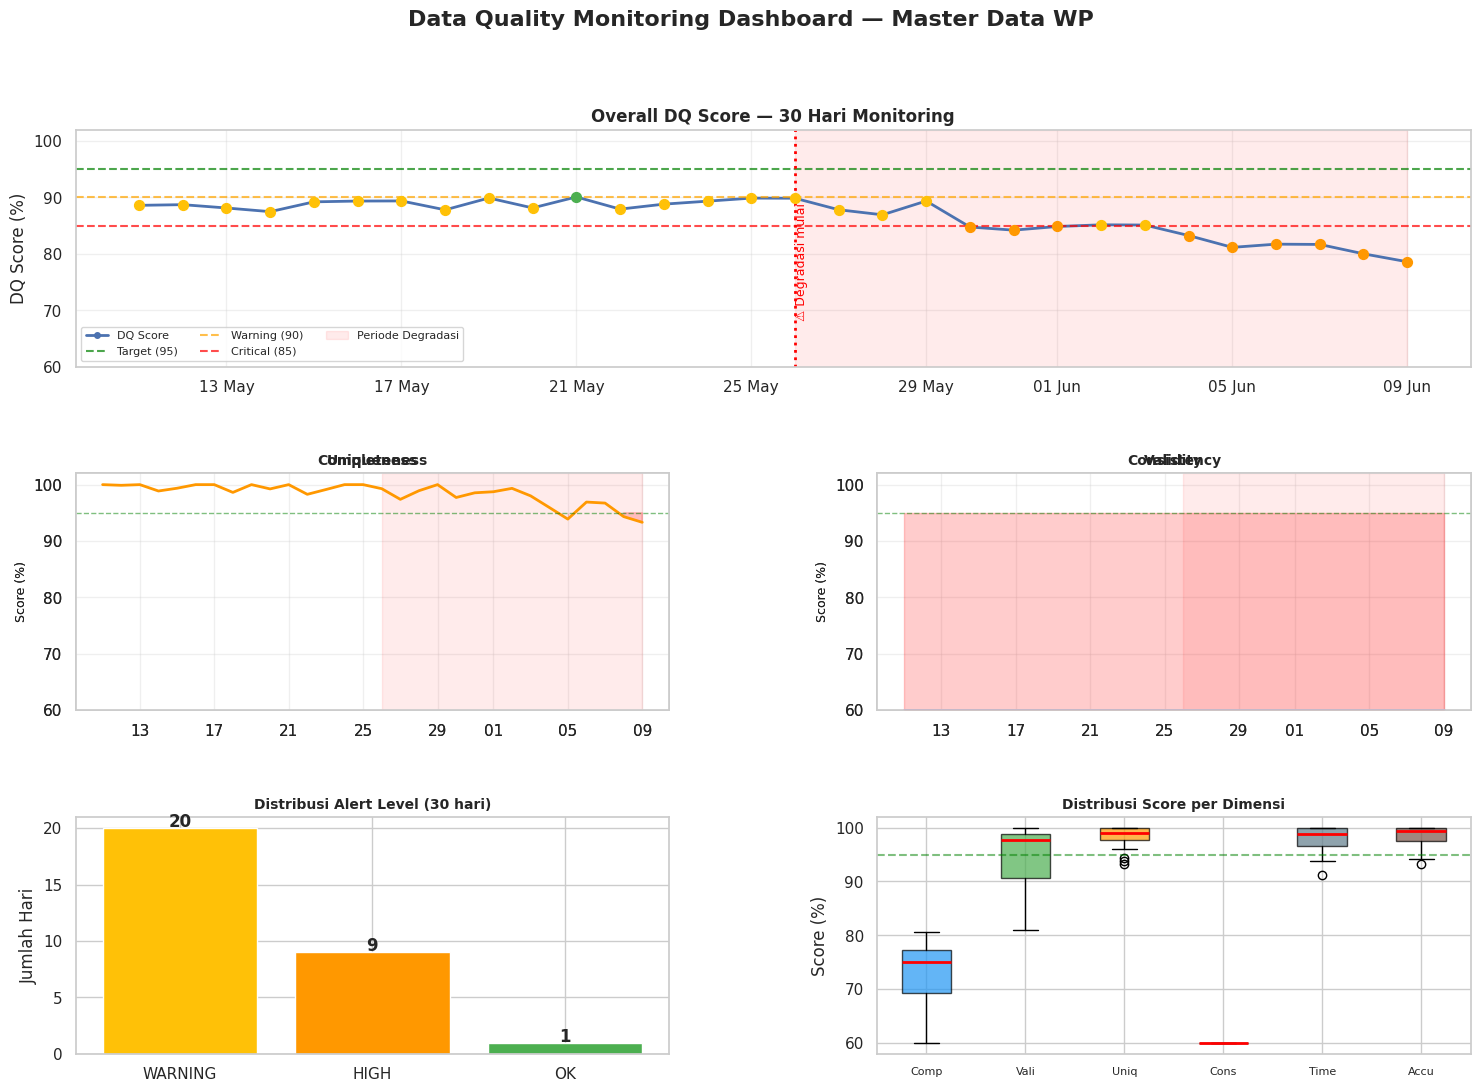

💾 Dashboard chart disimpan: chart_dq_monitoring_dashboard.png


In [92]:
# ============================================================
# CELL 9: VISUALISASI DQ SCORE TIME SERIES
# ============================================================

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Data Quality Monitoring Dashboard — Master Data WP',
             fontsize=16, fontweight='bold', y=0.98)

dates  = pd.to_datetime(df_history['date'])
deg_dt = pd.to_datetime(df_history[df_history['is_degradasi']]['date'].iloc[0])

# ── Chart 1: Overall DQ Score Trend ──
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates, df_history['overall'], 'b-o', linewidth=2, markersize=4, label='DQ Score')
ax1.axhline(y=95, color='green',  linestyle='--', alpha=0.7, linewidth=1.5, label='Target (95)')
ax1.axhline(y=90, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='Warning (90)')
ax1.axhline(y=85, color='red',    linestyle='--', alpha=0.7, linewidth=1.5, label='Critical (85)')
ax1.axvspan(deg_dt, dates.iloc[-1], alpha=0.08, color='red', label='Periode Degradasi')
ax1.axvline(x=deg_dt, color='red', linestyle=':', linewidth=2)
ax1.text(deg_dt, df_history['overall'].max()-1, '⚠ Degradasi mulai',
         color='red', fontsize=9, rotation=90, va='top')

# Warnai titik berdasarkan alert level
color_map = {'OK':'#4CAF50','WARNING':'#FFC107','HIGH':'#FF9800','CRITICAL':'#F44336'}
for _, row in df_history.iterrows():
    ax1.scatter(pd.to_datetime(row['date']), row['overall'],
                color=color_map[row['alert_level']], s=50, zorder=5)

ax1.set_ylim(60, 102)
ax1.set_ylabel('DQ Score (%)')
ax1.set_title('Overall DQ Score — 30 Hari Monitoring', fontweight='bold')
ax1.legend(loc='lower left', fontsize=8, ncol=3)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
ax1.grid(True, alpha=0.3)

# ── Chart 2-4: Score per Dimensi ──
dim_cols = {'Completeness':'dim_comp','Validity':'dim_vali',
            'Uniqueness':'dim_uniq','Consistency':'dim_cons'}
dim_colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

for i, (dim_name, col) in enumerate(dim_cols.items()):
    ax = fig.add_subplot(gs[1, i % 2] if i < 4 else gs[2, i % 2])
    if col in df_history.columns:
        ax.plot(dates, df_history[col], color=dim_colors[i], linewidth=2)
        ax.axvspan(deg_dt, dates.iloc[-1], alpha=0.08, color='red')
        ax.axhline(y=95, color='green', linestyle='--', alpha=0.5, linewidth=1)
        ax.fill_between(dates, df_history[col], 95,
                         where=df_history[col] < 95, alpha=0.2, color='red')
        ax.set_title(dim_name, fontweight='bold', fontsize=10)
        ax.set_ylim(60, 102)
        ax.set_ylabel('Score (%)', fontsize=9)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
        ax.grid(True, alpha=0.3)

# ── Chart 5: Alert Level Distribution ──
ax5 = fig.add_subplot(gs[2, 0])
alert_counts = df_history['alert_level'].value_counts()
colors_al = [color_map.get(l,'gray') for l in alert_counts.index]
ax5.bar(alert_counts.index, alert_counts.values, color=colors_al, edgecolor='white')
ax5.set_title('Distribusi Alert Level (30 hari)', fontweight='bold', fontsize=10)
ax5.set_ylabel('Jumlah Hari')
for i, (v) in enumerate(alert_counts.values):
    ax5.text(i, v+0.1, str(v), ha='center', fontweight='bold')

# ── Chart 6: Score Boxplot per Dimensi ──
ax6 = fig.add_subplot(gs[2, 1])
dim_data_box = [df_history[c].values for c in df_history.columns if c.startswith('dim_')]
dim_labels   = [c.replace('dim_','').capitalize() for c in df_history.columns if c.startswith('dim_')]
bp = ax6.boxplot(dim_data_box, labels=dim_labels, patch_artist=True,
                  medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], dim_colors + ['#607D8B','#795548']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax6.set_title('Distribusi Score per Dimensi', fontweight='bold', fontsize=10)
ax6.set_ylabel('Score (%)')
ax6.axhline(y=95, color='green', linestyle='--', alpha=0.5)
ax6.tick_params(axis='x', labelsize=8)

plt.savefig('chart_dq_monitoring_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Dashboard chart disimpan: chart_dq_monitoring_dashboard.png')



In [93]:
# ============================================================
# CELL 10: GENERATE LAPORAN HTML OTOMATIS
# Laporan yang bisa dibuka di browser atau dikirim via email
# ============================================================

def generate_html_report(results, df_history, overall_score, output_file='dq_report.html'):
    """Generate laporan HTML dari hasil monitoring DQ."""

    n_pass = sum(1 for r in results if r.status == 'PASS')
    n_fail = sum(1 for r in results if r.status != 'PASS')
    grade  = 'A' if overall_score >= 95 else 'B' if overall_score >= 85 else 'C' if overall_score >= 75 else 'D'
    grade_color = '#4CAF50' if grade == 'A' else '#FF9800' if grade == 'B' else '#F44336'

    # Build rows untuk tabel rules
    rows = ''
    for r in sorted(results, key=lambda x: x.score):
        status_color = '#4CAF50' if r.status == 'PASS' else '#F44336'
        sev_colors   = {'CRITICAL':'#F44336','HIGH':'#FF9800','MEDIUM':'#FFC107','LOW':'#4CAF50'}
        sev_c = sev_colors.get(r.severity, '#9E9E9E')
        rows += f'''
        <tr>
          <td><b>{r.rule_id}</b></td>
          <td>{r.rule_name}</td>
          <td>{r.dimension}</td>
          <td style='color:{sev_c};font-weight:bold'>{r.severity}</td>
          <td><b>{r.score:.1f}%</b></td>
          <td>{r.n_fail:,}</td>
          <td style='color:{status_color};font-weight:bold'>{r.status}</td>
        </tr>'''

    html = f'''<!DOCTYPE html>
    <html><head><meta charset='UTF-8'>
    <title>DQ Report — MDM Hub DJP</title>
    <style>
      body {{font-family:Arial,sans-serif;margin:30px;color:#333;background:#f5f5f5}}
      .header {{background:#1F4E79;color:white;padding:20px;border-radius:8px;margin-bottom:20px}}
      .score-box {{display:inline-block;background:white;border-radius:8px;padding:15px 25px;
                   margin:10px;box-shadow:0 2px 4px rgba(0,0,0,0.1);text-align:center}}
      .grade {{font-size:48px;font-weight:bold;color:{grade_color}}}
      table {{width:100%;border-collapse:collapse;background:white;border-radius:8px;
              box-shadow:0 2px 4px rgba(0,0,0,0.1)}}
      th {{background:#1F4E79;color:white;padding:10px;text-align:left}}
      td {{padding:9px 10px;border-bottom:1px solid #eee}}
      tr:hover {{background:#f5f5f5}}
    </style></head><body>
    <div class='header'>
      <h2>Data Quality Monitoring Report</h2>
      <p>MDM Hub — Master Data Wajib Pajak | Kementerian Keuangan / DJP</p>
      <p>Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    </div>
    <div>
      <div class='score-box'><div class='grade'>{grade}</div><div>Grade</div></div>
      <div class='score-box'><b style='font-size:32px;color:#1F4E79'>{overall_score:.1f}</b><div>Overall DQ Score</div></div>
      <div class='score-box'><b style='font-size:32px;color:#4CAF50'>{n_pass}</b><div>Rules PASS</div></div>
      <div class='score-box'><b style='font-size:32px;color:#F44336'>{n_fail}</b><div>Rules FAIL</div></div>
    </div>
    <br><h3>Detail Hasil Quality Rules</h3>
    <table>
      <tr><th>Rule ID</th><th>Rule Name</th><th>Dimensi</th>
          <th>Severity</th><th>Score</th><th>Fail</th><th>Status</th></tr>
{rows}
    </table>
    </body></html>'''

    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html)
    return output_file


report_file = generate_html_report(engine.history[-1]['results'], df_history, overall)
print(f'✅ HTML Report berhasil dibuat: {report_file}')
print(f'   Buka file ini di browser untuk melihat laporan interaktif.')


✅ HTML Report berhasil dibuat: dq_report.html
   Buka file ini di browser untuk melihat laporan interaktif.


In [94]:
# ============================================================
# CELL 11: EXPORT DATA UNTUK POWER BI DASHBOARD
# Power BI membutuhkan data dalam format tabular yang bersih
# ============================================================

print('📊 Menyiapkan data export untuk Power BI...')

# Hitung n_pass dan n_fail dari df_results
n_pass = (df_results['status'] == 'PASS').sum()
n_fail = (df_results['status'] != 'PASS').sum()

# ── Tabel 1: DQ Rules Result (fact table) ──
df_rules_pbi = df_results[['rule_id','rule_name','dimension','severity',
    'score','n_total','n_pass','n_fail','status','executed_at']].copy()
df_rules_pbi['report_date'] = BASELINE_DATE
df_rules_pbi.to_csv('pbi_rules_result.csv', index=False)
print(f'✅ pbi_rules_result.csv        — {len(df_rules_pbi)} rules')

# ── Tabel 2: DQ History (time series) ──
df_history.to_csv('pbi_dq_history.csv', index=False)
print(f'✅ pbi_dq_history.csv          — {len(df_history)} hari monitoring')

# ── Tabel 3: Golden Record Summary (untuk KPI cards) ──
summary_pbi = {
    'report_date'     : BASELINE_DATE,
    'total_golden_rec': len(df),
    'total_aktif'     : int((df['status_wp']=='Aktif').sum()),
    'total_non_aktif' : int((df['status_wp']=='Non-Aktif').sum()),
    'total_hapus'     : int((df['status_wp']=='Hapus').sum()),
    'total_badan'     : int((df['jenis_wp']=='Badan').sum()) if 'jenis_wp' in df.columns else 0,
    'total_op'        : int((df['jenis_wp']=='Orang Pribadi').sum()) if 'jenis_wp' in df.columns else 0,
    'pct_with_email'  : round(df['email'].notna().mean()*100,1) if 'email' in df.columns else 0,
    'pct_with_phone'  : round(df['telepon'].notna().mean()*100,1) if 'telepon' in df.columns else 0,
    'overall_dq_score': round(overall, 2),
    'dq_grade'        : grade,
    'n_rules_pass'    : n_pass,
    'n_rules_fail'    : n_fail,
}
pd.DataFrame([summary_pbi]).to_csv('pbi_summary_kpi.csv', index=False)
print(f'✅ pbi_summary_kpi.csv         — KPI cards untuk dashboard')

# ── Tabel 4: Alert Log untuk Power BI ──
if alerting.notification_log:
    pd.DataFrame(alerting.notification_log).to_csv('pbi_alert_log.csv', index=False)
    print(f'✅ pbi_alert_log.csv           — {len(alerting.notification_log)} alert entries')

# ── Tabel 5: Enriched Golden Record (trimmed untuk PBI) ──
cols_pbi = ['gr_id','gr_npwp','nama_wp','jenis_wp','status_wp',
            'kode_kpp','kode_provinsi','nama_provinsi','source_count','n_conflicts']
if 'klu_kode' in df.columns: cols_pbi += ['klu_kode','sektor','tingkat_risiko']
df_gr_pbi = df[[c for c in cols_pbi if c in df.columns]].copy()
df_gr_pbi.to_csv('pbi_golden_record.csv', index=False)
print(f'✅ pbi_golden_record.csv        — {len(df_gr_pbi):,} golden records')

print(f'\n📋 PANDUAN IMPORT KE POWER BI DESKTOP:')
print(f'   1. Buka Power BI Desktop')
print(f'   2. Klik Home → Get Data → Text/CSV')
print(f'   3. Import 5 file CSV di atas sebagai 5 tabel terpisah:')
print(f'      - pbi_rules_result    → Tabel Fact DQ Rules')
print(f'      - pbi_dq_history      → Tabel Time Series')
print(f'      - pbi_summary_kpi     → Tabel KPI Cards')
print(f'      - pbi_alert_log       → Tabel Alert History')
print(f'      - pbi_golden_record   → Tabel Master Data WP')
print(f'   4. Buat relasi antar tabel di Model View')
print(f'   5. Bangun visualisasi sesuai panduan halaman berikutnya')

  return datetime.utcnow().replace(tzinfo=utc)



📊 Menyiapkan data export untuk Power BI...
✅ pbi_rules_result.csv        — 15 rules


  return datetime.utcnow().replace(tzinfo=utc)



✅ pbi_dq_history.csv          — 30 hari monitoring
✅ pbi_summary_kpi.csv         — KPI cards untuk dashboard
✅ pbi_alert_log.csv           — 2 alert entries
✅ pbi_golden_record.csv        — 500 golden records

📋 PANDUAN IMPORT KE POWER BI DESKTOP:
   1. Buka Power BI Desktop
   2. Klik Home → Get Data → Text/CSV
   3. Import 5 file CSV di atas sebagai 5 tabel terpisah:
      - pbi_rules_result    → Tabel Fact DQ Rules
      - pbi_dq_history      → Tabel Time Series
      - pbi_summary_kpi     → Tabel KPI Cards
      - pbi_alert_log       → Tabel Alert History
      - pbi_golden_record   → Tabel Master Data WP
   4. Buat relasi antar tabel di Model View
   5. Bangun visualisasi sesuai panduan halaman berikutnya


In [95]:
# ============================================================
# CELL 12: FINAL EXPORT & RINGKASAN LAB 6
# ============================================================

# Export alert summary
alert_summary_df = alerting.summary()
if len(alert_summary_df) > 0:
    alert_summary_df.to_csv('alert_summary.csv', index=False)
    print(f'✅ alert_summary.csv          — {len(alert_summary_df)} alert records')

# Export GE expectation suite (sudah disimpan di Cell 6)
print(f'✅ ge_expectation_suite.json  — Great Expectations suite')
print(f'✅ dq_report.html             — HTML monitoring report')
print(f'✅ dq_baseline_results.csv    — Baseline quality rules results')
print(f'✅ dq_monitoring_history.csv  — 30 hari time series data')
print(f'✅ alert_notification_log.csv — Notification log')
print(f'✅ chart_dq_monitoring_dashboard.png — Dashboard chart')

print(f'\n' + '='*65)
print(f'  RINGKASAN LAB 6 — DATA QUALITY MONITORING')
print(f'='*65)
print(f'  Quality Rules Engine:')
print(f'    Total rules      : {len(engine.rules)}')
print(f'    Rules PASS       : {n_pass} ({n_pass/len(results)*100:.0f}%)')
print(f'    Rules FAIL       : {n_fail}')
print(f'    Overall DQ Score : {overall:.2f} / 100  (Grade: {grade})')
print(f'')
print(f'  Great Expectations:')
print(f'    Expectations     : 11')
print(f'    Expectation suite: ge_expectation_suite.json')
print(f'')
print(f'  Alerting System:')
print(f'    Total alerts     : {len(alerting.alerts)}')
print(f'    Notification log : {len(alerting.notification_log)} entries')
print(f'')
print(f'  Time Series Monitoring:')
print(f'    Periode          : 30 hari')
print(f'    Skenario degradasi: hari ke-{DEGRADASI_DAY}')
print(f'    Score min        : {df_history["overall"].min():.1f}')
print(f'    Score max        : {df_history["overall"].max():.1f}')
print(f'')
print(f'  Output untuk Power BI:')
print(f'    5 tabel CSV siap diimport')
print(f'='*65)
print(f'\n🏁 LAB 6 SELESAI!')
print(f'   Semua 6 Labs telah diselesaikan.')
print(f'   Selanjutnya: Mini Project — Simulasi Master Data Wajib Pajak Nasional')



✅ alert_summary.csv          — 2 alert records
✅ ge_expectation_suite.json  — Great Expectations suite
✅ dq_report.html             — HTML monitoring report
✅ dq_baseline_results.csv    — Baseline quality rules results
✅ dq_monitoring_history.csv  — 30 hari time series data
✅ alert_notification_log.csv — Notification log
✅ chart_dq_monitoring_dashboard.png — Dashboard chart

  RINGKASAN LAB 6 — DATA QUALITY MONITORING
  Quality Rules Engine:
    Total rules      : 15
    Rules PASS       : 12 (80%)
    Rules FAIL       : 3
    Overall DQ Score : 79.98 / 100  (Grade: C)

  Great Expectations:
    Expectations     : 11
    Expectation suite: ge_expectation_suite.json

  Alerting System:
    Total alerts     : 2
    Notification log : 2 entries

  Time Series Monitoring:
    Periode          : 30 hari
    Skenario degradasi: hari ke-15
    Score min        : 78.6
    Score max        : 90.1

  Output untuk Power BI:
    5 tabel CSV siap diimport

🏁 LAB 6 SELESAI!
   Semua 6 Labs telah dis